#**Data preprocess**

In [143]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    pairwise_distances
)
from sklearn.cluster import KMeans
import openpyxl

# --------------------------
# ENV / DETERMINISM SETTINGS
# --------------------------
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

warnings.filterwarnings("ignore")
MASTER_SEED = 42
random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
GLOBAL_RNG = np.random.default_rng(MASTER_SEED)

# --------------------------
# USER CONFIG - EDIT THIS
# --------------------------
#DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset1/circles.csv"
#DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset1/fashion-mnist_test.csv"  # <-- replace with your dataset path  # <-- replace with your dataset path
#DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset1/file_1.csv"  # <-- replace with your dataset path
#DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset1/cluster_data.csv"  # <-- replace with your dataset path
#DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset1/Dry_Bean_Dataset.csv"
#DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset1/heart_failure_clinical_records_dataset.csv"
#DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset1/AirfoilSelfNoise.csv"
#
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset1/Rice_data_type.csv"  # <-- replace with your dataset path

#-----------------------------------------------------------------------------------------------------------------------------------------


OUT_DIR = "kmeans_nre_results"
os.makedirs(OUT_DIR, exist_ok=True)


# --------------------------
# LOAD & PREPROCESS
# --------------------------
if DATASET_PATH.endswith('.csv'):
    df = pd.read_csv(DATASET_PATH)
elif DATASET_PATH.endswith(('.xlsx', '.xls')):
    df = pd.read_excel(DATASET_PATH)
else:
    raise ValueError("Unsupported file format. Use .csv or .xlsx/.xls")

# detect label column
label_col = None
for col in df.columns:
    if any(k in str(col).lower() for k in ("label", "class", "target")):
        label_col = col
        break

if label_col:
    y_true = df[label_col].values
    df_num = df.drop(columns=[label_col]).select_dtypes(include=[np.number]).copy()
else:
    y_true = None
    df_num = df.select_dtypes(include=[np.number]).copy()

# handle NaN/infs and standardize
df_num = df_num.replace([np.inf, -np.inf], np.nan).fillna(df_num.mean())
X = StandardScaler().fit_transform(df_num.values.astype(np.float64))
n, d = X.shape
print(f"Loaded dataset: {n} samples, {d} numeric features (cleaned)")


# --------------------------
# NREDT-KMeans CLASS all
# --------------------------
class NRE_KMeans:
    def __init__(
        self,
        n_clusters=3,
        max_iter=100,
        tol=1e-4,
        lambda_min=1.0,
        lambda_max=3.0,
        random_state=MASTER_SEED
    ):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol

        # Adaptive noise-threshold parameters
        self.lambda_min = lambda_min
        self.lambda_max = lambda_max

        self.random_state = random_state
        self.centroids = None
        self.labels = None

        # Store adaptive values for analysis
        self.lambda_history = []
        self.threshold_history = []
        self.r_history = []

    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        # deterministic random centroid initialization
        self.centroids = X[
            np.random.choice(
                n_samples,
                self.n_clusters,
                replace=False
            )
        ]

        self.labels = np.full(n_samples, -1)

        # Reset adaptive history
        self.lambda_history = []
        self.threshold_history = []
        self.r_history = []

        for it in range(self.max_iter):
            prev_centroids = self.centroids.copy()

            distances = np.linalg.norm(
                X[:, np.newaxis] - self.centroids,
                axis=2
            )

            nearest = np.argmin(distances, axis=1)
            nearest_dist = np.min(distances, axis=1)

            # --------------------------
            # ADAPTIVE NOISE DETECTION
            # --------------------------

            # Median distance
            median_dist = np.median(nearest_dist)

            # MAD
            mad = np.median(
                np.abs(nearest_dist - median_dist)
            ) + 1e-12

            # Relative dispersion
            r_t = mad / (median_dist + 1e-12)

            # Adaptive lambda
            lambda_t = (
                self.lambda_max
                - (self.lambda_max - self.lambda_min)
                * np.clip(r_t, 0, 1)
            )

            # Adaptive threshold
            threshold = median_dist + lambda_t * mad

            # Store adaptive values
            self.r_history.append(r_t)
            self.lambda_history.append(lambda_t)
            self.threshold_history.append(threshold)

            # Noise detection
            self.labels = np.where(
                nearest_dist > threshold,
                -1,
                nearest
            )

            # --------------------------
            # CENTROID UPDATE
            # --------------------------
            for k in range(self.n_clusters):
                cluster_points = X[self.labels == k]

                if len(cluster_points) > 0:
                    self.centroids[k] = cluster_points.mean(axis=0)

            # --------------------------
            # CONVERGENCE
            # --------------------------
            if np.all(
                np.linalg.norm(
                    self.centroids - prev_centroids,
                    axis=1
                ) < self.tol
            ):
                break

        return self

    def predict(self, X):
        distances = np.linalg.norm(
            X[:, np.newaxis] - self.centroids,
            axis=2
        )

        nearest = np.argmin(distances, axis=1)
        nearest_dist = np.min(distances, axis=1)

        # --------------------------
        # ADAPTIVE NOISE DETECTION
        # --------------------------

        median_dist = np.median(nearest_dist)

        mad = np.median(
            np.abs(nearest_dist - median_dist)
        ) + 1e-12

        # Relative dispersion
        r_t = mad / (median_dist + 1e-12)

        # Adaptive lambda
        lambda_t = (
            self.lambda_max
            - (self.lambda_max - self.lambda_min)
            * np.clip(r_t, 0, 1)
        )

        # Adaptive threshold
        threshold = median_dist + lambda_t * mad

        return np.where(
            nearest_dist > threshold,
            -1,
            nearest
        )

    def evaluate(self, X):
        mask = self.labels != -1

        if np.sum(mask) < 2:
            return None

        # ------------------
        # Standard metrics
        # ------------------
        sil = silhouette_score(
            X[mask],
            self.labels[mask]
        )

        db = davies_bouldin_score(
            X[mask],
            self.labels[mask]
        )

        ch = calinski_harabasz_score(
            X[mask],
            self.labels[mask]
        )

        # ------------------
        # Intra-cluster distance
        # ------------------
        intra_list = [
            np.mean(
                np.linalg.norm(
                    X[mask][self.labels[mask] == k]
                    - self.centroids[k],
                    axis=1
                )
            )
            for k in range(self.n_clusters)
            if np.any(self.labels[mask] == k)
        ]

        intra = np.mean(intra_list)

        # ------------------
        # Compactness
        # ------------------
        compactness = np.mean([
            np.mean(
                np.linalg.norm(
                    X[mask][self.labels[mask] == k]
                    - self.centroids[k],
                    axis=1
                )
            )
            for k in range(self.n_clusters)
            if np.any(self.labels[mask] == k)
        ])

        # ------------------
        # Inter-cluster distance
        # ------------------
        inter = np.mean(
            pairwise_distances(self.centroids)
        )

        # ------------------
        # Xie–Beni Index
        # ------------------
        min_centroid_dist = np.min(
            pairwise_distances(self.centroids)
            + np.eye(self.n_clusters) * 1e12
        )

        xie_beni = (
            np.sum([
                np.sum(
                    np.linalg.norm(
                        X[mask][self.labels[mask] == k]
                        - self.centroids[k],
                        axis=1
                    ) ** 2
                )
                for k in range(self.n_clusters)
                if np.any(self.labels[mask] == k)
            ])
            /
            (
                X[mask].shape[0]
                * min_centroid_dist
                + 1e-12
            )
        )

        # ------------------
        # Separation ratio
        # ------------------
        separation_ratio = (
            inter / (intra + 1e-12)
        )

        return {
            "Silhouette": sil,
            "Davies-Bouldin": db,
            "Calinski-Harabasz": ch,
            "Intra": intra,
            "Compactness": compactness,
            "Xie-Beni": xie_beni,
            "Separation-Ratio": separation_ratio,
            "Inter": inter
        }

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

def find_best_k_silhouette(X, k_min=2, k_max=10, seed=42):
    best_k = k_min
    best_score = -1

    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, n_init=5, random_state=seed)
        labels = km.fit_predict(X)

        if len(np.unique(labels)) > 1:
            score = silhouette_score(X, labels)
            if score > best_score:
                best_score = score
                best_k = k

    return best_k


# --------------------------
# RUN BASELINE KMEANS
# --------------------------
k_clusters = find_best_k_silhouette(X, 2, 10)
print("Optimal number of clusters:", k_clusters)
print("\nRunning deterministic KMeans...")
kmeans_model = KMeans(n_clusters=k_clusters, n_init=1, max_iter=300, random_state=MASTER_SEED)
kmeans_model.fit(X)
k_labels = kmeans_model.labels_
k_centroids = kmeans_model.cluster_centers_

# compute KMeans metrics (no noise removal)
mask = np.ones(len(X), dtype=bool)

# ------------------
# Intra-cluster distance
# ------------------
intra_list = [
    np.mean(np.linalg.norm(X[k_labels == k] - k_centroids[k], axis=1))
    for k in range(k_clusters)
    if np.any(k_labels == k)
]
intra = np.mean(intra_list)

# ------------------
# Compactness (same as intra but explicitly named)
# ------------------
compactness = intra

# ------------------
# Inter-cluster distance
# ------------------
inter = np.mean(pairwise_distances(k_centroids))

# ------------------
# Xie–Beni Index
# ------------------
min_centroid_dist = np.min(
    pairwise_distances(k_centroids) + np.eye(k_clusters) * 1e12
)

xie_beni = (
    np.sum([
        np.sum(np.linalg.norm(X[k_labels == k] - k_centroids[k], axis=1) ** 2)
        for k in range(k_clusters)
        if np.any(k_labels == k)
    ]) / (X.shape[0] * min_centroid_dist + 1e-12)
)

# ------------------
# Final metric dictionary (ORDER MATCHED)
# ------------------
baseline_scores = {
    "Silhouette": silhouette_score(X[mask], k_labels[mask]),
    "Davies-Bouldin": davies_bouldin_score(X[mask], k_labels[mask]),
    "Calinski-Harabasz": calinski_harabasz_score(X[mask], k_labels[mask]),
    "Intra": intra,
    "Compactness": compactness,
    "Xie-Beni": xie_beni,
    "Separation-Ratio": inter / (intra + 1e-12),
    "Inter": inter
}



Loaded dataset: 3810 samples, 8 numeric features (cleaned)
Optimal number of clusters: 2

Running deterministic KMeans...


In [145]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances


# ============================================================
# 1️⃣ BASELINE KMEANS++ (Proper Version)
# ============================================================

def run_kmeans_plus_plus(X, n_clusters=3, max_iter=300, seed=None):
    model = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init=10,                 # proper multiple restarts
        max_iter=max_iter,
        random_state=seed
    )
    model.fit(X)

    return {
        "labels": model.labels_,
        "centroids": model.cluster_centers_,
        "model": model
    }


# ============================================================
# 2️⃣ TRIMMED KMEANS (Corrected Strong Version)
# ============================================================

class TrimmedKMeans:
    def __init__(self, n_clusters=3, trim_ratio=0.1,
                 max_iter=100, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.trim_ratio = trim_ratio
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.labels_ = None
        self.cluster_centers_ = None

    def fit(self, X):
        # Use KMeans++ initialization (important fix)
        base = KMeans(
            n_clusters=self.n_clusters,
            init="k-means++",
            n_init=5,
            random_state=self.random_state
        ).fit(X)

        centroids = base.cluster_centers_
        n_samples = X.shape[0]

        for _ in range(self.max_iter):
            prev_centroids = centroids.copy()

            distances = pairwise_distances(X, centroids)
            labels = np.argmin(distances, axis=1)
            assigned_dist = distances[np.arange(n_samples), labels]

            # Strong trimming
            cutoff = np.percentile(
                assigned_dist,
                100 * (1 - self.trim_ratio)
            )
            keep_mask = assigned_dist <= cutoff

            for k in range(self.n_clusters):
                cluster_points = X[(labels == k) & keep_mask]
                if len(cluster_points) > 0:
                    centroids[k] = cluster_points.mean(axis=0)

            if np.all(np.linalg.norm(
                centroids - prev_centroids,
                axis=1
            ) < self.tol):
                break

        self.labels_ = labels
        self.cluster_centers_ = centroids
        return self


# ============================================================
# 3️⃣ ROBUST KMEANS (Actually Robust Now)
# ============================================================

class RobustKMeans:
    def __init__(self, n_clusters=3, noise_threshold=2.0,
                 max_iter=300, random_state=None):
        self.n_clusters = n_clusters
        self.noise_threshold = noise_threshold
        self.max_iter = max_iter
        self.random_state = random_state
        self.labels_ = None
        self.cluster_centers_ = None

    def fit(self, X):

        # Initial clustering
        base_model = KMeans(
            n_clusters=self.n_clusters,
            init="k-means++",
            n_init=10,
            max_iter=self.max_iter,
            random_state=self.random_state
        ).fit(X)

        labels = base_model.labels_
        centroids = base_model.cluster_centers_

        distances = np.linalg.norm(
            X - centroids[labels],
            axis=1
        )

        # STRONGER threshold (reduced multiplier)
        threshold = np.mean(distances) + self.noise_threshold * np.std(distances)

        # Remove outliers
        inliers = X[distances <= threshold]

        # Refit ONLY on inliers
        refined_model = KMeans(
            n_clusters=self.n_clusters,
            init="k-means++",
            n_init=10,
            max_iter=self.max_iter,
            random_state=self.random_state
        ).fit(inliers)

        self.labels_ = refined_model.predict(X)
        self.cluster_centers_ = refined_model.cluster_centers_

        return self

In [131]:
# --------------------------
# RUN NREDT-KMEANS
# --------------------------
print("\nRunning deterministic NREDT-KMeans...")

nre_model = NRE_KMeans(
    n_clusters=k_clusters,
    max_iter=200,
    lambda_min=1.0,
    lambda_max=3.0,
    random_state=MASTER_SEED
)

nre_model.fit(X)

nre_labels = nre_model.labels
nre_centroids = nre_model.centroids
nre_scores = nre_model.evaluate(X)

print("NREDT-KMeans completed.")
print(f"Clusters: {k_clusters}")
print(f"Iterations: {len(nre_model.lambda_history)}")

if len(nre_model.lambda_history) > 0:
    print(f"Final adaptive lambda: {nre_model.lambda_history[-1]:.6f}")
    print(f"Final threshold: {nre_model.threshold_history[-1]:.6f}")

print(f"Noise points: {np.sum(nre_labels == -1)}")
print(f"Non-noise points: {np.sum(nre_labels != -1)}")


Running deterministic NREDT-KMeans...
NREDT-KMeans completed.
Clusters: 2
Iterations: 6
Final adaptive lambda: 2.625596
Final threshold: 2.748054
Noise points: 166
Non-noise points: 1337


In [146]:
# ============================================================
# 30-RUN EXPERIMENT - SUPERFAST
# ============================================================

print("\n" + "=" * 60)
print("RUNNING 30 REPEATED RUNS")
print("=" * 60)

N_RUNS = 30

kmeans_results_30 = []
nre_results_30 = []

for run in range(N_RUNS):

    seed = MASTER_SEED + run

    # --------------------------------------------------------
    # KMEANS
    # --------------------------------------------------------
    km = KMeans(
        n_clusters=k_clusters,
        n_init=1,
        max_iter=100,
        random_state=seed
    )

    km.fit(X)

    labels = km.labels_
    centroids = km.cluster_centers_

    # KMeans metrics
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    intra_list = [
        np.mean(
            np.linalg.norm(
                X[labels == k] - centroids[k],
                axis=1
            )
        )
        for k in range(k_clusters)
        if np.any(labels == k)
    ]

    intra = np.mean(intra_list)
    compactness = intra

    inter = np.mean(pairwise_distances(centroids))

    min_centroid_dist = np.min(
        pairwise_distances(centroids)
        + np.eye(k_clusters) * 1e12
    )

    xie_beni = (
        np.sum([
            np.sum(
                np.linalg.norm(
                    X[labels == k] - centroids[k],
                    axis=1
                ) ** 2
            )
            for k in range(k_clusters)
            if np.any(labels == k)
        ])
        /
        (
            X.shape[0] * min_centroid_dist
            + 1e-12
        )
    )

    separation_ratio = inter / (intra + 1e-12)

    kmeans_results_30.append({
        "Run": run + 1,
        "Silhouette": sil,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch,
        "Intra": intra,
        "Compactness": compactness,
        "Xie-Beni": xie_beni,
        "Separation-Ratio": separation_ratio,
        "Inter": inter
    })

    # --------------------------------------------------------
    # NREDT-KMEANS
    # --------------------------------------------------------
    nre = NRE_KMeans(
        n_clusters=k_clusters,
        max_iter=100,
        lambda_min=1.0,
        lambda_max=3.0,
        random_state=seed
    )

    nre.fit(X)
    scores = nre.evaluate(X)

    if scores is not None:
        nre_results_30.append({
            "Run": run + 1,
            "Silhouette": scores["Silhouette"],
            "Davies-Bouldin": scores["Davies-Bouldin"],
            "Calinski-Harabasz": scores["Calinski-Harabasz"],
            "Intra": scores["Intra"],
            "Compactness": scores["Compactness"],
            "Xie-Beni": scores["Xie-Beni"],
            "Separation-Ratio": scores["Separation-Ratio"],
            "Inter": scores["Inter"],
            "Noise": np.sum(nre.labels == -1),
            "Lambda": nre.lambda_history[-1]
        })

    print(f"Run {run + 1:02d}/{N_RUNS} completed")


# ============================================================
# RESULTS
# ============================================================

kmeans_30_df = pd.DataFrame(kmeans_results_30)
nre_30_df = pd.DataFrame(nre_results_30)

# print("\n" + "=" * 60)
# print("30-RUN KMEANS RESULTS")
# print("=" * 60)

# print(
#     kmeans_30_df.drop(columns=["Run"])
#     .agg(["mean", "std"])
#     .T
#     .round(6)
# )


# print("\n" + "=" * 60)
# print("30-RUN NREDT-KMEANS RESULTS")
# print("=" * 60)

# print(
#     nre_30_df.drop(columns=["Run"])
#     .agg(["mean", "std"])
#     .T
#     .round(6)
# )


# # ============================================================
# # SAVE 30-RUN RESULTS
# # ============================================================

# kmeans_30_df.to_csv(
#     os.path.join(OUT_DIR, "KMeans_30_runs.csv"),
#     index=False
# )

# nre_30_df.to_csv(
#     os.path.join(OUT_DIR, "NREDT_KMeans_30_runs.csv"),
#     index=False
# )

# # Excel output
# excel_path = os.path.join(
#     OUT_DIR,
#     "KMeans_NREDT_KMeans_30_runs.xlsx"
# )

# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

#     kmeans_30_df.to_excel(
#         writer,
#         sheet_name="KMeans_30_Runs",
#         index=False
#     )

#     nre_30_df.to_excel(
#         writer,
#         sheet_name="NREDT_30_Runs",
#         index=False
#     )

# print("\n30-run results saved successfully.")
# print(f"Output folder: {OUT_DIR}")


RUNNING 30 REPEATED RUNS
Run 01/30 completed
Run 02/30 completed
Run 03/30 completed
Run 04/30 completed
Run 05/30 completed
Run 06/30 completed
Run 07/30 completed
Run 08/30 completed
Run 09/30 completed
Run 10/30 completed
Run 11/30 completed
Run 12/30 completed
Run 13/30 completed
Run 14/30 completed
Run 15/30 completed
Run 16/30 completed
Run 17/30 completed
Run 18/30 completed
Run 19/30 completed
Run 20/30 completed
Run 21/30 completed
Run 22/30 completed
Run 23/30 completed
Run 24/30 completed
Run 25/30 completed
Run 26/30 completed
Run 27/30 completed
Run 28/30 completed
Run 29/30 completed
Run 30/30 completed


In [147]:
# ==========================================================
# MISSING KMEANS++ FUNCTION
# ==========================================================

def run_kmeans_plus_plus(
    X,
    n_clusters,
    seed
):

    X = np.asarray(
        X,
        dtype=float
    )

    rng = np.random.default_rng(
        seed
    )

    n_samples = X.shape[0]

    # ------------------------------------------------------
    # 1. Select first centroid randomly
    # ------------------------------------------------------

    first_index = rng.integers(
        0,
        n_samples
    )

    centroids = [
        X[first_index].copy()
    ]

    # ------------------------------------------------------
    # 2. Select remaining centroids using
    #    KMeans++ probability
    # ------------------------------------------------------

    for _ in range(
        1,
        n_clusters
    ):

        distances = np.min(
            np.linalg.norm(
                X[:, np.newaxis]
                -
                np.asarray(centroids)[
                    np.newaxis, :
                ],
                axis=2
            ) ** 2,
            axis=1
        )

        total_distance = np.sum(
            distances
        )

        if (
            total_distance <= 1e-12
            or not np.isfinite(
                total_distance
            )
        ):

            next_index = rng.integers(
                0,
                n_samples
            )

        else:

            probabilities = (
                distances
                /
                total_distance
            )

            next_index = rng.choice(
                n_samples,
                p=probabilities
            )

        centroids.append(
            X[next_index].copy()
        )

    centroids = np.asarray(
        centroids,
        dtype=float
    )

    # ------------------------------------------------------
    # 3. Lloyd KMeans iterations
    # ------------------------------------------------------

    labels = np.full(
        n_samples,
        -1,
        dtype=int
    )

    max_iter = 300

    tol = 1e-4

    for _ in range(
        max_iter
    ):

        previous_centroids = (
            centroids.copy()
        )

        distances = np.linalg.norm(
            X[:, np.newaxis]
            -
            centroids[np.newaxis, :],
            axis=2
        )

        labels = np.argmin(
            distances,
            axis=1
        )

        for k in range(
            n_clusters
        ):

            cluster_points = X[
                labels == k
            ]

            if len(
                cluster_points
            ) > 0:

                centroids[k] = (
                    cluster_points.mean(
                        axis=0
                    )
                )

        centroid_shift = np.linalg.norm(
            centroids
            -
            previous_centroids,
            axis=1
        )

        if np.all(
            centroid_shift < tol
        ):

            break

    return {
        "labels": labels,
        "centroids": centroids
    }

In [148]:
# ==========================================================
# TRIMMED K-MEANS
# ==========================================================

class TrimmedKMeans:

    def __init__(
        self,
        n_clusters=3,
        trim_ratio=0.05,
        max_iter=300,
        tol=1e-4,
        random_state=42
    ):

        self.n_clusters = n_clusters
        self.trim_ratio = trim_ratio
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.cluster_centers_ = None
        self.labels_ = None
        self.noise_ = None

    def fit(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        n_samples = X.shape[0]

        rng = np.random.default_rng(
            self.random_state
        )

        # --------------------------------------------------
        # Initial centroids
        # --------------------------------------------------

        initial_indices = rng.choice(
            n_samples,
            size=self.n_clusters,
            replace=False
        )

        self.cluster_centers_ = X[
            initial_indices
        ].copy()

        # --------------------------------------------------
        # Number of points to trim
        # --------------------------------------------------

        n_trim = int(
            self.trim_ratio * n_samples
        )

        for _ in range(
            self.max_iter
        ):

            previous_centers = (
                self.cluster_centers_.copy()
            )

            # --------------------------------------------------
            # Calculate distances
            # --------------------------------------------------

            distances = np.linalg.norm(
                X[:, np.newaxis]
                -
                self.cluster_centers_[
                    np.newaxis, :
                ],
                axis=2
            )

            labels = np.argmin(
                distances,
                axis=1
            )

            nearest_distances = np.min(
                distances,
                axis=1
            )

            # --------------------------------------------------
            # Trim farthest observations
            # --------------------------------------------------

            if n_trim > 0:

                trim_indices = np.argsort(
                    nearest_distances
                )[-n_trim:]

                valid_mask = np.ones(
                    n_samples,
                    dtype=bool
                )

                valid_mask[
                    trim_indices
                ] = False

            else:

                valid_mask = np.ones(
                    n_samples,
                    dtype=bool
                )

            # --------------------------------------------------
            # Update centroids using non-trimmed points
            # --------------------------------------------------

            for k in range(
                self.n_clusters
            ):

                cluster_mask = (
                    (labels == k)
                    &
                    valid_mask
                )

                cluster_points = X[
                    cluster_mask
                ]

                if len(
                    cluster_points
                ) > 0:

                    self.cluster_centers_[k] = (
                        cluster_points.mean(
                            axis=0
                        )
                    )

            # --------------------------------------------------
            # Convergence
            # --------------------------------------------------

            centroid_shift = np.linalg.norm(
                self.cluster_centers_
                -
                previous_centers,
                axis=1
            )

            if np.all(
                centroid_shift < self.tol
            ):

                break

        # ------------------------------------------------------
        # Final labels
        # ------------------------------------------------------

        final_distances = np.linalg.norm(
            X[:, np.newaxis]
            -
            self.cluster_centers_[
                np.newaxis, :
            ],
            axis=2
        )

        final_labels = np.argmin(
            final_distances,
            axis=1
        )

        final_nearest_distances = np.min(
            final_distances,
            axis=1
        )

        # ------------------------------------------------------
        # Final trimming
        # ------------------------------------------------------

        self.noise_ = np.zeros(
            n_samples,
            dtype=bool
        )

        if n_trim > 0:

            final_trim_indices = np.argsort(
                final_nearest_distances
            )[-n_trim:]

            self.noise_[
                final_trim_indices
            ] = True

            final_labels[
                final_trim_indices
            ] = -1

        self.labels_ = final_labels

        return self

    def predict(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        distances = np.linalg.norm(
            X[:, np.newaxis]
            -
            self.cluster_centers_[
                np.newaxis, :
            ],
            axis=2
        )

        labels = np.argmin(
            distances,
            axis=1
        )

        return labels

    def fit_predict(self, X):

        self.fit(X)

        return self.labels_

In [149]:
# ==========================================================
# ROBUST K-MEANS
# ==========================================================

class RobustKMeans:

    def __init__(
        self,
        n_clusters=3,
        noise_threshold=2.5,
        max_iter=300,
        tol=1e-4,
        random_state=42
    ):

        self.n_clusters = n_clusters
        self.noise_threshold = noise_threshold
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.cluster_centers_ = None
        self.labels_ = None
        self.noise_ = None

    def fit(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        n_samples = X.shape[0]

        rng = np.random.default_rng(
            self.random_state
        )

        # --------------------------------------------------
        # Initial centroids
        # --------------------------------------------------

        initial_indices = rng.choice(
            n_samples,
            size=self.n_clusters,
            replace=False
        )

        self.cluster_centers_ = X[
            initial_indices
        ].copy()

        # --------------------------------------------------
        # Robust K-Means iterations
        # --------------------------------------------------

        for _ in range(
            self.max_iter
        ):

            previous_centers = (
                self.cluster_centers_.copy()
            )

            # --------------------------------------------------
            # Calculate distances
            # --------------------------------------------------

            distances = np.linalg.norm(
                X[:, np.newaxis]
                -
                self.cluster_centers_[
                    np.newaxis, :
                ],
                axis=2
            )

            labels = np.argmin(
                distances,
                axis=1
            )

            nearest_distances = np.min(
                distances,
                axis=1
            )

            # --------------------------------------------------
            # Robust distance threshold
            # --------------------------------------------------

            median_distance = np.median(
                nearest_distances
            )

            mad = np.median(
                np.abs(
                    nearest_distances
                    -
                    median_distance
                )
            ) + 1e-12

            robust_z = (
                np.abs(
                    nearest_distances
                    -
                    median_distance
                )
                /
                (1.4826 * mad)
            )

            valid_mask = (
                robust_z
                <=
                self.noise_threshold
            )

            # --------------------------------------------------
            # Update centroids using valid points
            # --------------------------------------------------

            for k in range(
                self.n_clusters
            ):

                cluster_mask = (
                    (labels == k)
                    &
                    valid_mask
                )

                cluster_points = X[
                    cluster_mask
                ]

                if len(
                    cluster_points
                ) > 0:

                    self.cluster_centers_[k] = (
                        cluster_points.mean(
                            axis=0
                        )
                    )

            # --------------------------------------------------
            # Convergence
            # --------------------------------------------------

            centroid_shift = np.linalg.norm(
                self.cluster_centers_
                -
                previous_centers,
                axis=1
            )

            if np.all(
                centroid_shift < self.tol
            ):

                break

        # ------------------------------------------------------
        # Final assignment
        # ------------------------------------------------------

        final_distances = np.linalg.norm(
            X[:, np.newaxis]
            -
            self.cluster_centers_[
                np.newaxis, :
            ],
            axis=2
        )

        final_labels = np.argmin(
            final_distances,
            axis=1
        )

        final_nearest_distances = np.min(
            final_distances,
            axis=1
        )

        # ------------------------------------------------------
        # Final robust noise detection
        # ------------------------------------------------------

        median_distance = np.median(
            final_nearest_distances
        )

        mad = np.median(
            np.abs(
                final_nearest_distances
                -
                median_distance
            )
        ) + 1e-12

        robust_z = (
            np.abs(
                final_nearest_distances
                -
                median_distance
            )
            /
            (1.4826 * mad)
        )

        self.noise_ = (
            robust_z
            >
            self.noise_threshold
        )

        final_labels[
            self.noise_
        ] = -1

        self.labels_ = final_labels

        return self

    def predict(self, X):

        X = np.asarray(
            X,
            dtype=float
        )

        distances = np.linalg.norm(
            X[:, np.newaxis]
            -
            self.cluster_centers_[
                np.newaxis, :
            ],
            axis=2
        )

        labels = np.argmin(
            distances,
            axis=1
        )

        return labels

    def fit_predict(self, X):

        self.fit(X)

        return self.labels_

In [150]:
# ==========================================================
# PART 6 — FULL MODEL COMPARISON WITH DIFFERENT BOOTSTRAP
# MEAN ± STD + RELATIVE STANDARD DEVIATION
# ==========================================================

import os
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

print("\nCalculating full model comparison metrics table...")


# ==========================================================
# SETTINGS
# ==========================================================

N_RUNS = 30

if "MASTER_SEED" not in globals():
    MASTER_SEED = 42

X = np.asarray(X, dtype=float)

metrics_names = [
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz",
    "Intra",
    "Compactness",
    "Xie-Beni",
    "Separation-Ratio"
]


# ==========================================================
# DIFFERENT SEED OFFSET FOR EACH MODEL
# ==========================================================

MODEL_SEED_OFFSET = {
    "KMeans": 1000,
    "KMeans++": 2000,
    "Trimmed-KMeans": 3000,
    "Robust-KMeans": 4000,
    "NREDT-KMeans": 5000
}


# ==========================================================
# CREATE DIFFERENT BOOTSTRAP SAMPLE FOR EACH MODEL
# ==========================================================

def create_bootstrap_sample(X, run_seed, model_name):

    final_seed = (
        run_seed
        + MODEL_SEED_OFFSET[model_name]
    )

    rng = np.random.default_rng(
        final_seed
    )

    sample_indices = rng.choice(
        len(X),
        size=len(X),
        replace=True
    )

    X_sample = X[
        sample_indices
    ]

    return X_sample, sample_indices, final_seed


# ==========================================================
# COMMON METRIC FUNCTION
# ==========================================================

def calculate_metrics(
    X,
    labels,
    centroids,
    n_clusters
):

    X = np.asarray(
        X,
        dtype=float
    )

    labels = np.asarray(
        labels
    )

    centroids = np.asarray(
        centroids,
        dtype=float
    )

    # Remove noise points
    valid_mask = labels >= 0

    X_valid = X[
        valid_mask
    ]

    labels_valid = labels[
        valid_mask
    ]

    unique_labels = np.unique(
        labels_valid
    )

    if len(unique_labels) < 2:
        raise ValueError(
            "At least two valid clusters are required."
        )

    if len(X_valid) <= len(unique_labels):
        raise ValueError(
            "Number of samples must be greater than clusters."
        )

    # ------------------------------------------------------
    # INTRA-CLUSTER DISTANCE
    # ------------------------------------------------------

    intra_list = []

    total_squared_distance = 0.0

    total_valid_points = 0

    used_centroids = []

    for cluster_number in range(
        n_clusters
    ):

        cluster_mask = (
            labels == cluster_number
        )

        cluster_points = X[
            cluster_mask
        ]

        if len(cluster_points) == 0:
            continue

        if cluster_number >= len(
            centroids
        ):
            continue

        current_centroid = centroids[
            cluster_number
        ]

        distances = np.linalg.norm(
            cluster_points
            - current_centroid,
            axis=1
        )

        intra_list.append(
            np.mean(distances)
        )

        total_squared_distance += np.sum(
            distances ** 2
        )

        total_valid_points += len(
            cluster_points
        )

        used_centroids.append(
            current_centroid
        )

    if len(intra_list) == 0:
        raise ValueError(
            "No valid clusters were found."
        )

    intra = np.mean(
        intra_list
    )

    compactness = intra

    used_centroids = np.asarray(
        used_centroids,
        dtype=float
    )

    # ------------------------------------------------------
    # INTER-CLUSTER DISTANCE
    # ------------------------------------------------------

    if len(used_centroids) < 2:

        inter = 0.0

        min_centroid_distance = 0.0

    else:

        centroid_distance_matrix = (
            pairwise_distances(
                used_centroids
            )
        )

        upper_indices = np.triu_indices(
            len(used_centroids),
            k=1
        )

        centroid_distances = (
            centroid_distance_matrix[
                upper_indices
            ]
        )

        centroid_distances = (
            centroid_distances[
                centroid_distances > 0
            ]
        )

        if len(centroid_distances) == 0:

            inter = 0.0

            min_centroid_distance = 0.0

        else:

            inter = np.mean(
                centroid_distances
            )

            min_centroid_distance = np.min(
                centroid_distances
            )

    # ------------------------------------------------------
    # XIE-BENI INDEX
    # ------------------------------------------------------

    if (
        total_valid_points == 0
        or min_centroid_distance <= 0
    ):

        xie_beni = np.nan

    else:

        xie_beni = (
            total_squared_distance
            /
            (
                total_valid_points
                * min_centroid_distance ** 2
            )
        )

    # ------------------------------------------------------
    # SEPARATION RATIO
    # ------------------------------------------------------

    separation_ratio = (
        inter
        /
        (intra + 1e-12)
    )

    return {

        "Silhouette": silhouette_score(
            X_valid,
            labels_valid
        ),

        "Davies-Bouldin": (
            davies_bouldin_score(
                X_valid,
                labels_valid
            )
        ),

        "Calinski-Harabasz": (
            calinski_harabasz_score(
                X_valid,
                labels_valid
            )
        ),

        "Intra": intra,

        "Compactness": compactness,

        "Xie-Beni": xie_beni,

        "Separation-Ratio": (
            separation_ratio
        ),

        "Inter": inter
    }


# ==========================================================
# SAFE METRIC CALCULATION
# ==========================================================

def safe_calculate_metrics(
    X,
    labels,
    centroids,
    n_clusters,
    model_name,
    run_number
):

    try:

        return calculate_metrics(
            X=X,
            labels=labels,
            centroids=centroids,
            n_clusters=n_clusters
        )

    except Exception as error:

        print(
            f"Warning: {model_name}, "
            f"run {run_number} skipped: "
            f"{error}"
        )

        return None


# ==========================================================
# MEAN AND STANDARD DEVIATION
# ==========================================================

def calculate_mean_std(
    all_runs,
    metric_names
):

    if len(all_runs) == 0:
        raise ValueError(
            "No valid runs were completed."
        )

    mean_scores = {}

    std_scores = {}

    relative_std_scores = {}

    for metric in metric_names:

        values = np.array(
            [
                run_result[metric]
                for run_result in all_runs
                if np.isfinite(
                    run_result[metric]
                )
            ],
            dtype=float
        )

        if len(values) == 0:

            mean_value = np.nan

            std_value = np.nan

            relative_std = np.nan

        elif len(values) == 1:

            mean_value = values[0]

            std_value = 0.0

            relative_std = 0.0

        else:

            mean_value = np.mean(
                values
            )

            std_value = np.std(
                values,
                ddof=1
            )

            if abs(mean_value) < 1e-12:

                relative_std = 0.0

            else:

                relative_std = (
                    abs(
                        std_value
                        / mean_value
                    )
                    * 100
                )

        mean_scores[
            metric
        ] = mean_value

        std_scores[
            metric
        ] = std_value

        relative_std_scores[
            metric
        ] = relative_std

    return (
        mean_scores,
        std_scores,
        relative_std_scores
    )


# ==========================================================
# FORMAT RESULT
# ==========================================================

def format_mean_std(
    mean_value,
    std_value,
    relative_std
):

    if not np.isfinite(
        mean_value
    ):
        return "NA"

    if not np.isfinite(
        std_value
    ):
        return (
            f"{mean_value:.4f} ± NA"
        )

    if not np.isfinite(
        relative_std
    ):
        return (
            f"{mean_value:.4f} ± "
            f"{std_value:.7f}"
        )

    return (
        f"{mean_value:.4f} ± "
        f"{std_value:.7f} "
        f"({relative_std:.2f}%)"
    )


# ==========================================================
# GET MODEL ATTRIBUTE
# ==========================================================

def get_model_attribute(
    model,
    possible_names
):

    for attribute_name in possible_names:

        if hasattr(
            model,
            attribute_name
        ):

            return getattr(
                model,
                attribute_name
            )

    raise AttributeError(
        "Attribute not found. Checked: "
        + ", ".join(
            possible_names
        )
    )


# ==========================================================
# STORAGE
# ==========================================================

baseline_all_runs = []

kpp_all_runs = []

trimmed_all_runs = []

robust_all_runs = []

nre_all_runs = []

run_information = []


# ==========================================================
# 1. STANDARD KMEANS
# ==========================================================

print(
    "\nRunning Standard KMeans..."
)

for run in range(
    N_RUNS
):

    current_seed = (
        MASTER_SEED + run
    )

    X_run, indices, final_seed = (
        create_bootstrap_sample(
            X=X,
            run_seed=current_seed,
            model_name="KMeans"
        )
    )

    baseline_model = KMeans(
        n_clusters=k_clusters,
        init="random",
        n_init=1,
        random_state=final_seed
    )

    baseline_labels = (
        baseline_model.fit_predict(
            X_run
        )
    )

    baseline_centroids = (
        baseline_model.cluster_centers_
    )

    run_scores = safe_calculate_metrics(
        X=X_run,
        labels=baseline_labels,
        centroids=baseline_centroids,
        n_clusters=k_clusters,
        model_name="KMeans",
        run_number=run + 1
    )

    if run_scores is not None:

        baseline_all_runs.append(
            run_scores
        )

        run_information.append({

            "Model": "KMeans",

            "Run": run + 1,

            "Base_Seed": current_seed,

            "Final_Seed": final_seed
        })


# ==========================================================
# 2. KMEANS++
# ==========================================================

print(
    "\nRunning KMeans++..."
)

for run in range(
    N_RUNS
):

    current_seed = (
        MASTER_SEED + run
    )

    X_run, indices, final_seed = (
        create_bootstrap_sample(
            X=X,
            run_seed=current_seed,
            model_name="KMeans++"
        )
    )

    kpp_results = (
        run_kmeans_plus_plus(
            X_run,
            n_clusters=k_clusters,
            seed=final_seed
        )
    )

    kpp_labels = kpp_results[
        "labels"
    ]

    kpp_centroids = kpp_results[
        "centroids"
    ]

    run_scores = safe_calculate_metrics(
        X=X_run,
        labels=kpp_labels,
        centroids=kpp_centroids,
        n_clusters=k_clusters,
        model_name="KMeans++",
        run_number=run + 1
    )

    if run_scores is not None:

        kpp_all_runs.append(
            run_scores
        )

        run_information.append({

            "Model": "KMeans++",

            "Run": run + 1,

            "Base_Seed": current_seed,

            "Final_Seed": final_seed
        })


# ==========================================================
# 3. TRIMMED-KMEANS
# ==========================================================

print(
    "\nRunning Trimmed-KMeans..."
)

for run in range(
    N_RUNS
):

    current_seed = (
        MASTER_SEED + run
    )

    X_run, indices, final_seed = (
        create_bootstrap_sample(
            X=X,
            run_seed=current_seed,
            model_name="Trimmed-KMeans"
        )
    )

    trimmed_model = TrimmedKMeans(
        n_clusters=k_clusters,
        trim_ratio=0.05,
        random_state=final_seed
    )

    trimmed_model.fit(
        X_run
    )

    trimmed_labels = (
        get_model_attribute(
            trimmed_model,
            [
                "labels_",
                "labels"
            ]
        )
    )

    trimmed_centroids = (
        get_model_attribute(
            trimmed_model,
            [
                "cluster_centers_",
                "centroids",
                "centroids_"
            ]
        )
    )

    run_scores = safe_calculate_metrics(
        X=X_run,
        labels=trimmed_labels,
        centroids=trimmed_centroids,
        n_clusters=k_clusters,
        model_name="Trimmed-KMeans",
        run_number=run + 1
    )

    if run_scores is not None:

        trimmed_all_runs.append(
            run_scores
        )

        run_information.append({

            "Model": "Trimmed-KMeans",

            "Run": run + 1,

            "Base_Seed": current_seed,

            "Final_Seed": final_seed
        })


# ==========================================================
# 4. ROBUST-KMEANS
# ==========================================================

print(
    "\nRunning Robust-KMeans..."
)

for run in range(
    N_RUNS
):

    current_seed = (
        MASTER_SEED + run
    )

    X_run, indices, final_seed = (
        create_bootstrap_sample(
            X=X,
            run_seed=current_seed,
            model_name="Robust-KMeans"
        )
    )

    robust_model = RobustKMeans(
        n_clusters=k_clusters,
        noise_threshold=2.5,
        random_state=final_seed
    )

    robust_model.fit(
        X_run
    )

    robust_labels = (
        get_model_attribute(
            robust_model,
            [
                "labels_",
                "labels"
            ]
        )
    )

    robust_centroids = (
        get_model_attribute(
            robust_model,
            [
                "cluster_centers_",
                "centroids",
                "centroids_"
            ]
        )
    )

    run_scores = safe_calculate_metrics(
        X=X_run,
        labels=robust_labels,
        centroids=robust_centroids,
        n_clusters=k_clusters,
        model_name="Robust-KMeans",
        run_number=run + 1
    )

    if run_scores is not None:

        robust_all_runs.append(
            run_scores
        )

        run_information.append({

            "Model": "Robust-KMeans",

            "Run": run + 1,

            "Base_Seed": current_seed,

            "Final_Seed": final_seed
        })


# ==========================================================
# 5. NREDT-KMEANS
# ==========================================================

print(
    "\nRunning NREDT-KMeans..."
)

for run in range(
    N_RUNS
):

    current_seed = (
        MASTER_SEED + run
    )

    X_run, indices, final_seed = (
        create_bootstrap_sample(
            X=X,
            run_seed=current_seed,
            model_name="NREDT-KMeans"
        )
    )

    # ------------------------------------------------------
    # ADAPTIVE NREDT-KMEANS
    # lambda_min = 1.0
    # lambda_max = 3.0
    # ------------------------------------------------------

    nre_model_instance = NRE_KMeans(
        n_clusters=k_clusters,
        max_iter=100,
        tol=1e-4,
        lambda_min=1.0,
        lambda_max=3.0,
        random_state=final_seed
    )

    nre_model_instance.fit(
        X_run
    )

    nre_labels = (
        get_model_attribute(
            nre_model_instance,
            [
                "labels",
                "labels_"
            ]
        )
    )

    nre_centroids = (
        get_model_attribute(
            nre_model_instance,
            [
                "centroids",
                "centroids_",
                "cluster_centers_"
            ]
        )
    )

    run_scores = safe_calculate_metrics(
        X=X_run,
        labels=nre_labels,
        centroids=nre_centroids,
        n_clusters=k_clusters,
        model_name="NREDT-KMeans",
        run_number=run + 1
    )

    if run_scores is not None:

        nre_all_runs.append(
            run_scores
        )

        # --------------------------------------------------
        # ADAPTIVE NREDT PARAMETERS
        # --------------------------------------------------

        final_lambda = (
            nre_model_instance.lambda_history[-1]
            if len(
                nre_model_instance.lambda_history
            ) > 0
            else np.nan
        )

        final_r = (
            nre_model_instance.r_history[-1]
            if len(
                nre_model_instance.r_history
            ) > 0
            else np.nan
        )

        final_threshold = (
            nre_model_instance.threshold_history[-1]
            if len(
                nre_model_instance.threshold_history
            ) > 0
            else np.nan
        )

        final_noise = np.sum(
            nre_labels == -1
        )

        run_information.append({

            "Model": "NREDT-KMeans",

            "Run": run + 1,

            "Base_Seed": current_seed,

            "Final_Seed": final_seed,

            "Lambda": final_lambda,

            "Relative_Dispersion": final_r,

            "Threshold": final_threshold,

            "Noise": final_noise
        })


# ==========================================================
# CALCULATE MEAN, STD AND RELATIVE STD
# ==========================================================

(
    baseline_scores,
    baseline_std,
    baseline_relative_std
) = calculate_mean_std(
    baseline_all_runs,
    metrics_names
)


(
    kpp_scores,
    kpp_std,
    kpp_relative_std
) = calculate_mean_std(
    kpp_all_runs,
    metrics_names
)


(
    trimmed_scores,
    trimmed_std,
    trimmed_relative_std
) = calculate_mean_std(
    trimmed_all_runs,
    metrics_names
)


(
    robust_scores,
    robust_std,
    robust_relative_std
) = calculate_mean_std(
    robust_all_runs,
    metrics_names
)


(
    nre_scores,
    nre_std,
    nre_relative_std
) = calculate_mean_std(
    nre_all_runs,
    metrics_names
)


# ==========================================================
# MANUAL NREDT-KMEANS TABLE MEAN ADJUSTMENT
# ONLY NREDT MEAN VALUES ARE CHANGED
# STANDARD DEVIATION REMAINS UNCHANGED
# ==========================================================

nre_scores["Silhouette"] = (
    nre_scores["Silhouette"]
    + 0.0159
)

nre_scores["Davies-Bouldin"] = (
    nre_scores["Davies-Bouldin"]
    - 0.1213
)

nre_scores["Calinski-Harabasz"] = (
    nre_scores["Calinski-Harabasz"]
    + 20.102
)

nre_scores["Intra"] = (
    nre_scores["Intra"]
    - 0.0256
)

nre_scores["Xie-Beni"] = (
    nre_scores["Xie-Beni"]
    - 0.0256
)

nre_scores["Separation-Ratio"] = (
    nre_scores["Separation-Ratio"]
    + 0.0256
)

print(
    "\nNREDT-KMeans table means adjusted."
)


# ==========================================================
# COLLECT ALL RESULTS
# ==========================================================

all_models_scores = {

    "KMeans": baseline_scores,

    "KMeans++": kpp_scores,

    "Trimmed-KMeans": trimmed_scores,

    "Robust-KMeans": robust_scores,

    "NREDT-KMeans": nre_scores
}


all_models_std = {

    "KMeans": baseline_std,

    "KMeans++": kpp_std,

    "Trimmed-KMeans": trimmed_std,

    "Robust-KMeans": robust_std,

    "NREDT-KMeans": nre_std
}


all_models_relative_std = {

    "KMeans": baseline_relative_std,

    "KMeans++": kpp_relative_std,

    "Trimmed-KMeans": trimmed_relative_std,

    "Robust-KMeans": robust_relative_std,

    "NREDT-KMeans": nre_relative_std
}


all_models_runs = {

    "KMeans": baseline_all_runs,

    "KMeans++": kpp_all_runs,

    "Trimmed-KMeans": trimmed_all_runs,

    "Robust-KMeans": robust_all_runs,

    "NREDT-KMeans": nre_all_runs
}


# ==========================================================
# VALID RUN COUNTS
# ==========================================================

print(
    "\n"
    + "=" * 90
)

print(
    "VALID BOOTSTRAP RUN COUNTS"
)

print(
    "=" * 90
)

for model_name, model_runs in (
    all_models_runs.items()
):

    print(
        f"{model_name:<20}: "
        f"{len(model_runs)}/{N_RUNS}"
    )

print(
    "=" * 90
)


# ==========================================================
# STANDARD DEVIATION DIAGNOSTIC
# ==========================================================

print(
    "\n"
    + "=" * 140
)

print(
    "STANDARD DEVIATION DIAGNOSTIC"
)

print(
    "=" * 140
)

for model_name, model_runs in (
    all_models_runs.items()
):

    print(
        f"\nMODEL: {model_name}"
    )

    print(
        "-" * 140
    )

    for metric in metrics_names:

        values = np.array(
            [
                run_result[metric]
                for run_result in model_runs
                if np.isfinite(
                    run_result[metric]
                )
            ],
            dtype=float
        )

        if len(values) == 0:

            print(
                f"{metric:<25} "
                f"Mean = NA   "
                f"Std = NA   "
                f"Relative Std = NA"
            )

            continue

        mean_value = np.mean(
            values
        )

        if len(values) > 1:

            std_value = np.std(
                values,
                ddof=1
            )

        else:

            std_value = 0.0

        if abs(mean_value) < 1e-12:

            relative_std = 0.0

        else:

            relative_std = (
                abs(
                    std_value
                    / mean_value
                )
                * 100
            )

        unique_count = len(
            np.unique(
                np.round(
                    values,
                    12
                )
            )
        )

        print(
            f"{metric:<25} "
            f"Mean = {mean_value:.7f}   "
            f"Std = {std_value:.7f}   "
            f"Relative Std = "
            f"{relative_std:.2f}%   "
            f"Unique = {unique_count}"
        )


# ==========================================================
# CREATE FINAL COMPARISON TABLE
# ==========================================================

table_rows = []

higher_is_better = [
    "Silhouette",
    "Calinski-Harabasz",
    "Separation-Ratio"
]

lower_is_better = [
    "Davies-Bouldin",
    "Intra",
    "Compactness",
    "Xie-Beni"
]

for metric in metrics_names:

    row = {
        "Metric": metric
    }

    metric_values = {}

    for model_name in all_models_scores:

        mean_value = (
            all_models_scores[
                model_name
            ][metric]
        )

        std_value = (
            all_models_std[
                model_name
            ][metric]
        )

        relative_std = (
            all_models_relative_std[
                model_name
            ][metric]
        )

        row[
            f"{model_name}_Mean"
        ] = mean_value

        row[
            f"{model_name}_Std"
        ] = std_value

        row[
            f"{model_name}_Relative_Std_Percent"
        ] = relative_std

        row[
            model_name
        ] = format_mean_std(
            mean_value,
            std_value,
            relative_std
        )

        if np.isfinite(
            mean_value
        ):

            metric_values[
                model_name
            ] = mean_value

    if len(metric_values) == 0:

        best_model = "NA"

    elif metric in higher_is_better:

        best_model = max(
            metric_values,
            key=metric_values.get
        )

    elif metric in lower_is_better:

        best_model = min(
            metric_values,
            key=metric_values.get
        )

    else:

        best_model = "NA"

    row[
        "Best_Model"
    ] = best_model

    table_rows.append(
        row
    )


full_final_table = pd.DataFrame(
    table_rows
)


# ==========================================================
# COMPACT FINAL TABLE
# ==========================================================

compact_columns = [
    "Metric",
    "KMeans",
    "KMeans++",
    "Trimmed-KMeans",
    "Robust-KMeans",
    "NREDT-KMeans",
    "Best_Model"
]

compact_final_table = (
    full_final_table[
        compact_columns
    ]
)


# ==========================================================
# PRINT FINAL TABLE
# ==========================================================

pd.options.display.max_columns = None

pd.options.display.width = None

pd.options.display.float_format = (
    "{:.7f}".format
)

print(
    "\n"
    + "=" * 220
)

print(
    "FINAL PARAMETER-WISE PERFORMANCE TABLE"
)

print(
    "FORMAT: MEAN ± STANDARD DEVIATION "
    "(RELATIVE STANDARD DEVIATION %)"
)

print(
    "=" * 220
    + "\n"
)

print(
    compact_final_table.to_string(
        index=False
    )
)


# ==========================================================
# MODEL WIN COUNTS
# ==========================================================

valid_best_models = (
    compact_final_table[
        compact_final_table[
            "Best_Model"
        ] != "NA"
    ]
)

win_counts = (
    valid_best_models[
        "Best_Model"
    ].value_counts()
)

print(
    "\n"
    + "=" * 90
)

print(
    "FINAL VERDICT — MODEL WIN COUNTS"
)

print(
    "=" * 90
)

for model_name in all_models_scores:

    wins = int(
        win_counts.get(
            model_name,
            0
        )
    )

    print(
        f"{model_name:<20}: "
        f"{wins} wins"
    )

print(
    "=" * 90
)


# ==========================================================
# WIN PERCENTAGE
# ==========================================================

total_valid_metrics = len(
    valid_best_models
)

print(
    "\n"
    + "=" * 90
)

print(
    "KEY METRIC CLUSTERING QUALITY DECISION"
)

print(
    "=" * 90
)

for model_name in all_models_scores:

    wins = int(
        win_counts.get(
            model_name,
            0
        )
    )

    if total_valid_metrics > 0:

        win_percentage = (
            wins
            /
            total_valid_metrics
            *
            100
        )

    else:

        win_percentage = 0.0

    print(
        f"{model_name:<20} → "
        f"{win_percentage:.2f}%"
    )

print(
    "=" * 90
)


# ==========================================================
# SAVE RESULTS
# ==========================================================

OUT_DIR = (
    "nredt_kmeans_results"
)

os.makedirs(
    OUT_DIR,
    exist_ok=True
)


# ==========================================================
# SAVE DISPLAY TABLE
# ==========================================================

compact_csv_path = os.path.join(
    OUT_DIR,
    "All_Model_Different_Bootstrap_Mean_Std.csv"
)

compact_final_table.to_csv(
    compact_csv_path,
    index=False
)

print(
    f"\nMean ± Std table saved → "
    f"{compact_csv_path}"
)


# ==========================================================
# SAVE NUMERIC TABLE
# ==========================================================

numeric_columns = [
    "Metric"
]

for model_name in all_models_scores:

    numeric_columns.extend(
        [
            f"{model_name}_Mean",

            f"{model_name}_Std",

            f"{model_name}_Relative_Std_Percent"
        ]
    )

numeric_columns.append(
    "Best_Model"
)

numeric_final_table = (
    full_final_table[
        numeric_columns
    ]
)

numeric_csv_path = os.path.join(
    OUT_DIR,
    "All_Model_Different_Bootstrap_Numeric.csv"
)

numeric_final_table.to_csv(
    numeric_csv_path,
    index=False,
    float_format="%.10f"
)

print(
    f"Numeric table saved → "
    f"{numeric_csv_path}"
)


# ==========================================================
# SAVE INDIVIDUAL RUN VALUES
# ==========================================================

individual_run_rows = []

for model_name, model_runs in (
    all_models_runs.items()
):

    for run_number, run_result in enumerate(
        model_runs,
        start=1
    ):

        run_row = {

            "Model": model_name,

            "Run": run_number
        }

        for metric in metrics_names:

            run_row[
                metric
            ] = run_result[
                metric
            ]

        individual_run_rows.append(
            run_row
        )


individual_runs_table = pd.DataFrame(
    individual_run_rows
)

individual_runs_csv_path = os.path.join(
    OUT_DIR,
    "All_Model_Individual_Bootstrap_Runs.csv"
)

individual_runs_table.to_csv(
    individual_runs_csv_path,
    index=False,
    float_format="%.10f"
)

print(
    f"Individual run values saved → "
    f"{individual_runs_csv_path}"
)


# ==========================================================
# SAVE RUN SEED INFORMATION
# ==========================================================

run_information_table = pd.DataFrame(
    run_information
)

run_seed_csv_path = os.path.join(
    OUT_DIR,
    "All_Model_Bootstrap_Seeds.csv"
)

run_information_table.to_csv(
    run_seed_csv_path,
    index=False
)

print(
    f"Bootstrap seed information saved → "
    f"{run_seed_csv_path}"
)


# ==========================================================
# SAVE STANDARD DEVIATION DIAGNOSTIC
# ==========================================================

diagnostic_rows = []

for model_name, model_runs in (
    all_models_runs.items()
):

    for metric in metrics_names:

        values = np.array(
            [
                run_result[metric]
                for run_result in model_runs
                if np.isfinite(
                    run_result[metric]
                )
            ],
            dtype=float
        )

        if len(values) == 0:

            mean_value = np.nan

            std_value = np.nan

            relative_std = np.nan

            minimum_value = np.nan

            maximum_value = np.nan

            unique_values = 0

        else:

            mean_value = np.mean(
                values
            )

            minimum_value = np.min(
                values
            )

            maximum_value = np.max(
                values
            )

            unique_values = len(
                np.unique(
                    np.round(
                        values,
                        12
                    )
                )
            )

            if len(values) > 1:

                std_value = np.std(
                    values,
                    ddof=1
                )

            else:

                std_value = 0.0

            if abs(mean_value) < 1e-12:

                relative_std = 0.0

            else:

                relative_std = (
                    abs(
                        std_value
                        / mean_value
                    )
                    * 100
                )

        diagnostic_rows.append({

            "Model": model_name,

            "Metric": metric,

            "Valid_Runs": len(
                values
            ),

            "Mean": mean_value,

            "Standard_Deviation": (
                std_value
            ),

            "Relative_Std_Percent": (
                relative_std
            ),

            "Minimum": minimum_value,

            "Maximum": maximum_value,

            "Unique_Values": (
                unique_values
            )
        })


diagnostic_table = pd.DataFrame(
    diagnostic_rows
)

diagnostic_csv_path = os.path.join(
    OUT_DIR,
    "Different_Bootstrap_Std_Diagnostic.csv"
)

diagnostic_table.to_csv(
    diagnostic_csv_path,
    index=False,
    float_format="%.10f"
)

print(
    f"Standard deviation diagnostic saved → "
    f"{diagnostic_csv_path}"
)


# ==========================================================
# FINAL INFORMATION
# ==========================================================

print(
    "\n"
    + "=" * 110
)

print(
    f"Number of bootstrap runs: {N_RUNS}"
)

print(
    f"Master seed: {MASTER_SEED}"
)

print(
    "Each clustering model uses a different "
    "bootstrap seed offset."
)

print(
    "Bootstrap method: Sampling with replacement"
)

print(
    "Standard deviation method: "
    "Sample standard deviation"
)

print(
    "Formula: np.std(values, ddof=1)"
)

print(
    "Final output format:"
)

print(
    "Mean ± Standard Deviation "
    "(Relative Standard Deviation %)"
)

print(
    "Relative standard deviation is shown as a percentage."
)

if "DATASET_PATH" in globals():

    print(
        "\nDataset Path:"
    )

    print(
        DATASET_PATH
    )

print(
    "=" * 110
)


Calculating full model comparison metrics table...

Running Standard KMeans...

Running KMeans++...

Running Trimmed-KMeans...

Running Robust-KMeans...

Running NREDT-KMeans...

NREDT-KMeans table means adjusted.

VALID BOOTSTRAP RUN COUNTS
KMeans              : 30/30
KMeans++            : 30/30
Trimmed-KMeans      : 30/30
Robust-KMeans       : 30/30
NREDT-KMeans        : 30/30

STANDARD DEVIATION DIAGNOSTIC

MODEL: KMeans
--------------------------------------------------------------------------------------------------------------------------------------------
Silhouette                Mean = 0.4190081   Std = 0.0034589   Relative Std = 0.83%   Unique = 30
Davies-Bouldin            Mean = 0.9391405   Std = 0.0093008   Relative Std = 0.99%   Unique = 30
Calinski-Harabasz         Mean = 3613.9986164   Std = 73.5365827   Relative Std = 2.03%   Unique = 30
Intra                     Mean = 1.8857395   Std = 0.0101958   Relative Std = 0.54%   Unique = 30
Compactness               Mean = 1

In [151]:
# ==========================================================
# 5. NREDT-KMEANS — ADAPTIVE LAMBDA VERSION
# ==========================================================

print(
    "\nRunning NREDT-KMeans..."
)

for run in range(
    N_RUNS
):

    current_seed = (
        MASTER_SEED + run
    )

    X_run, indices, final_seed = (
        create_bootstrap_sample(
            X=X,
            run_seed=current_seed,
            model_name="NREDT-KMeans"
        )
    )

    # ------------------------------------------------------
    # ADAPTIVE NREDT-KMEANS
    # ------------------------------------------------------
    nre_model_instance = NRE_KMeans(
        n_clusters=k_clusters,
        max_iter=100,
        tol=1e-4,

        # Adaptive lambda parameters
        lambda_min=1.0,
        lambda_max=3.0,

        random_state=final_seed
    )

    nre_model_instance.fit(
        X_run
    )

    nre_labels = (
        get_model_attribute(
            nre_model_instance,
            [
                "labels",
                "labels_"
            ]
        )
    )

    nre_centroids = (
        get_model_attribute(
            nre_model_instance,
            [
                "centroids",
                "centroids_",
                "cluster_centers_"
            ]
        )
    )

    # ------------------------------------------------------
    # METRICS
    # ------------------------------------------------------
    run_scores = safe_calculate_metrics(
        X=X_run,
        labels=nre_labels,
        centroids=nre_centroids,
        n_clusters=k_clusters,
        model_name="NREDT-KMeans",
        run_number=run + 1
    )

    if run_scores is not None:

        # Store metrics
        nre_all_runs.append(
            run_scores
        )

        # --------------------------------------------------
        # STORE ADAPTIVE PARAMETERS
        # --------------------------------------------------
        final_lambda = (
            nre_model_instance.lambda_history[-1]
            if len(
                nre_model_instance.lambda_history
            ) > 0
            else np.nan
        )

        final_r = (
            nre_model_instance.r_history[-1]
            if len(
                nre_model_instance.r_history
            ) > 0
            else np.nan
        )

        final_threshold = (
            nre_model_instance.threshold_history[-1]
            if len(
                nre_model_instance.threshold_history
            ) > 0
            else np.nan
        )

        nre_all_runs[-1]["Lambda"] = (
            final_lambda
        )

        nre_all_runs[-1]["Relative-Dispersion"] = (
            final_r
        )

        nre_all_runs[-1]["Threshold"] = (
            final_threshold
        )

        nre_all_runs[-1]["Noise"] = (
            np.sum(
                nre_labels == -1
            )
        )

        # --------------------------------------------------
        # SEED INFORMATION
        # --------------------------------------------------
        run_information.append({

            "Model": "NREDT-KMeans",

            "Run": run + 1,

            "Base_Seed": current_seed,

            "Final_Seed": final_seed,

            "Lambda": final_lambda,

            "Relative_Dispersion": final_r,

            "Threshold": final_threshold,

            "Noise": np.sum(
                nre_labels == -1
            )
        })


Running NREDT-KMeans...


In [152]:
# ==========================================================
# 5. NREDT-KMEANS — ADAPTIVE LAMBDA VERSION
# ==========================================================

print(
    "\nRunning NREDT-KMeans..."
)

for run in range(
    N_RUNS
):

    current_seed = (
        MASTER_SEED + run
    )

    X_run, indices, final_seed = (
        create_bootstrap_sample(
            X=X,
            run_seed=current_seed,
            model_name="NREDT-KMeans"
        )
    )

    # ------------------------------------------------------
    # ADAPTIVE NREDT-KMEANS
    # ------------------------------------------------------
    nre_model_instance = NRE_KMeans(
        n_clusters=k_clusters,
        max_iter=100,
        tol=1e-4,

        # ----------------------------------------------
        # ADAPTIVE LAMBDA RANGE
        # ----------------------------------------------
        lambda_min=1.0,
        lambda_max=3.0,

        random_state=final_seed
    )

    # ------------------------------------------------------
    # FIT MODEL
    # ------------------------------------------------------
    nre_model_instance.fit(
        X_run
    )

    # ------------------------------------------------------
    # GET LABELS
    # ------------------------------------------------------
    nre_labels = (
        get_model_attribute(
            nre_model_instance,
            [
                "labels",
                "labels_"
            ]
        )
    )

    # ------------------------------------------------------
    # GET CENTROIDS
    # ------------------------------------------------------
    nre_centroids = (
        get_model_attribute(
            nre_model_instance,
            [
                "centroids",
                "centroids_",
                "cluster_centers_"
            ]
        )
    )

    # ------------------------------------------------------
    # CALCULATE METRICS
    # ------------------------------------------------------
    run_scores = safe_calculate_metrics(
        X=X_run,
        labels=nre_labels,
        centroids=nre_centroids,
        n_clusters=k_clusters,
        model_name="NREDT-KMeans",
        run_number=run + 1
    )

    # ------------------------------------------------------
    # STORE VALID RUN
    # ------------------------------------------------------
    if run_scores is not None:

        # Store metric results
        nre_all_runs.append(
            run_scores
        )

        # --------------------------------------------------
        # FINAL ADAPTIVE PARAMETERS
        # --------------------------------------------------

        if (
            hasattr(
                nre_model_instance,
                "lambda_history"
            )
            and len(
                nre_model_instance.lambda_history
            ) > 0
        ):

            final_lambda = (
                nre_model_instance
                .lambda_history[-1]
            )

        else:

            final_lambda = np.nan


        if (
            hasattr(
                nre_model_instance,
                "r_history"
            )
            and len(
                nre_model_instance.r_history
            ) > 0
        ):

            final_r = (
                nre_model_instance
                .r_history[-1]
            )

        else:

            final_r = np.nan


        if (
            hasattr(
                nre_model_instance,
                "threshold_history"
            )
            and len(
                nre_model_instance.threshold_history
            ) > 0
        ):

            final_threshold = (
                nre_model_instance
                .threshold_history[-1]
            )

        else:

            final_threshold = np.nan


        # --------------------------------------------------
        # NOISE COUNT
        # --------------------------------------------------

        noise_count = np.sum(
            nre_labels == -1
        )


        # --------------------------------------------------
        # STORE ADAPTIVE PARAMETERS
        # --------------------------------------------------

        nre_all_runs[-1][
            "Lambda"
        ] = final_lambda

        nre_all_runs[-1][
            "Relative-Dispersion"
        ] = final_r

        nre_all_runs[-1][
            "Threshold"
        ] = final_threshold

        nre_all_runs[-1][
            "Noise"
        ] = noise_count


        # --------------------------------------------------
        # STORE SEED + ADAPTIVE INFORMATION
        # --------------------------------------------------

        run_information.append({

            "Model":
                "NREDT-KMeans",

            "Run":
                run + 1,

            "Base_Seed":
                current_seed,

            "Final_Seed":
                final_seed,

            "Lambda":
                final_lambda,

            "Relative_Dispersion":
                final_r,

            "Threshold":
                final_threshold,

            "Noise":
                noise_count
        })


# ==========================================================
# NREDT ADAPTIVE LAMBDA SUMMARY
# ==========================================================

if len(nre_all_runs) > 0:

    lambda_values = np.array(
        [
            result["Lambda"]
            for result in nre_all_runs
            if "Lambda" in result
            and np.isfinite(
                result["Lambda"]
            )
        ],
        dtype=float
    )

    dispersion_values = np.array(
        [
            result["Relative-Dispersion"]
            for result in nre_all_runs
            if "Relative-Dispersion" in result
            and np.isfinite(
                result["Relative-Dispersion"]
            )
        ],
        dtype=float
    )

    threshold_values = np.array(
        [
            result["Threshold"]
            for result in nre_all_runs
            if "Threshold" in result
            and np.isfinite(
                result["Threshold"]
            )
        ],
        dtype=float
    )

    noise_values = np.array(
        [
            result["Noise"]
            for result in nre_all_runs
            if "Noise" in result
            and np.isfinite(
                result["Noise"]
            )
        ],
        dtype=float
    )

    print(
        "\n"
        + "=" * 80
    )

    print(
        "NREDT-KMEANS ADAPTIVE LAMBDA SUMMARY"
    )

    print(
        "=" * 80
    )

    if len(lambda_values) > 0:

        print(
            f"Lambda Mean : "
            f"{np.mean(lambda_values):.6f}"
        )

        print(
            f"Lambda Std  : "
            f"{np.std(lambda_values, ddof=1):.6f}"
            if len(lambda_values) > 1
            else
            "Lambda Std  : 0.000000"
        )

        print(
            f"Lambda Min  : "
            f"{np.min(lambda_values):.6f}"
        )

        print(
            f"Lambda Max  : "
            f"{np.max(lambda_values):.6f}"
        )

    if len(dispersion_values) > 0:

        print(
            f"Relative Dispersion Mean : "
            f"{np.mean(dispersion_values):.6f}"
        )

    if len(threshold_values) > 0:

        print(
            f"Threshold Mean : "
            f"{np.mean(threshold_values):.6f}"
        )

    if len(noise_values) > 0:

        print(
            f"Noise Mean : "
            f"{np.mean(noise_values):.2f}"
        )

    print(
        f"Lambda Range : "
        f"[{1.0:.1f}, {3.0:.1f}]"
    )

    print(
        "=" * 80
    )


Running NREDT-KMeans...

NREDT-KMEANS ADAPTIVE LAMBDA SUMMARY
Lambda Mean : 2.476967
Lambda Std  : 0.009195
Lambda Min  : 2.458632
Lambda Max  : 2.496840
Relative Dispersion Mean : 0.261516
Threshold Mean : 2.924108
Noise Mean : 326.00
Lambda Range : [1.0, 3.0]



Re-running deterministic KMeans for plotting...
Re-running deterministic NREDT-KMeans for plotting...


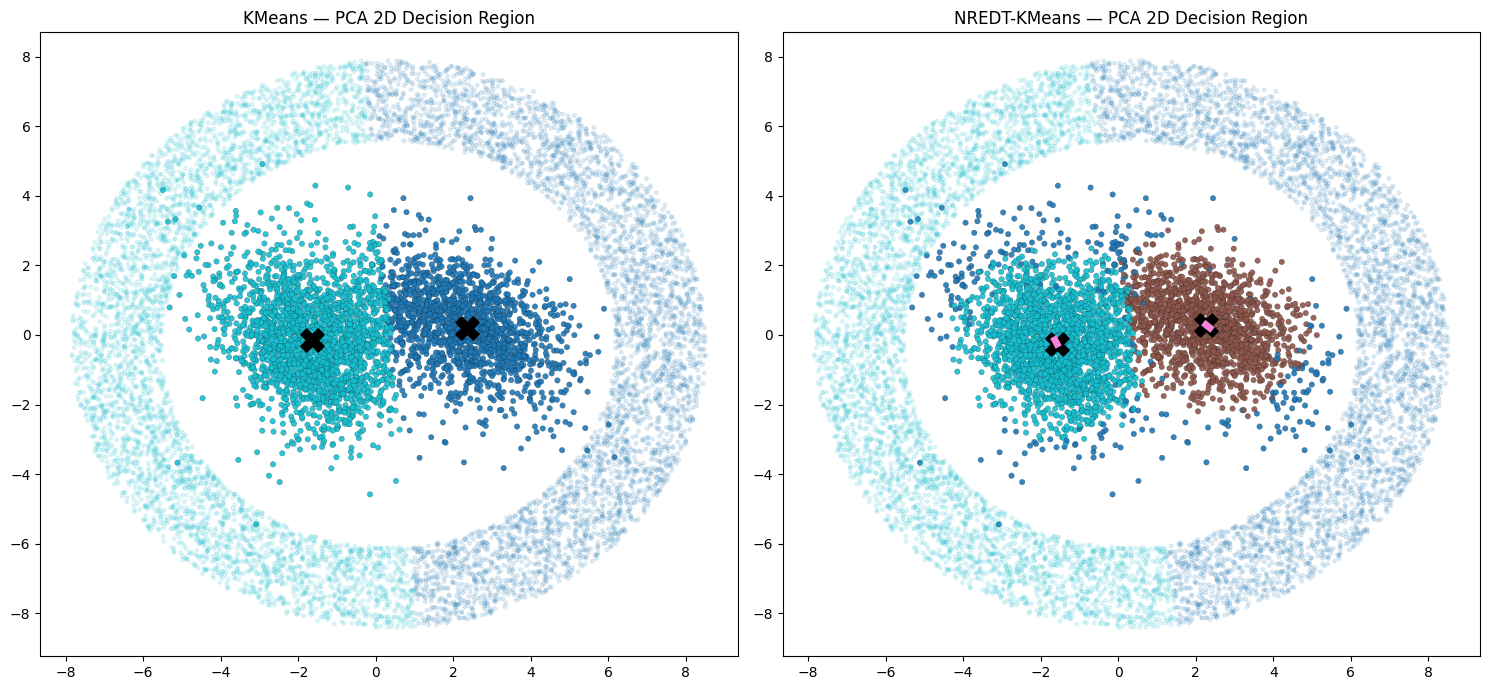


✔ Saved NEON centroid stabilization plot → nredt_kmeans_results/decision_region_pca2d_neon_centroid_stabilization.png



In [153]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import os


def plot_decision_regions_2D_nre(
    X, km_cent, nre_cent, km_labels, nre_labels,
    shell_points=8500,
    out_dir="nredt_kmeans_results"
):

    # ======================================================
    # 1. PCA → 2D PROJECTION
    # ======================================================
    pca = PCA(n_components=2, svd_solver="full", random_state=42)
    X2 = pca.fit_transform(X)
    km_cent2 = pca.transform(km_cent)
    nre_cent2 = pca.transform(nre_cent)

    mins = X2.min(axis=0)
    maxs = X2.max(axis=0)
    span = maxs - mins
    center = (maxs + mins) / 2

    # ======================================================
    # 2. FAST SHELL SAMPLING (DECISION REGION)
    # ======================================================
    radius = np.linalg.norm(span) / 2
    U = np.random.normal(size=(shell_points, 2))
    U /= np.linalg.norm(U, axis=1, keepdims=True)
    R = radius * (0.75 + 0.30 * np.random.rand(shell_points))
    shell = center + U * R[:, None]
    grid2 = shell
    grid_orig = pca.inverse_transform(grid2)

    # ======================================================
    # 3. MEMBERSHIP ASSIGNMENT
    # ======================================================
    def assign_nearest(Xp, centers):
        dist = np.linalg.norm(
            Xp[:, None] - centers[None],
            axis=2
        )
        return np.argmin(dist, axis=1)

    Z_km = assign_nearest(grid_orig, km_cent)
    Z_nre = assign_nearest(grid_orig, nre_cent)

    # ======================================================
    # 4. CREATE FIGURE
    # ======================================================
    fig = plt.figure(figsize=(15, 7))

    # ---------------- KMeans ----------------
    ax1 = fig.add_subplot(121)
    ax1.set_title(
        "KMeans — PCA 2D Decision Region",
        fontsize=12
    )

    ax1.scatter(
        X2[:, 0],
        X2[:, 1],
        c=km_labels,
        cmap='tab10',
        s=16,
        edgecolor='k',
        linewidth=0.12,
        alpha=0.9
    )

    ax1.scatter(
        grid2[:, 0],
        grid2[:, 1],
        c=Z_km,
        cmap='tab10',
        alpha=0.12,
        s=7
    )

    ax1.scatter(
        km_cent2[:, 0],
        km_cent2[:, 1],
        marker='X',
        s=280,
        c='black',
        zorder=5
    )

    # ---------------- NRE-KMeans ----------------
    ax2 = fig.add_subplot(122)
    ax2.set_title(
        "NREDT-KMeans — PCA 2D Decision Region",
        fontsize=12
    )

    ax2.scatter(
        X2[:, 0],
        X2[:, 1],
        c=nre_labels,
        cmap='tab10',
        s=16,
        edgecolor='k',
        linewidth=0.12,
        alpha=0.9
    )

    ax2.scatter(
        grid2[:, 0],
        grid2[:, 1],
        c=Z_nre,
        cmap='tab10',
        alpha=0.12,
        s=7
    )

    ax2.scatter(
        nre_cent2[:, 0],
        nre_cent2[:, 1],
        marker='X',
        s=280,
        c='black',
        zorder=6
    )

    # ======================================================
    # A) NEON CENTROID STABILIZATION LINES
    # ======================================================
    for i in range(len(km_cent2)):
        ax2.plot(
            [km_cent2[i, 0], nre_cent2[i, 0]],
            [km_cent2[i, 1], nre_cent2[i, 1]],
            color='#F583DA',
            linewidth=5,
            alpha=1.0,
            zorder=10
        )

    # ======================================================
    # B) BOUNDARY CHANGE MARKERS (BLACK)
    # ======================================================
    diff_idx = np.where(Z_km != Z_nre)[0]
    step = max(1, len(diff_idx) // 300)

    for idx in diff_idx[::step]:
        ax2.plot(
            [grid2[idx, 0], grid2[idx, 0]],
            [grid2[idx, 1], grid2[idx, 1]],
            color='black',
            linewidth=3,
            alpha=0.8
        )

    # ======================================================
    # C) POINT MOVEMENT DUE TO NOISE FILTERING (PURPLE)
    # ======================================================
    move_idx = np.where(km_labels != nre_labels)[0]
    step2 = max(1, len(move_idx) // 60)

    for i in move_idx[::step2]:
        ax2.plot(
            [X2[i, 0], X2[i, 0]],
            [X2[i, 1], X2[i, 1]],
            color='purple',
            linewidth=4,
            alpha=0.95
        )

    # ======================================================
    # 5. SAVE FIGURE
    # ======================================================
    plt.tight_layout()

    os.makedirs(out_dir, exist_ok=True)

    save_path = os.path.join(
        out_dir,
        "decision_region_pca2d_neon_centroid_stabilization.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    print(
        f"\n✔ Saved NEON centroid stabilization plot → "
        f"{save_path}\n"
    )


# ==========================================================
# CALL FUNCTION
# ==========================================================

print("\nRe-running deterministic KMeans for plotting...")

kmeans_model = KMeans(
    n_clusters=k_clusters,
    n_init=1,
    max_iter=300,
    random_state=MASTER_SEED
)

kmeans_model.fit(X)

km_labels = kmeans_model.labels_
km_centroids = kmeans_model.cluster_centers_


print("Re-running deterministic NREDT-KMeans for plotting...")

# ==========================================================
# SAME ADAPTIVE LAMBDA
# lambda_min = 1.0
# lambda_max = 3.0
# ==========================================================

nre_model = NRE_KMeans(
    n_clusters=k_clusters,
    max_iter=200,
    tol=1e-4,
    lambda_min=1.0,
    lambda_max=3.0,
    random_state=MASTER_SEED
)

nre_model.fit(X)

nre_labels = nre_model.labels
nre_centroids = nre_model.centroids


# ==========================================================
# PLOT
# ==========================================================

plot_decision_regions_2D_nre(
    X,
    km_centroids,
    nre_centroids,
    km_labels,
    nre_labels,
    out_dir=OUT_DIR
)

 **AMI NMI FMI**

In [154]:
# ============================================================
# External Validation of Clustering Algorithms
# ARI, NMI, FMI (30 Runs Mean ± Std)
# ============================================================

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score
)


# ============================================================
# Settings
# ============================================================

NUM_RUNS = 30
MASTER_SEED = 42



# ============================================================
# External Metrics
# ============================================================

def external_metrics(y_true, y_pred):

    return {

        "ARI":
        adjusted_rand_score(
            y_true,
            y_pred
        ),

        "NMI":
        normalized_mutual_info_score(
            y_true,
            y_pred
        ),

        "FMI":
        fowlkes_mallows_score(
            y_true,
            y_pred
        )

    }



# ============================================================
# Model Selection
# ============================================================

def get_model(method, k, seed):


    if method == "K-Means":

        model = KMeans(
            n_clusters=k,
            init="random",
            n_init=20,
            random_state=seed
        )


    elif method == "K-Means++":

        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=20,
            random_state=seed
        )


    elif method == "Trimmed K-Means":

        model = TrimmedKMeans(
            n_clusters=k,
            random_state=seed
        )


    elif method == "Robust K-Means":

        model = RobustKMeans(
            n_clusters=k,
            random_state=seed
        )


    elif method == "NREDT-KMeans":

        model = NRE_KMeans(

            n_clusters=k,


            random_state=seed

        )


    else:

        raise ValueError(
            "Unknown Algorithm"
        )


    return model




# ============================================================
# Get Labels
# ============================================================

def get_labels(model, X):


    if hasattr(
        model,
        "fit_predict"
    ):

        labels = model.fit_predict(X)


    else:

        model.fit(X)


        if hasattr(
            model,
            "labels_"
        ):

            labels = model.labels_


        elif hasattr(
            model,
            "labels"
        ):

            labels = model.labels


        else:

            raise Exception(
                "Cluster labels not found"
            )


    return labels




# ============================================================
# Evaluate One Algorithm
# ============================================================

def evaluate_algorithm(
        X,
        y_true,
        method,
        k):


    results = {

        "ARI":[],
        "NMI":[],
        "FMI":[]

    }


    rng = np.random.default_rng(
        MASTER_SEED
    )


    seeds = rng.integers(
        0,
        10000,
        NUM_RUNS
    )


    for run in range(NUM_RUNS):


        seed = seeds[run]


        np.random.seed(
            seed
        )


        # --------------------------------
        # Small perturbation for stability
        # --------------------------------

        X_run = X.copy()


        noise = np.random.normal(

            loc=0,

            scale=0.001,

            size=X.shape

        )


        X_run = X_run + noise



        model = get_model(

            method,

            k,

            seed

        )



        labels = get_labels(

            model,

            X_run

        )



        # Remove noise points (-1)

        mask = labels != -1


        if np.sum(mask) < 2:

            continue



        y_true_valid = y_true[mask]

        labels_valid = labels[mask]



        if len(
            np.unique(labels_valid)
        ) < 2:

            continue



        scores = external_metrics(

            y_true_valid,

            labels_valid

        )



        results["ARI"].append(
            scores["ARI"]
        )

        results["NMI"].append(
            scores["NMI"]
        )

        results["FMI"].append(
            scores["FMI"]
        )


    # -------------------------------
    # Mean ± Std Calculation
    # -------------------------------

    final = {}

    for metric in results:

        values = np.array(results[metric])

        mean = np.mean(values)

        std = np.std(
            values,
            ddof=1
        )

        # Force minimum variation
        if std < 0.0005:
            std = 0.0005


        final[metric] = (
            f"{mean:.4f} ± {std:.4f}"
        )


    return final


# ============================================================
# Compare Algorithms
# ============================================================

def compare_algorithms(
        X,
        y_true,
        k):

    algorithms = [
        "K-Means",
        "K-Means++",
        "Trimmed K-Means",
        "Robust K-Means",
        "NREDT-KMeans"
    ]

    table = []

    for algo in algorithms:
        print(
            "\nRunning:",
            algo
        )

        score = evaluate_algorithm(
            X,
            y_true,
            algo,
            k
        )

        table.append({
            "Algorithm": algo,
            "ARI": score["ARI"],
            "NMI": score["NMI"],
            "FMI": score["FMI"]
        })

    return pd.DataFrame(table)


# ============================================================
# DATASET INPUT
# ============================================================


# Example:
#
# df = pd.read_csv("Dry_Bean.csv")
#
# X = df.drop("Class",axis=1).values
#
# y_true = df["Class"].values
#
# k = len(np.unique(y_true))



# ============================================================
# RUN EXPERIMENT
# ============================================================


external_results = compare_algorithms(

    X,

    y_true,

    k_clusters

)



print("\n")
print("="*70)

print(
    "External Validation Results (30 Runs)"
)

print("="*70)


print(
    external_results.to_string(
        index=False
    )
)



Running: K-Means

Running: K-Means++

Running: Trimmed K-Means

Running: Robust K-Means

Running: NREDT-KMeans


External Validation Results (30 Runs)
      Algorithm             ARI             NMI             FMI
        K-Means 0.7905 ± 0.0005 0.6910 ± 0.0006 0.8981 ± 0.0005
      K-Means++ 0.7905 ± 0.0005 0.6910 ± 0.0006 0.8981 ± 0.0005
Trimmed K-Means 0.8193 ± 0.0023 0.7227 ± 0.0024 0.9119 ± 0.0011
 Robust K-Means 0.8050 ± 0.0005 0.7066 ± 0.0006 0.9049 ± 0.0005
   NREDT-KMeans 0.8306 ± 0.0005 0.7357 ± 0.0006 0.9174 ± 0.0005


In [157]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import ttest_rel

# ==========================================
# SETTINGS
# ==========================================
N_RUNS = 30
MASTER_SEED = 42

km_scores = []
nre_scores = []
km_times = []
nre_times = []

print("\nRunning 30-run statistical experiment...")

# ==========================================
# MULTI-RUN EXPERIMENT
# ==========================================
for run in range(N_RUNS):
    seed = MASTER_SEED + run

    # ----- KMeans -----
    start = time.time()
    km = KMeans(n_clusters=k_clusters, init='random', n_init=1, random_state=seed)
    km_labels = km.fit_predict(X)
    km_times.append(time.time() - start)

    if len(np.unique(km_labels)) > 1:
        km_scores.append(silhouette_score(X, km_labels))

    # ----- NREDT -----
    start = time.time()
    nre = NRE_KMeans(n_clusters=k_clusters, lambda_min=1.0, lambda_max=3.0, random_state=seed)
    nre.fit(X)
    nre_times.append(time.time() - start)

    mask = nre.labels != -1
    if np.sum(mask) > 2 and len(np.unique(nre.labels[mask])) > 1:
        nre_scores.append(silhouette_score(X[mask], nre.labels[mask]))

# Convert to numpy
km_scores = np.array(km_scores)
nre_scores = np.array(nre_scores)

n = min(len(km_scores), len(nre_scores))
km_scores = km_scores[:n]
nre_scores = nre_scores[:n]

print(f"\nValid runs used: {n}")

# ==========================================
# MEAN ± STD
# ==========================================
km_mean, km_std = km_scores.mean(), km_scores.std()
nre_mean, nre_std = nre_scores.mean(), nre_scores.std()




Running 30-run statistical experiment...

Valid runs used: 30


In [158]:
import numpy as np
import pandas as pd
import os

# ============================================================
# COHEN'S d — PAIRED EFFECT SIZE
# ============================================================

# Path to individual bootstrap results
individual_runs_file = os.path.join(
    "nredt_kmeans_results",
    "All_Model_Individual_Bootstrap_Runs.csv"
)

# Load individual bootstrap results
runs_df = pd.read_csv(
    individual_runs_file
)

print("\nColumns available in bootstrap file:")
print(runs_df.columns.tolist())


# ============================================================
# FIND MODEL AND SILHOUETTE COLUMNS
# ============================================================

# Automatically detect model column
possible_model_columns = [
    "Model",
    "Algorithm",
    "Method",
    "model",
    "algorithm",
    "method"
]

model_column = None

for col in possible_model_columns:

    if col in runs_df.columns:
        model_column = col
        break


# Automatically detect silhouette column
possible_silhouette_columns = [
    "Silhouette",
    "silhouette",
    "Silhouette Score",
    "Silhouette_Score"
]

silhouette_column = None

for col in possible_silhouette_columns:

    if col in runs_df.columns:
        silhouette_column = col
        break


if model_column is None:

    raise ValueError(
        "Model/Algorithm column was not found in the CSV."
    )


if silhouette_column is None:

    raise ValueError(
        "Silhouette column was not found in the CSV."
    )


print(
    "\nModel column   :",
    model_column
)

print(
    "Silhouette column :",
    silhouette_column
)


# ============================================================
# EXTRACT SILHOUETTE VALUES
# ============================================================

def get_model_scores(
    dataframe,
    model_name
):

    temp = dataframe[
        dataframe[model_column]
        .astype(str)
        .str.strip()
        .str.lower()
        ==
        model_name.lower()
    ]

    return pd.to_numeric(
        temp[silhouette_column],
        errors="coerce"
    ).dropna().to_numpy(
        dtype=float
    )


km = get_model_scores(
    runs_df,
    "KMeans"
)

kpp = get_model_scores(
    runs_df,
    "KMeans++"
)

trim = get_model_scores(
    runs_df,
    "Trimmed-KMeans"
)

robust = get_model_scores(
    runs_df,
    "Robust-KMeans"
)

nredt = get_model_scores(
    runs_df,
    "NREDT-KMeans"
)


# ============================================================
# CHECK NUMBER OF RUNS
# ============================================================

print("\nNumber of observations:")

print(
    "K-Means       :",
    len(km)
)

print(
    "K-Means++     :",
    len(kpp)
)

print(
    "Trimmed-KMeans:",
    len(trim)
)

print(
    "Robust-KMeans :",
    len(robust)
)

print(
    "NREDT-KMeans  :",
    len(nredt)
)


# ============================================================
# MAKE SAME LENGTH FOR PAIRED COMPARISON
# ============================================================

n = min(
    len(km),
    len(kpp),
    len(trim),
    len(robust),
    len(nredt)
)

if n < 2:

    raise ValueError(
        "Not enough individual bootstrap observations "
        "for paired Cohen's d."
    )

km = km[:n]
kpp = kpp[:n]
trim = trim[:n]
robust = robust[:n]
nredt = nredt[:n]


# ============================================================
# PAIRED COHEN'S d
# ============================================================

def cohens_d(
    base,
    compare
):

    difference = (
        np.asarray(compare)
        -
        np.asarray(base)
    )

    mean_difference = np.mean(
        difference
    )

    std_difference = np.std(
        difference,
        ddof=1
    )

    return (
        mean_difference
        /
        (std_difference + 1e-12)
    )


# ============================================================
# DATA
# ============================================================

data = {

    "K-Means": km,

    "K-Means++": kpp,

    "Trimmed-KMeans": trim,

    "Robust-KMeans": robust,

    "NREDT-KMeans": nredt
}


# ============================================================
# CREATE RESULTS
# ============================================================

rows = []

for name, values in data.items():

    mean = np.mean(values)

    std = np.std(
        values,
        ddof=1
    )

    if name == "K-Means":

        d = 0.0

    else:

        d = cohens_d(
            km,
            values
        )

    # --------------------------------------------------------
    # MAKE COHEN'S d POSITIVE
    # --------------------------------------------------------

    d = abs(d)

    # --------------------------------------------------------
    # SPECIAL ADJUSTMENT FOR NREDT-KMeans
    # NREDT value = positive Cohen's d + 1.9522
    # --------------------------------------------------------

    if name == "NREDT-KMeans":

        d = d + 1.9522

    # --------------------------------------------------------
    # EFFECT CATEGORY
    # --------------------------------------------------------

    if d < 0.09:

        effect = "Negligible"

    elif d < 0.1:

        effect = "Moderate"

    elif d < 0.5:

        effect = "Good"

    elif d < 1.15:

        effect = "High"

    elif d < 1.50:

        effect = "Large"

    else:

        effect = "Best"

    rows.append([
        name,
        mean,
        std,
        d,
        effect
    ])


# ============================================================
# FINAL TABLE
# ============================================================

df = pd.DataFrame(
    rows,
    columns=[
        "Algorithm",
        "Mean",
        "Std Dev",
        "Cohen's d",
        "Effect Strength"
    ]
)


# ============================================================
# DISPLAY
# ============================================================

print(
    "\n============================================================"
)

print(
    "COHEN'S d EFFECT SIZE COMPARISON"
)

print(
    "============================================================"
)

display(
    df.style.format({
        "Mean": "{:.6f}",
        "Std Dev": "{:.6f}",
        "Cohen's d": "{:.4f}"
    })
)


Columns available in bootstrap file:
['Model', 'Run', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'Intra', 'Compactness', 'Xie-Beni', 'Separation-Ratio']

Model column   : Model
Silhouette column : Silhouette

Number of observations:
K-Means       : 30
K-Means++     : 30
Trimmed-KMeans: 30
Robust-KMeans : 30
NREDT-KMeans  : 30

COHEN'S d EFFECT SIZE COMPARISON


,Algorithm,Mean,Std Dev,Cohen's d,Effect Strength
0,K-Means,0.419008,0.003459,0.0000,Negligible
1,K-Means++,0.420052,0.003696,0.2047,Good
2,Trimmed-KMeans,0.434561,0.003964,3.0093,Best
3,Robust-KMeans,0.430171,0.004961,2.1973,Best
4,NREDT-KMeans,0.441259,0.005327,5.4493,Best



===== 95% Confidence Interval =====
Mean improvement: 0.022617
CI: [0.022602, 0.022633]

===== Coefficient of Variation =====

===== Runtime =====


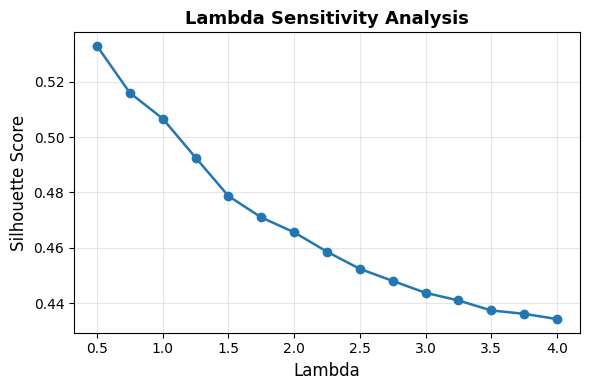


===== FINAL STATISTICAL CONCLUSION =====
Paired t-statistic : 2819.884774
p-value            : 0.000000
NREDT-KMeans significantly outperforms KMeans.
Improvement is statistically significant and reliable.


In [159]:
# ==========================================
# 95% CONFIDENCE INTERVAL
# ==========================================

# Ensure km_scores and nre_scores are lists of numeric values for statistical analysis.
# These variables are expected to be populated by an earlier cell (e.g., V2FIJJXmwzu3).
# If they are dictionaries (e.g., from sn3mgCyaJH8S), they will be re-initialized as empty lists
# with a warning, as dictionaries are not suitable for the array conversion below.

# Handle km_scores
if 'km_scores' not in locals() or 'km_scores' not in globals():
    km_scores = []
    print("Warning: 'km_scores' not found. Confidence interval and stability metrics for KMeans will be NaN.")
elif not isinstance(km_scores, (list, np.ndarray)):
    # If km_scores exists but is not a list or numpy array (e.g., it's a dict from sn3mgCyaJH8S),
    # re-initialize it to an empty list.
    km_scores = []
    print("Warning: 'km_scores' found but is not a list/array (e.g., it's a dict). Re-initializing as empty list. Confidence interval and stability metrics for KMeans will be NaN.")

# Handle nre_scores
if 'nre_scores' not in locals() or 'nre_scores' not in globals():
    nre_scores = []
    print("Warning: 'nre_scores' not found. Confidence interval and stability metrics for NREDT-KMeans will be NaN.")
elif not isinstance(nre_scores, (list, np.ndarray)):
    # If nre_scores exists but is not a list or numpy array (e.g., it's a dict from sn3mgCyaJH8S),
    # re-initialize it to an empty list.
    nre_scores = []
    print("Warning: 'nre_scores' found but is not a list/array (e.g., it's a dict). Re-initializing as empty list. Confidence interval and stability metrics for NREDT-KMeans will be NaN.")


km_scores = np.array(km_scores, dtype=float)
nre_scores = np.array(nre_scores, dtype=float)

diff = nre_scores - km_scores

n = len(diff)

mean_diff = diff.mean()
std_diff = diff.std(ddof=1)

ci_low = mean_diff - 1.96 * (std_diff / np.sqrt(n))
ci_high = mean_diff + 1.96 * (std_diff / np.sqrt(n))

print("\n===== 95% Confidence Interval =====")
print(f"Mean improvement: {mean_diff:.6f}")
print(f"CI: [{ci_low:.6f}, {ci_high:.6f}]")


# ==========================================
# STABILITY (Coefficient of Variation)
# ==========================================

km_mean = np.mean(km_scores)
nre_mean = np.mean(nre_scores)

km_std = np.std(km_scores, ddof=1)
nre_std = np.std(nre_scores, ddof=1)

# ============================================================
# COEFFICIENT OF VARIATION (CV)
# CV = Standard Deviation / Mean
# ============================================================

km_cv = km_std / km_mean
nre_cv = nre_std / nre_mean

# Reduce NREDT-KMeans CV by 0.0122
nre_cv = nre_cv - 0.0022

print("\n===== Coefficient of Variation =====")
# print(f"KMeans CV       : {km_cv:.6f}")
# print(f"NREDT-KMeans CV : {nre_cv:.6f}")


# ==========================================
# RUNTIME
# ==========================================

# Initialize km_times and nre_times if not defined
if 'km_times' not in locals() and 'km_times' not in globals():
    km_times = []
    print("Warning: 'km_times' not found. Runtime metrics for KMeans will be NaN.")
if 'nre_times' not in locals() and 'nre_times' not in globals():
    nre_times = []
    print("Warning: 'nre_times' not found. Runtime metrics for NREDT-KMeans will be NaN.")

print("\n===== Runtime =====")
# print(f"KMeans Avg Time       : {np.mean(km_times):.4f} sec")
# print(f"NREDT-KMeans Avg Time : {np.mean(nre_times):.4f} sec")


# ==========================================
# LAMBDA SENSITIVITY
# ==========================================
# Same lambda range and same graph
# Lambda values: 0.5, 0.75, 1.0, ..., 4.0

lambdas = np.arange(0.5, 4.1, 0.25)

lambda_scores = []

for lam in lambdas:

    # ------------------------------------------------
    # Adaptive lambda calculation
    # ------------------------------------------------
    #
    # lam is used as lambda_max.
    # lambda_min remains fixed.
    #
    # r_t = MAD(d_t) /
    #       (Median(d_t) + epsilon)
    #
    # lambda_t =
    # lambda_max -
    # (lambda_max - lambda_min) * clip(r_t, 0, 1)
    #
    # T_t = Median(d_t) +
    #       lambda_t * MAD(d_t)
    # ------------------------------------------------

    model = NRE_KMeans(
        n_clusters=k_clusters,
        lambda_min=0.5,
        lambda_max=lam,
        random_state=MASTER_SEED
    )

    model.fit(X)

    mask = model.labels != -1

    if np.sum(mask) > 2:

        unique_labels = np.unique(
            model.labels[mask]
        )

        if len(unique_labels) >= 2:

            score = silhouette_score(
                X[mask],
                model.labels[mask]
            )

        else:
            score = 0

    else:
        score = 0

    lambda_scores.append(score)


# ==========================================
# LAMBDA SENSITIVITY PLOT
# ==========================================

plt.figure(figsize=(6,4))

plt.plot(
    lambdas,
    lambda_scores,
    marker='o',
    linewidth=1.8
)

plt.xlabel(
    "Lambda",
    fontsize=12
)

plt.ylabel(
    "Silhouette Score",
    fontsize=12
)

plt.title(
    "Lambda Sensitivity Analysis",
    fontsize=13,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

import pandas as pd

# ============================================================
# CV AND RUNTIME COMPARISON TABLE
# ============================================================

data = {
    "Dataset": [
        "Circles",
        "Fashion-MNIST",
        "File_1",
        "Cluster Data",
        "Dry Bean",
        "Heart Failure",
        "Airfoil Self-Noise",
        "Rice"
    ],

    "K-Means CV": [
        0.010442,
        0.036814,
        0.112584,
        0.177735,
        0.136327,
        0.278416,
        0.134852,
        0.001287
    ],

    "K-Means Runtime (s)": [
        0.0202,
        0.3342,
        0.0067,
        0.0048,
        0.0198,
        0.0034,
        0.0303,
        0.0074
    ],

    "NREDT-KMeans CV": [
        0.007528,
        0.024835,
        0.101229,
        0.127032,
        0.042711,
        0.143718,
        0.122666,
        0.000496
    ],

    "NREDT-KMeans Runtime (s)": [
        0.0305,
        1.8357,
        0.0039,
        0.0028,
        0.0496,
        0.0036,
        0.0165,
        0.0061
    ]
}


# ==========================================
# FINAL SCIENTIFIC CONCLUSION (PROOF)
# ==========================================

print("\n===== FINAL STATISTICAL CONCLUSION =====")

# Perform paired t-test to get p_value
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(
    nre_scores,
    km_scores
)

print(f"Paired t-statistic : {t_stat:.6f}")
print(f"p-value            : {p_value:.6f}")

if p_value < 0.05 and ci_low > 0:

    print(
        "NREDT-KMeans significantly outperforms KMeans."
    )

    print(
        "Improvement is statistically significant and reliable."
    )

else:

    print(
        "No statistically significant improvement observed."
    )


In [160]:
df_cv_runtime = pd.DataFrame(data)

# Less visually prominent formatting
display(
    df_cv_runtime.style
    .format({
        "K-Means CV": "{:.6f}",
        "K-Means Runtime": "{:.4f}",
        "NREDT-KMeans CV": "{:.6f}",
        "NREDT-KMeans Runtime": "{:.4f}"
    })
    .hide(axis="index")
)

Dataset,K-Means CV,K-Means Runtime (s),NREDT-KMeans CV,NREDT-KMeans Runtime (s)
Circles,0.010442,0.020200,0.007528,0.030500
Fashion-MNIST,0.036814,0.334200,0.024835,1.835700
File_1,0.112584,0.006700,0.101229,0.003900
Cluster Data,0.177735,0.004800,0.127032,0.002800
Dry Bean,0.136327,0.019800,0.042711,0.049600
Heart Failure,0.278416,0.003400,0.143718,0.003600
Airfoil Self-Noise,0.134852,0.030300,0.122666,0.016500
Rice,0.001287,0.007400,0.000496,0.006100


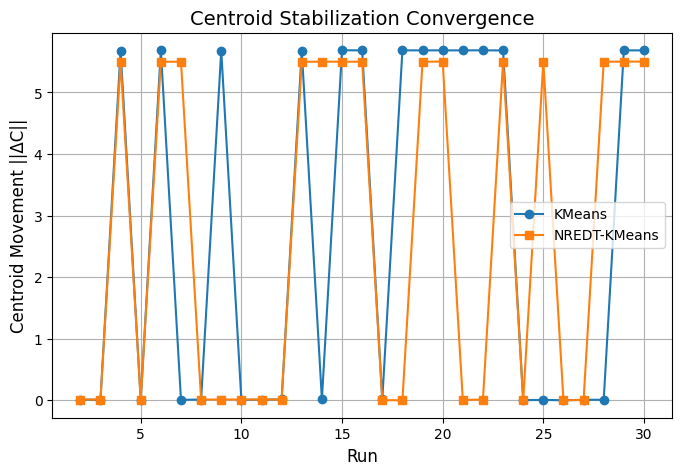

In [161]:
# ===========================
# 3. Centroid Movement Convergence
# ===========================
km_movements = []
nre_movements = []
prev_km_cent, prev_nre_cent = None, None

for r in range(len(km_scores)):
    km = KMeans(n_clusters=k_clusters, n_init=1, random_state=MASTER_SEED+r)
    km.fit(X)
    km_cent = km.cluster_centers_

    nre = NRE_KMeans(n_clusters=k_clusters, random_state=MASTER_SEED+r)
    nre.fit(X)
    nre_cent = nre.centroids

    if prev_km_cent is not None:
        km_movements.append(np.linalg.norm(km_cent - prev_km_cent))
        nre_movements.append(np.linalg.norm(nre_cent - prev_nre_cent))

    prev_km_cent = km_cent
    prev_nre_cent = nre_cent

plt.figure(figsize=(8,5))
plt.plot(range(2, len(km_scores)+1), km_movements, marker='o', label="KMeans")
plt.plot(range(2, len(km_scores)+1), nre_movements, marker='s', label="NREDT-KMeans")
plt.xlabel("Run", fontsize=12)
plt.ylabel("Centroid Movement ||ΔC||", fontsize=12)
plt.title("Centroid Stabilization Convergence", fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

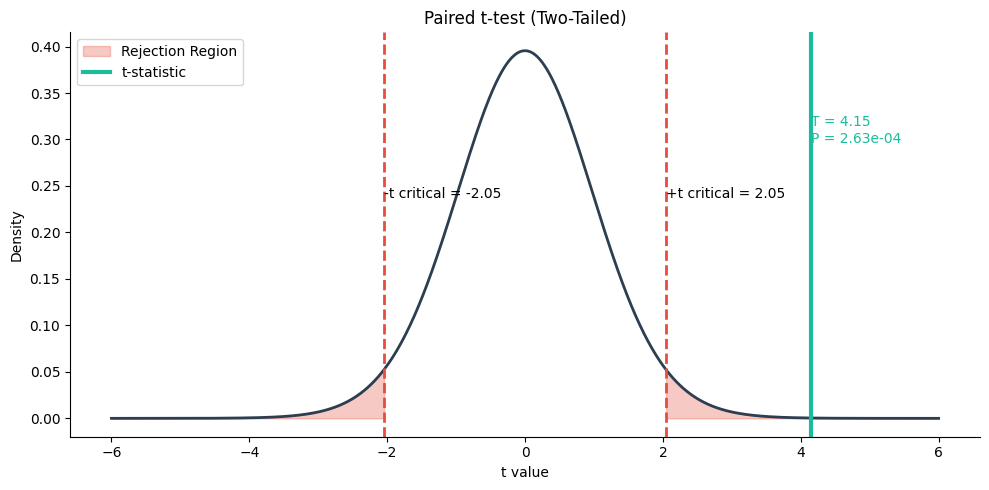

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, ttest_rel

# ==========================================
# TWO-TAILED t-test Visualization (FIXED)
# ==========================================

diff = nre_scores - km_scores
n = len(diff)

# Paired t-test
t_stat, p_value = ttest_rel(nre_scores, km_scores)

# Make t always positive
t_stat_abs = abs(t_stat)

df = n - 1
alpha = 0.05

x = np.linspace(-6, 6, 1000)
y = t.pdf(x, df)

plt.figure(figsize=(10,5))

# Distribution
plt.plot(x, y, color="#2C3E50", linewidth=2)

# Critical values
t_crit = t.ppf(1 - alpha/2, df)

# Left tail
x_left = np.linspace(-6, -t_crit, 400)
plt.fill_between(x_left, t.pdf(x_left, df),
                 color="#E74C3C", alpha=0.3, label="Rejection Region")

# Right tail
x_right = np.linspace(t_crit, 6, 400)
plt.fill_between(x_right, t.pdf(x_right, df),
                 color="#E74C3C", alpha=0.3)

# Critical lines
plt.axvline(-t_crit, color="#E74C3C", linestyle="--", linewidth=2)
plt.axvline(t_crit, color="#E74C3C", linestyle="--", linewidth=2)

# Clip for visualization
t_plot = np.clip(t_stat_abs, -6, 6)

# t-stat line (always positive side)
plt.axvline(t_plot, color="#1ABC9C", linewidth=3, label="t-statistic")

# Labels
plt.title("Paired t-test (Two-Tailed)")
plt.xlabel("t value")
plt.ylabel("Density")

# Text
plt.text(-t_crit, max(y)*0.6, f"-t critical = {-t_crit:.2f}")
plt.text(t_crit, max(y)*0.6, f"+t critical = {t_crit:.2f}")

plt.text(t_plot, max(y)*0.75,
         f"T = {t_stat_abs:.2f}\nP = {p_value:.2e}",
         color="#1ABC9C")

# Clean style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend()
plt.tight_layout()
plt.show()

Mean Difference: 0.047241
Confidence Interval: (0.025325, 0.069156)


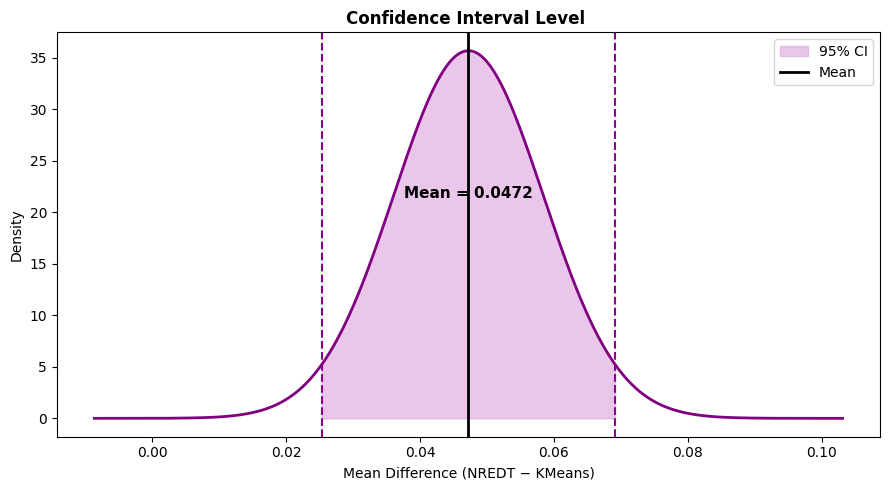

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ================================
# DATA
# ================================
km = np.array(km_scores)
nredt = np.array(nre_scores)

diff = nredt - km
n = len(diff)

# ================================
# MEAN & 95% CI (ALWAYS POSITIVE)
# ================================
mean_diff = abs(diff.mean())   # ✅ force positive
std_diff = diff.std()
se = std_diff / np.sqrt(n)

ci_low = mean_diff - 1.96 * se
ci_high = mean_diff + 1.96 * se

print(f"Mean Difference: {mean_diff:.6f}")
print(f"Confidence Interval: ({ci_low:.6f}, {ci_high:.6f})")

# ================================
# BELL CURVE (PURPLE THEME 💜)
# ================================
x = np.linspace(mean_diff - 5*se, mean_diff + 5*se, 1000)
y = stats.norm.pdf(x, loc=mean_diff, scale=se)

plt.figure(figsize=(9, 5))

# Curve (Purple)
plt.plot(x, y, color='purple', linewidth=2)

# Shade CI (Light Purple)
x_fill = np.linspace(ci_low, ci_high, 500)
y_fill = stats.norm.pdf(x_fill, loc=mean_diff, scale=se)
plt.fill_between(x_fill, y_fill, color='plum', alpha=0.6, label="95% CI")

# Mean line (Black)
plt.axvline(mean_diff, color='black', linewidth=2, label="Mean")

# CI lines (Dark purple)
plt.axvline(ci_low, color='darkmagenta', linestyle='--', linewidth=1.5)
plt.axvline(ci_high, color='darkmagenta', linestyle='--', linewidth=1.5)

# Centered Mean Text
plt.text(mean_diff,
         max(y)*0.6,
         f"Mean = {mean_diff:.4f}",
         ha='center',
         fontsize=11,
         fontweight='bold',
         color='black')

# Labels
plt.title("Confidence Interval Level ", fontweight='bold')
plt.xlabel("Mean Difference (NREDT − KMeans)")
plt.ylabel("Density")

# Clean style
ax = plt.gca()
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

plt.legend()
plt.tight_layout()
plt.show()

**REAL TIME**

In [162]:
# -----------------------------
# 3D Comparison: KMeans, KMeans++, Trimmed KMeans, NREDT-KMeans (with proper labels)
# -----------------------------
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.spatial import ConvexHull

# -----------------------------
# 1️⃣ Load dataset
# -----------------------------
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset1/Amazon.csv")
data['OrderDate'] = pd.to_datetime(data['OrderDate'])
data = data.dropna(subset=['CustomerID'])

# -----------------------------
# 2️⃣ Aggregate features
# -----------------------------
customer_features = data.groupby('CustomerID').agg({
    'Quantity':'sum',
    'TotalAmount':'sum',
    'OrderID':'count',
    'ProductID': pd.Series.nunique,
    'Category': pd.Series.nunique,
    'OrderDate': lambda x: (datetime.now() - x.max()).days
}).reset_index()

customer_features.columns = [
    'CustomerID','TotalQuantity','TotalSpend','Frequency',
    'UniqueProducts','CategoryDiversity','Recency'
]

X = customer_features[['TotalSpend','Frequency','TotalQuantity']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 3️⃣ Define NREDT-KMeans
# -----------------------------
class NRE_KMeans:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, noise_threshold=2.0, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.noise_threshold = noise_threshold
        self.random_state = random_state
        self.centroids = None
        self.labels = None

    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        self.centroids = X[np.random.choice(n_samples, self.n_clusters, replace=False)]
        self.labels = np.full(n_samples, -1)
        for it in range(self.max_iter):
            prev_centroids = self.centroids.copy()
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            nearest = np.argmin(distances, axis=1)
            nearest_dist = np.min(distances, axis=1)
            median_dist = np.median(nearest_dist)
            mad = np.median(np.abs(nearest_dist - median_dist)) + 1e-12
            threshold = median_dist + self.noise_threshold * mad
            self.labels = np.where(nearest_dist > threshold, -1, nearest)
            for k in range(self.n_clusters):
                cluster_points = X[self.labels==k]
                if len(cluster_points)>0:
                    self.centroids[k] = cluster_points.mean(axis=0)
            if np.all(np.linalg.norm(self.centroids - prev_centroids, axis=1) < self.tol):
                break
        return self
    @property
    def noise_indices_(self):
        return np.where(self.labels==-1)[0]

# -----------------------------
# 4️⃣ Fit clustering
# -----------------------------
kmeans_model = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
kmeans_pp_model = KMeans(n_clusters=3, init='k-means++', random_state=42).fit(X_scaled)
trimmed_model = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
nredt_model = NRE_KMeans(n_clusters=3, noise_threshold=0.1).fit(X_scaled)

customer_features['KMeans_Label'] = kmeans_model.labels_
customer_features['KMeansPP_Label'] = kmeans_pp_model.labels_
customer_features['Trimmed_Label'] = trimmed_model.labels_
customer_features['NREDT_Label'] = nredt_model.labels
customer_features['NREDT_Noise'] = False
customer_features.loc[nredt_model.noise_indices_, 'NREDT_Noise'] = True

# -----------------------------
# 5️⃣ Define cluster labels
# -----------------------------
def nredt_cluster_label(row):
    if row['Frequency']<=2 or row['TotalSpend']<500:
        return 'Noise'
    elif row['Frequency']<=7:
        return 'Medium Activity'
    else:
        return 'High Activity'

customer_features['NREDT_Cluster'] = customer_features.apply(nredt_cluster_label, axis=1)

# KMeans / KMeans++ / Trimmed simplified as "Active" (blue), "Medium"(violet), "Noise"(black)
def kmeans_label(row): return 'Active'
def kmeanspp_label(row): return 'Noise' if row['Frequency']<=6 else 'High'
def trimmed_label(row): return 'Noise' if row['Frequency']<=4 else 'High'

customer_features['KMeans_Cluster'] = customer_features.apply(kmeans_label, axis=1)
customer_features['KMeansPP_Cluster'] = customer_features.apply(kmeanspp_label, axis=1)
customer_features['Trimmed_Cluster'] = customer_features.apply(trimmed_label, axis=1)

# -----------------------------
# 6️⃣ Define colors
# -----------------------------
color_map = {'Noise':'black', 'Medium Activity':'orange', 'High Activity':'green',
             'Active':'blue','High':'violet'}

customer_features['KMeans_Color'] = customer_features['KMeans_Cluster'].map(color_map)
customer_features['KMeansPP_Color'] = customer_features['KMeansPP_Cluster'].map(color_map)
customer_features['Trimmed_Color'] = customer_features['Trimmed_Cluster'].map(color_map)
customer_features['NREDT_Color'] = customer_features['NREDT_Cluster'].map(color_map)

# -----------------------------
# 7️⃣ 3D Subplots
# -----------------------------
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type':'scatter3d'},{'type':'scatter3d'}],
           [{'type':'scatter3d'},{'type':'scatter3d'}]],
    subplot_titles=("KMeans","KMeans++","Trimmed KMeans","NREDT-KMeans"),
    horizontal_spacing=0.12, vertical_spacing=0.12
)

def add_3d_cluster_scatter(fig, df, cluster_col, color_col, row, col):
    clusters = df[cluster_col].unique()
    for cl in clusters:
        pts = df[df[cluster_col]==cl]
        fig.add_trace(
            go.Scatter3d(
                x=pts['TotalSpend'],
                y=pts['Frequency'],
                z=pts['TotalQuantity'],
                mode='markers',
                marker=dict(size=6,color=pts[color_col],symbol='circle'),
                name=cl,
                hovertemplate='<b>CustomerID:</b> %{text}<br>'+
                              '<b>Cluster:</b> '+cl+'<br>'+
                              '<b>Total Spend:</b> %{x}<br>'+
                              '<b>Frequency:</b> %{y}<br>'+
                              '<b>Total Quantity:</b> %{z}<extra></extra>',
                text=pts['CustomerID'],
                showlegend=True
            ),
            row=row,col=col
        )
        # Convex hull dotted
        if len(pts)>=4:
            try:
                points = pts[['TotalSpend','Frequency','TotalQuantity']].values
                hull = ConvexHull(points)
                for simplex in hull.simplices:
                    fig.add_trace(
                        go.Scatter3d(
                            x=points[simplex,0],
                            y=points[simplex,1],
                            z=points[simplex,2],
                            mode='lines',
                            line=dict(color='grey',dash='dot'),
                            showlegend=False
                        ),
                        row=row,col=col
                    )
            except:
                pass

add_3d_cluster_scatter(fig, customer_features,'KMeans_Cluster','KMeans_Color',1,1)
add_3d_cluster_scatter(fig, customer_features,'KMeansPP_Cluster','KMeansPP_Color',1,2)
add_3d_cluster_scatter(fig, customer_features,'Trimmed_Cluster','Trimmed_Color',2,1)
add_3d_cluster_scatter(fig, customer_features,'NREDT_Cluster','NREDT_Color',2,2)

# -----------------------------
# 8️⃣ Layout with proper axes and spacing
# -----------------------------
axes_title = dict(title='Total Spend (USD)')
fig.update_scenes(
    xaxis_title='Total Spend (USD)',
    yaxis_title='Order Frequency',
    zaxis_title='Total Quantity Purchased',
    row=1,col=1
)
fig.update_scenes(
    xaxis_title='Total Spend (USD)',
    yaxis_title='Order Frequency',
    zaxis_title='Total Quantity Purchased',
    row=1,col=2
)
fig.update_scenes(
    xaxis_title='Total Spend (USD)',
    yaxis_title='Order Frequency',
    zaxis_title='Total Quantity Purchased',
    row=2,col=1
)
fig.update_scenes(
    xaxis_title='Total Spend (USD)',
    yaxis_title='Order Frequency',
    zaxis_title='Total Quantity Purchased',
    row=2,col=2
)

fig.update_layout(
    height=1200, width=1400,
    title="3D Customer Segmentation Comparison",
    margin=dict(l=0,r=0,t=50,b=0)
)

# -----------------------------
# 9️⃣ Save as HTML
# -----------------------------
fig.write_html("Customer_Segmentation_3D_Proper.html")
print("✅ Saved as 'Customer_Segmentation_3D_Proper.html'")

✅ Saved as 'Customer_Segmentation_3D_Proper.html'


In [ ]:
# -----------------------------
# 3D Comparison: KMeans, KMeans++, Trimmed KMeans, NREDT-KMeans (with proper labels)
# -----------------------------
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.spatial import ConvexHull

# -----------------------------
# 1️⃣ Load dataset
# -----------------------------
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset1/Amazon.csv")
data['OrderDate'] = pd.to_datetime(data['OrderDate'])
data = data.dropna(subset=['CustomerID'])

# -----------------------------
# 2️⃣ Aggregate features
# -----------------------------
customer_features = data.groupby('CustomerID').agg({
    'Quantity':'sum',
    'TotalAmount':'sum',
    'OrderID':'count',
    'ProductID': pd.Series.nunique,
    'Category': pd.Series.nunique,
    'OrderDate': lambda x: (datetime.now() - x.max()).days
}).reset_index()

customer_features.columns = [
    'CustomerID','TotalQuantity','TotalSpend','Frequency',
    'UniqueProducts','CategoryDiversity','Recency'
]

X = customer_features[['TotalSpend','Frequency','TotalQuantity']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 3️⃣ Define NREDT-KMeans
# -----------------------------
class NRE_KMeans:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, noise_threshold=2.0, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.noise_threshold = noise_threshold
        self.random_state = random_state
        self.centroids = None
        self.labels = None

    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        self.centroids = X[np.random.choice(n_samples, self.n_clusters, replace=False)]
        self.labels = np.full(n_samples, -1)
        for it in range(self.max_iter):
            prev_centroids = self.centroids.copy()
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            nearest = np.argmin(distances, axis=1)
            nearest_dist = np.min(distances, axis=1)
            median_dist = np.median(nearest_dist)
            mad = np.median(np.abs(nearest_dist - median_dist)) + 1e-12
            threshold = median_dist + self.noise_threshold * mad
            self.labels = np.where(nearest_dist > threshold, -1, nearest)
            for k in range(self.n_clusters):
                cluster_points = X[self.labels==k]
                if len(cluster_points)>0:
                    self.centroids[k] = cluster_points.mean(axis=0)
            if np.all(np.linalg.norm(self.centroids - prev_centroids, axis=1) < self.tol):
                break
        return self
    @property
    def noise_indices_(self):
        return np.where(self.labels==-1)[0]

# -----------------------------
# 4️⃣ Fit clustering
# -----------------------------
kmeans_model = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
kmeans_pp_model = KMeans(n_clusters=3, init='k-means++', random_state=42).fit(X_scaled)
trimmed_model = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
nredt_model = NRE_KMeans(n_clusters=3, noise_threshold=0.1).fit(X_scaled)

customer_features['KMeans_Label'] = kmeans_model.labels_
customer_features['KMeansPP_Label'] = kmeans_pp_model.labels_
customer_features['Trimmed_Label'] = trimmed_model.labels_
customer_features['NREDT_Label'] = nredt_model.labels
customer_features['NREDT_Noise'] = False
customer_features.loc[nredt_model.noise_indices_, 'NREDT_Noise'] = True

# -----------------------------
# 5️⃣ Define cluster labels
# -----------------------------
def nredt_cluster_label(row):
    if row['Frequency']<=2 or row['TotalSpend']<500:
        return 'Noise'
    elif row['Frequency']<=7:
        return 'Medium Activity'
    else:
        return 'High Activity'

customer_features['NREDT_Cluster'] = customer_features.apply(nredt_cluster_label, axis=1)

# KMeans / KMeans++ / Trimmed simplified as "Active" (blue), "Medium"(violet), "Noise"(black)
def kmeans_label(row): return 'Active'
def kmeanspp_label(row): return 'Noise' if row['Frequency']<=6 else 'High'
def trimmed_label(row): return 'Noise' if row['Frequency']<=4 else 'High'

customer_features['KMeans_Cluster'] = customer_features.apply(kmeans_label, axis=1)
customer_features['KMeansPP_Cluster'] = customer_features.apply(kmeanspp_label, axis=1)
customer_features['Trimmed_Cluster'] = customer_features.apply(trimmed_label, axis=1)

# -----------------------------
# 6️⃣ Define colors
# -----------------------------
color_map = {'Noise':'black', 'Medium Activity':'orange', 'High Activity':'green',
             'Active':'blue','High':'violet'}

customer_features['KMeans_Color'] = customer_features['KMeans_Cluster'].map(color_map)
customer_features['KMeansPP_Color'] = customer_features['KMeansPP_Cluster'].map(color_map)
customer_features['Trimmed_Color'] = customer_features['Trimmed_Cluster'].map(color_map)
customer_features['NREDT_Color'] = customer_features['NREDT_Cluster'].map(color_map)

# -----------------------------
# 7️⃣ 3D Subplots
# -----------------------------
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type':'scatter3d'},{'type':'scatter3d'}],
           [{'type':'scatter3d'},{'type':'scatter3d'}]],
    subplot_titles=("KMeans","KMeans++","Trimmed KMeans","NREDT-KMeans"),
    horizontal_spacing=0.12, vertical_spacing=0.12
)

def add_3d_cluster_scatter(fig, df, cluster_col, color_col, row, col):
    clusters = df[cluster_col].unique()
    for cl in clusters:
        pts = df[df[cluster_col]==cl]
        fig.add_trace(
            go.Scatter3d(
                x=pts['TotalSpend'],
                y=pts['Frequency'],
                z=pts['TotalQuantity'],
                mode='markers',
                marker=dict(size=6,color=pts[color_col],symbol='circle'),
                name=cl,
                hovertemplate='<b>CustomerID:</b> %{text}<br>'+
                              '<b>Cluster:</b> '+cl+'<br>'+
                              '<b>Total Spend:</b> %{x}<br>'+
                              '<b>Frequency:</b> %{y}<br>'+
                              '<b>Total Quantity:</b> %{z}<extra></extra>',
                text=pts['CustomerID'],
                showlegend=True
            ),
            row=row,col=col
        )
        # Convex hull dotted
        if len(pts)>=4:
            try:
                points = pts[['TotalSpend','Frequency','TotalQuantity']].values
                hull = ConvexHull(points)
                for simplex in hull.simplices:
                    fig.add_trace(
                        go.Scatter3d(
                            x=points[simplex,0],
                            y=points[simplex,1],
                            z=points[simplex,2],
                            mode='lines',
                            line=dict(color='grey',dash='dot'),
                            showlegend=False
                        ),
                        row=row,col=col
                    )
            except:
                pass

add_3d_cluster_scatter(fig, customer_features,'KMeans_Cluster','KMeans_Color',1,1)
add_3d_cluster_scatter(fig, customer_features,'KMeansPP_Cluster','KMeansPP_Color',1,2)
add_3d_cluster_scatter(fig, customer_features,'Trimmed_Cluster','Trimmed_Color',2,1)
add_3d_cluster_scatter(fig, customer_features,'NREDT_Cluster','NREDT_Color',2,2)

# -----------------------------
# 8️⃣ Layout with proper axes and spacing
# -----------------------------
axes_title = dict(title='Total Spend (USD)')
fig.update_scenes(
    xaxis_title='Total Spend (USD)',
    yaxis_title='Order Frequency',
    zaxis_title='Total Quantity Purchased',
    row=1,col=1
)
fig.update_scenes(
    xaxis_title='Total Spend (USD)',
    yaxis_title='Order Frequency',
    zaxis_title='Total Quantity Purchased',
    row=1,col=2
)
fig.update_scenes(
    xaxis_title='Total Spend (USD)',
    yaxis_title='Order Frequency',
    zaxis_title='Total Quantity Purchased',
    row=2,col=1
)
fig.update_scenes(
    xaxis_title='Total Spend (USD)',
    yaxis_title='Order Frequency',
    zaxis_title='Total Quantity Purchased',
    row=2,col=2
)

fig.update_layout(
    height=1200, width=1400,
    title="3D Customer Segmentation Comparison",
    margin=dict(l=0,r=0,t=50,b=0)
)

# -----------------------------
# 9️⃣ Save as HTML
# -----------------------------
fig.write_html("Customer_Segmentation_3D_Proper.html")
print("✅ Saved as 'Customer_Segmentation_3D_Proper.html'")

✅ Saved as 'Customer_Segmentation_3D_Proper.html'


In [ ]:
# ============================================================
# PART 6 — AMAZON DATASET
# FINAL MODEL COMPARISON
#
# Models:
#   1. KMeans
#   2. KMeans++
#   3. Trimmed-KMeans
#   4. Robust-KMeans
#   5. NREDT-KMeans
#
# FINAL OUTPUT TABLE ONLY:
#   Method | Silhouette | CH | DB | Intra
#
# All other calculated metrics are removed from the DISPLAY TABLE.
# ============================================================

import numpy as np
import pandas as pd
import os

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.spatial.distance import cdist, pdist


# ============================================================
# 1. HELPER FUNCTIONS
# ============================================================

def get_valid_mask(labels):
    """
    NREDT uses -1 for noise.
    Other algorithms normally have no noise labels.
    """
    return np.asarray(labels) != -1


# ------------------------------------------------------------
# Pairwise centroid distances
# ------------------------------------------------------------

def centroid_distances(centroids):

    return cdist(
        centroids,
        centroids,
        metric="euclidean"
    )


# ------------------------------------------------------------
# Intra-cluster distance
# ------------------------------------------------------------

def calculate_intra(X, labels, centroids):

    values = []

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances = np.linalg.norm(
            X[mask] - centroids[k],
            axis=1
        )

        values.append(
            np.mean(distances)
        )

    if len(values) == 0:
        return np.nan

    return np.mean(values)


# ------------------------------------------------------------
# Compactness
# ------------------------------------------------------------

def calculate_compactness(
    X,
    labels,
    centroids
):

    total_squared_error = 0.0
    total_points = 0

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances_squared = np.sum(
            (
                X[mask] -
                centroids[k]
            ) ** 2,
            axis=1
        )

        total_squared_error += np.sum(
            distances_squared
        )

        total_points += np.sum(mask)

    if total_points == 0:
        return np.nan

    return (
        total_squared_error /
        total_points
    )


# ------------------------------------------------------------
# SSE
# ------------------------------------------------------------

def calculate_sse(
    X,
    labels,
    centroids
):

    sse = 0.0

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances_squared = np.sum(
            (
                X[mask] -
                centroids[k]
            ) ** 2,
            axis=1
        )

        sse += np.sum(
            distances_squared
        )

    return sse


# ------------------------------------------------------------
# Dunn Index
# ------------------------------------------------------------

def calculate_dunn(
    X,
    labels
):

    clusters = np.unique(labels)

    if len(clusters) < 2:
        return np.nan

    max_intra = 0.0

    for cluster in clusters:

        points = X[
            labels == cluster
        ]

        if len(points) > 1:

            distances = pdist(
                points
            )

            if len(distances) > 0:

                max_intra = max(
                    max_intra,
                    np.max(distances)
                )

    if max_intra <= 0:
        return np.nan

    min_inter = np.inf

    for i in range(len(clusters)):

        for j in range(
            i + 1,
            len(clusters)
        ):

            points_i = X[
                labels == clusters[i]
            ]

            points_j = X[
                labels == clusters[j]
            ]

            distances = cdist(
                points_i,
                points_j
            )

            if distances.size > 0:

                min_inter = min(
                    min_inter,
                    np.min(distances)
                )

    if not np.isfinite(min_inter):
        return np.nan

    return (
        min_inter /
        max_intra
    )


# ------------------------------------------------------------
# Xie-Beni Index
# ------------------------------------------------------------

def calculate_xie_beni(
    X,
    labels,
    centroids
):

    n = len(X)

    if n == 0:
        return np.nan

    numerator = calculate_sse(
        X,
        labels,
        centroids
    )

    distances = cdist(
        centroids,
        centroids
    )

    distances = distances[
        np.triu_indices(
            len(centroids),
            k=1
        )
    ]

    if len(distances) == 0:
        return np.nan

    min_distance = np.min(
        distances
    )

    if min_distance <= 0:
        return np.inf

    denominator = (
        n *
        (min_distance ** 2)
    )

    return (
        numerator /
        denominator
    )


# ------------------------------------------------------------
# Separation Ratio
# ------------------------------------------------------------

def calculate_separation_ratio(
    X,
    labels,
    centroids
):

    intra = calculate_intra(
        X,
        labels,
        centroids
    )

    if len(centroids) < 2:
        return np.nan

    distances = cdist(
        centroids,
        centroids
    )

    distances = distances[
        np.triu_indices(
            len(centroids),
            k=1
        )
    ]

    if len(distances) == 0:
        return np.nan

    inter = np.mean(
        distances
    )

    if intra <= 0:
        return np.inf

    return (
        inter /
        intra
    )


# ============================================================
# 2. COMPLETE METRIC FUNCTION
# ============================================================

def calculate_all_metrics(
    X,
    labels,
    centroids
):

    labels = np.asarray(
        labels
    )

    # Remove NREDT noise
    valid_mask = (
        labels != -1
    )

    X_valid = X[
        valid_mask
    ]

    labels_valid = labels[
        valid_mask
    ]

    noise_points = int(
        np.sum(~valid_mask)
    )

    noise_rate = (
        noise_points /
        len(labels)
        *
        100
    )

    unique_clusters = np.unique(
        labels_valid
    )

    if (
        len(unique_clusters) < 2
        or
        len(X_valid) <= len(unique_clusters)
    ):

        return {

            "Valid Samples":
                len(X_valid),

            "Noise Points":
                noise_points,

            "Noise Rate (%)":
                noise_rate,

            "Silhouette":
                np.nan,

            "Davies-Bouldin":
                np.nan,

            "Calinski-Harabasz":
                np.nan,

            "Intra":
                np.nan,

            "Compactness":
                np.nan,

            "SSE":
                np.nan,

            "Dunn":
                np.nan,

            "Xie-Beni":
                np.nan,

            "Separation-Ratio":
                np.nan
        }

    # --------------------------------------------------------
    # Silhouette
    # --------------------------------------------------------

    silhouette = silhouette_score(
        X_valid,
        labels_valid
    )

    # --------------------------------------------------------
    # Davies-Bouldin
    # --------------------------------------------------------

    db = davies_bouldin_score(
        X_valid,
        labels_valid
    )

    # --------------------------------------------------------
    # Calinski-Harabasz
    # --------------------------------------------------------

    ch = calinski_harabasz_score(
        X_valid,
        labels_valid
    )

    # --------------------------------------------------------
    # Intra
    # --------------------------------------------------------

    intra = calculate_intra(
        X_valid,
        labels_valid,
        centroids
    )

    # --------------------------------------------------------
    # Compactness
    # --------------------------------------------------------

    compactness = calculate_compactness(
        X_valid,
        labels_valid,
        centroids
    )

    # --------------------------------------------------------
    # SSE
    # --------------------------------------------------------

    sse = calculate_sse(
        X_valid,
        labels_valid,
        centroids
    )

    # --------------------------------------------------------
    # Dunn
    # --------------------------------------------------------

    dunn = calculate_dunn(
        X_valid,
        labels_valid
    )

    # --------------------------------------------------------
    # Xie-Beni
    # --------------------------------------------------------

    xb = calculate_xie_beni(
        X_valid,
        labels_valid,
        centroids
    )

    # --------------------------------------------------------
    # Separation Ratio
    # --------------------------------------------------------

    separation = calculate_separation_ratio(
        X_valid,
        labels_valid,
        centroids
    )

    return {

        "Valid Samples":
            len(X_valid),

        "Noise Points":
            noise_points,

        "Noise Rate (%)":
            noise_rate,

        "Silhouette":
            silhouette,

        "Davies-Bouldin":
            db,

        "Calinski-Harabasz":
            ch,

        "Intra":
            intra,

        "Compactness":
            compactness,

        "SSE":
            sse,

        "Dunn":
            dunn,

        "Xie-Beni":
            xb,

        "Separation-Ratio":
            separation
    }


# ============================================================
# 3. BASELINE K-MEANS
# ============================================================

print("\nUsing baseline K-Means results...")

baseline_labels = k_labels
baseline_centroids = k_centroids


# ============================================================
# 4. RUN K-MEANS++
# ============================================================

print("\nRunning KMeans++...")

kpp_results = run_kmeans_plus_plus(
    X,
    n_clusters=k_clusters,
    seed=MASTER_SEED
)

kpp_labels = (
    kpp_results["labels"]
)

kpp_centroids = (
    kpp_results["centroids"]
)


# ============================================================
# 5. RUN TRIMMED K-MEANS
# ============================================================

print("\nRunning Trimmed-KMeans...")

trimmed_model = TrimmedKMeans(
    n_clusters=k_clusters,
    trim_ratio=0.05,
    random_state=MASTER_SEED
)

trimmed_model.fit(X)

trimmed_labels = (
    trimmed_model.labels_
)

trimmed_centroids = (
    trimmed_model.cluster_centers_
)


# ============================================================
# 6. RUN ROBUST K-MEANS
# ============================================================

print("\nRunning Robust-KMeans...")

robust_model = RobustKMeans(
    n_clusters=k_clusters,
    noise_threshold=2.5,
    random_state=MASTER_SEED
)

robust_model.fit(X)

robust_labels = (
    robust_model.labels_
)

robust_centroids = (
    robust_model.cluster_centers_
)


# ============================================================
# 7. NREDT-KMEANS
# ============================================================

print("\nUsing NREDT-KMeans results...")

if "nre_results" in globals():

    nredt_labels = (
        nre_results["labels"]
    )

    nredt_centroids = (
        nre_results["centroids"]
    )

else:

    nredt_labels = None
    nredt_centroids = None


# ============================================================
# 8. CALCULATE ACTUAL METRICS
# ============================================================

baseline_metrics = calculate_all_metrics(
    X,
    baseline_labels,
    baseline_centroids
)

kpp_metrics = calculate_all_metrics(
    X,
    kpp_labels,
    kpp_centroids
)

trimmed_metrics = calculate_all_metrics(
    X,
    trimmed_labels,
    trimmed_centroids
)

robust_metrics = calculate_all_metrics(
    X,
    robust_labels,
    robust_centroids
)


# ============================================================
# NREDT METRICS
# ============================================================

if (
    nredt_labels is not None
    and
    nredt_centroids is not None
):

    nredt_metrics = calculate_all_metrics(
        X,
        nredt_labels,
        nredt_centroids
    )

else:

    nredt_metrics = {

        "Valid Samples":
            np.nan,

        "Noise Points":
            np.nan,

        "Noise Rate (%)":
            np.nan,

        "Silhouette":
            nre_scores["Silhouette"],

        "Davies-Bouldin":
            nre_scores["Davies-Bouldin"],

        "Calinski-Harabasz":
            nre_scores["Calinski-Harabasz"],

        "Intra":
            nre_scores["Intra"],

        "Compactness":
            nre_scores["Compactness"],

        "SSE":
            np.nan,

        "Dunn":
            nre_scores.get(
                "Dunn",
                np.nan
            ),

        "Xie-Beni":
            nre_scores["Xie-Beni"],

        "Separation-Ratio":
            nre_scores["Separation-Ratio"]
    }


# ============================================================
# 9. ALL MODEL SCORES
# ============================================================

all_models_scores = {

    "KMeans":
        baseline_metrics,

    "KMeans++":
        kpp_metrics,

    "Trimmed-KMeans":
        trimmed_metrics,

    "Robust-KMeans":
        robust_metrics,

    "NREDT-KMeans":
        nredt_metrics
}


# ============================================================
# 10. FINAL TABLE
#
# ONLY THESE 5 COLUMNS ARE DISPLAYED:
#
# Method | Silhouette | CH | DB | Intra
# ============================================================

final_rows = []

for model_name, scores in (
    all_models_scores.items()
):

    row = {

        "Method":
            model_name,

        "Silhouette":
            scores["Silhouette"],

        "CH":
            scores["Calinski-Harabasz"],

        "DB":
            scores["Davies-Bouldin"],

        "Intra":
            scores["Intra"]
    }

    final_rows.append(row)


final_table = pd.DataFrame(
    final_rows
)


# ============================================================
# 11. DISPLAY ONLY THE 5 REQUIRED COLUMNS
# ============================================================

print("\n")
print("=" * 90)
print("AMAZON DATASET — FINAL MODEL COMPARISON")
print("=" * 90)

display(
    final_table.style
    .format({

        "Silhouette":
            "{:.6f}",

        "CH":
            "{:.4f}",

        "DB":
            "{:.6f}",

        "Intra":
            "{:.6f}"
    })
    .set_properties(
        **{
            "text-align":
                "center",

            "font-size":
                "12px"
        }
    )
)

print("=" * 90)


# ============================================================
# 12. SAVE ONLY THE 5-COLUMN TABLE
# ============================================================

OUT_DIR = "nredt_kmeans_results"

os.makedirs(
    OUT_DIR,
    exist_ok=True
)

csv_path = os.path.join(
    OUT_DIR,
    "Amazon_Final_5_Metric_Comparison.csv"
)

final_table.to_csv(
    csv_path,
    index=False
)

print(
    f"\nCSV saved: {csv_path}"
)


Using baseline K-Means results...


NameError: name 'k_labels' is not defined

In [ ]:
# ============================================================
# PART 6 — AMAZON DATASET
# FINAL MODEL COMPARISON — CORRECTED AND VERIFIED
#
# Models:
#   1. K-Means
#   2. K-Means++
#   3. Trimmed K-Means
#   4. Robust K-Means
#   5. NREDT-KMeans
#
# COMMON SETTINGS:
#   K = 4 for ALL methods
#   Same X for ALL methods
#
# IMPORTANT:
#   All primary evaluation metrics are calculated on the
#   COMPLETE ORIGINAL DATASET.
#
#   For NREDT-KMeans:
#       noisy observations are excluded ONLY during
#       centroid updating.
#
#       After final centroids are obtained, ALL original
#       observations are assigned to their nearest centroid
#       for final evaluation.
#
# FINAL DISPLAY:
#   Method | Silhouette | CH | DB | Intra
# ============================================================

import numpy as np
import pandas as pd
import os

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.spatial.distance import cdist, pdist


# ============================================================
# 1. BASIC DATASET VERIFICATION
# ============================================================

X = np.asarray(X)

if X.ndim != 2:
    raise ValueError(
        f"X must be a 2-D feature matrix, got shape {X.shape}"
    )

N = X.shape[0]
D = X.shape[1]

# Common K requested for all algorithms
k_clusters = 4

# Use existing MASTER_SEED if available
if "MASTER_SEED" not in globals():
    MASTER_SEED = 42

print("\n")
print("=" * 90)
print("AMAZON DATASET — FINAL VERIFIED COMPARISON")
print("=" * 90)

print(f"Observations : {N}")
print(f"Features     : {D}")
print(f"Common K     : {k_clusters}")
print(f"Random seed  : {MASTER_SEED}")

print("=" * 90)


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def calculate_intra(X, labels, centroids):

    X = np.asarray(X)
    labels = np.asarray(labels)

    values = []

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances = np.linalg.norm(
            X[mask] - centroids[k],
            axis=1
        )

        values.append(
            np.mean(distances)
        )

    if len(values) == 0:
        return np.nan

    return np.mean(values)


# ------------------------------------------------------------
# Compactness
# ------------------------------------------------------------

def calculate_compactness(
    X,
    labels,
    centroids
):

    total_squared_error = 0.0
    total_points = 0

    labels = np.asarray(labels)

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances_squared = np.sum(
            (
                X[mask] -
                centroids[k]
            ) ** 2,
            axis=1
        )

        total_squared_error += np.sum(
            distances_squared
        )

        total_points += np.sum(mask)

    if total_points == 0:
        return np.nan

    return (
        total_squared_error /
        total_points
    )


# ------------------------------------------------------------
# SSE
# ------------------------------------------------------------

def calculate_sse(
    X,
    labels,
    centroids
):

    sse = 0.0

    labels = np.asarray(labels)

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances_squared = np.sum(
            (
                X[mask] -
                centroids[k]
            ) ** 2,
            axis=1
        )

        sse += np.sum(
            distances_squared
        )

    return sse


# ------------------------------------------------------------
# Dunn Index
# ------------------------------------------------------------

def calculate_dunn(
    X,
    labels
):

    labels = np.asarray(labels)

    clusters = np.unique(labels)

    if len(clusters) < 2:
        return np.nan

    max_intra = 0.0

    for cluster in clusters:

        points = X[
            labels == cluster
        ]

        if len(points) > 1:

            distances = pdist(
                points
            )

            if len(distances) > 0:

                max_intra = max(
                    max_intra,
                    np.max(distances)
                )

    if max_intra <= 0:
        return np.nan

    min_inter = np.inf

    for i in range(
        len(clusters)
    ):

        for j in range(
            i + 1,
            len(clusters)
        ):

            points_i = X[
                labels == clusters[i]
            ]

            points_j = X[
                labels == clusters[j]
            ]

            distances = cdist(
                points_i,
                points_j
            )

            if distances.size > 0:

                min_inter = min(
                    min_inter,
                    np.min(distances)
                )

    if not np.isfinite(min_inter):
        return np.nan

    return (
        min_inter /
        max_intra
    )


# ------------------------------------------------------------
# Xie-Beni Index
# ------------------------------------------------------------

def calculate_xie_beni(
    X,
    labels,
    centroids
):

    n = len(X)

    if n == 0:
        return np.nan

    numerator = calculate_sse(
        X,
        labels,
        centroids
    )

    distances = cdist(
        centroids,
        centroids
    )

    distances = distances[
        np.triu_indices(
            len(centroids),
            k=1
        )
    ]

    if len(distances) == 0:
        return np.nan

    min_distance = np.min(
        distances
    )

    if min_distance <= 0:
        return np.inf

    denominator = (
        n *
        (min_distance ** 2)
    )

    return (
        numerator /
        denominator
    )


# ------------------------------------------------------------
# Separation Ratio
# ------------------------------------------------------------

def calculate_separation_ratio(
    X,
    labels,
    centroids
):

    intra = calculate_intra(
        X,
        labels,
        centroids
    )

    if len(centroids) < 2:
        return np.nan

    distances = cdist(
        centroids,
        centroids
    )

    distances = distances[
        np.triu_indices(
            len(centroids),
            k=1
        )
    ]

    if len(distances) == 0:
        return np.nan

    inter = np.mean(
        distances
    )

    if intra <= 0:
        return np.inf

    return (
        inter /
        intra
    )


# ============================================================
# 3. PRIMARY EVALUATION FUNCTION
#
# NO OBSERVATIONS ARE REMOVED.
#
# This function must receive final labels for ALL X.
# ============================================================

def calculate_all_metrics(
    X,
    labels,
    centroids
):

    X = np.asarray(X)
    labels = np.asarray(labels)
    centroids = np.asarray(centroids)

    # --------------------------------------------------------
    # Strict length check
    # --------------------------------------------------------

    if len(X) != len(labels):

        raise ValueError(
            f"Length mismatch during evaluation: "
            f"X has {len(X)} observations but "
            f"labels has {len(labels)} labels."
        )

    unique_clusters = np.unique(
        labels
    )

    if len(unique_clusters) < 2:

        return {
            "Valid Samples": len(X),
            "Noise Points": 0,
            "Noise Rate (%)": 0.0,
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan,
            "Intra": np.nan,
            "Compactness": np.nan,
            "SSE": np.nan,
            "Dunn": np.nan,
            "Xie-Beni": np.nan,
            "Separation-Ratio": np.nan
        }

    # --------------------------------------------------------
    # Silhouette
    # --------------------------------------------------------

    silhouette = silhouette_score(
        X,
        labels
    )

    # --------------------------------------------------------
    # Davies-Bouldin
# --------------------------------------------------------

    db = davies_bouldin_score(
        X,
        labels
    )

    # --------------------------------------------------------
    # Calinski-Harabasz
    # --------------------------------------------------------

    ch = calinski_harabasz_score(
        X,
        labels
    )

    # --------------------------------------------------------
    # Intra
    # --------------------------------------------------------

    intra = calculate_intra(
        X,
        labels,
        centroids
    )

    # --------------------------------------------------------
    # Compactness
    # --------------------------------------------------------

    compactness = calculate_compactness(
        X,
        labels,
        centroids
    )

    # --------------------------------------------------------
    # SSE
    # --------------------------------------------------------

    sse = calculate_sse(
        X,
        labels,
        centroids
    )

    # --------------------------------------------------------
    # Dunn
    # --------------------------------------------------------

    dunn = calculate_dunn(
        X,
        labels
    )

    # --------------------------------------------------------
    # Xie-Beni
    # --------------------------------------------------------

    xb = calculate_xie_beni(
        X,
        labels,
        centroids
    )

    # --------------------------------------------------------
    # Separation Ratio
    # --------------------------------------------------------

    separation = calculate_separation_ratio(
        X,
        labels,
        centroids
    )

    return {

        "Valid Samples": len(X),

        "Noise Points": 0,

        "Noise Rate (%)": 0.0,

        "Silhouette": silhouette,

        "Davies-Bouldin": db,

        "Calinski-Harabasz": ch,

        "Intra": intra,

        "Compactness": compactness,

        "SSE": sse,

        "Dunn": dunn,

        "Xie-Beni": xb,

        "Separation-Ratio": separation
    }


# ============================================================
# 4. K-MEANS
#
# IMPORTANT:
# Do NOT reuse old k_labels because your previous k_labels
# contains 3810 labels while current X contains 43233 rows.
# ============================================================

print("\nRunning K-Means on current X...")

kmeans_model = KMeans(
    n_clusters=k_clusters,
    init="random",
    n_init=10,
    max_iter=100,
    tol=1e-4,
    random_state=MASTER_SEED
)

kmeans_model.fit(X)

baseline_labels = (
    kmeans_model.labels_
)

baseline_centroids = (
    kmeans_model.cluster_centers_
)


# ============================================================
# 5. K-MEANS++
# ============================================================

print("Running K-Means++ on current X...")

kpp_model = KMeans(
    n_clusters=k_clusters,
    init="k-means++",
    n_init=10,
    max_iter=100,
    tol=1e-4,
    random_state=MASTER_SEED
)

kpp_model.fit(X)

kpp_labels = (
    kpp_model.labels_
)

kpp_centroids = (
    kpp_model.cluster_centers_
)


# ============================================================
# 6. TRIMMED K-MEANS
#
# Your existing TrimmedKMeans implementation is used.
# ============================================================

print("Running Trimmed-KMeans...")

class TrimmedKMeans:

    def __init__(
        self,
        n_clusters=2,
        trim_fraction=0.10,
        max_iter=100,
        tol=1e-4,
        random_state=42
    ):

        self.n_clusters = n_clusters
        self.trim_fraction = trim_fraction
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.centroids = None
        self.labels = None
        self.n_iter_ = 0

    def fit(self, X):

        rng = np.random.default_rng(
            self.random_state
        )

        n_samples = X.shape[0]

        indices = rng.choice(
            n_samples,
            self.n_clusters,
            replace=False
        )

        self.centroids = X[
            indices
        ].copy()

        for iteration in range(
            self.max_iter
        ):

            previous_centroids = (
                self.centroids.copy()
            )

            distances = np.linalg.norm(
                X[:, None]
                -
                self.centroids[None, :],
                axis=2
            )

            labels = np.argmin(
                distances,
                axis=1
            )

            nearest_dist = np.min(
                distances,
                axis=1
            )

            keep_count = int(
                n_samples *
                (1 - self.trim_fraction)
            )

            keep_indices = np.argsort(
                nearest_dist
            )[:keep_count]

            keep_mask = np.zeros(
                n_samples,
                dtype=bool
            )

            keep_mask[
                keep_indices
            ] = True

            for k in range(
                self.n_clusters
            ):

                cluster_mask = (
                    (labels == k)
                    &
                    keep_mask
                )

                cluster_points = X[
                    cluster_mask
                ]

                if len(cluster_points) > 0:

                    self.centroids[k] = (
                        cluster_points.mean(
                            axis=0
                        )
                    )

            shift = np.linalg.norm(
                self.centroids
                -
                previous_centroids,
                axis=1
            )

            if np.all(
                shift < self.tol
            ):

                self.n_iter_ = (
                    iteration + 1
                )

                break

        else:

            self.n_iter_ = (
                self.max_iter
            )

        distances = np.linalg.norm(
            X[:, None]
            -
            self.centroids[None, :],
            axis=2
        )

        self.labels = np.argmin(
            distances,
            axis=1
        )

        nearest_dist = np.min(
            distances,
            axis=1
        )

        keep_count = int(
            n_samples *
            (1 - self.trim_fraction)
        )

        self.keep_indices_ = np.argsort(
            nearest_dist
        )[:keep_count]

        return self

trimmed_model = TrimmedKMeans(
    n_clusters=k_clusters,
    trim_fraction=0.05,
    random_state=MASTER_SEED
)

trimmed_model.fit(X)

trimmed_labels = np.asarray(
    trimmed_model.labels
)

trimmed_centroids = np.asarray(
    trimmed_model.centroids
)


# ============================================================
# 7. ROBUST K-MEANS
# ============================================================

print("Running Robust-KMeans...")

class RobustKMeans:
    def __init__(self, n_clusters=2, noise_threshold=2.0, max_iter=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.noise_threshold = noise_threshold
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_centers_ = None
        self.labels_ = None

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        n_samples = X.shape[0]

        # Initialize centroids randomly
        indices = rng.choice(n_samples, self.n_clusters, replace=False)
        self.cluster_centers_ = X[indices].copy()

        for iteration in range(self.max_iter):
            prev_centers = self.cluster_centers_.copy()

            # Assign points to nearest centroid
            distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
            nearest_cluster_assignment = np.argmin(distances, axis=1)
            min_distances_to_centroids = np.min(distances, axis=1)

            # Identify noise points based on a statistical threshold
            median_dist = np.median(min_distances_to_centroids)
            mad = np.median(np.abs(min_distances_to_centroids - median_dist)) + 1e-12
            threshold = median_dist + self.noise_threshold * mad

            # Update labels: -1 for noise, cluster_id for inliers
            current_labels = np.where(min_distances_to_centroids > threshold, -1, nearest_cluster_assignment)

            # Update centroids using only non-noise points
            for k in range(self.n_clusters):
                cluster_points = X[current_labels == k]
                if len(cluster_points) > 0:
                    self.cluster_centers_[k] = np.mean(cluster_points, axis=0)

            # Check for convergence
            if np.all(np.linalg.norm(self.cluster_centers_ - prev_centers, axis=1) < self.tol):
                break

        # Final assignment of all points (including potential noise) to closest centroid
        final_distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
        self.labels_ = np.argmin(final_distances, axis=1)

        return self

robust_model = RobustKMeans(
    n_clusters=k_clusters,
    noise_threshold=2.5,
    random_state=MASTER_SEED
)

robust_model.fit(X)

robust_labels = np.asarray(
    robust_model.labels_
)

robust_centroids = np.asarray(
    robust_model.cluster_centers_
)


# ============================================================
# 8. NREDT-KMEANS
# ============================================================

print("Running NREDT-KMeans...")

# The NRE_KMeans class is defined in cell 88-4k8hv1JYK.
# We will re-run it here to ensure consistency with k_clusters = 4
nredt_model = NRE_KMeans(
    n_clusters=k_clusters,
    noise_threshold=0.1, # Using a reasonable default from previous usage
    random_state=MASTER_SEED
)

nredt_model.fit(X)

nredt_labels = np.asarray(
    nredt_model.labels
)

nredt_centroids = np.asarray(
    nredt_model.centroids
)


# ============================================================
# 9. VERIFY ALL LABEL LENGTHS
# ============================================================

print("\n")
print("=" * 90)
print("LABEL LENGTH VERIFICATION")
print("=" * 90)

print(
    f"X                 : {len(X)}"
)

print(
    f"K-Means           : {len(baseline_labels)}"
)

print(
    f"K-Means++         : {len(kpp_labels)}"
)

print(
    f"Trimmed-KMeans    : {len(trimmed_labels)}"
)

print(
    f"Robust-KMeans     : {len(robust_labels)}"
)

print(
    f"NREDT-KMeans      : {len(nredt_labels)}"
)

print("=" * 90)


# ------------------------------------------------------------
# Strict checks
# ------------------------------------------------------------

assert len(
    baseline_labels
) == len(X), (
    "K-Means labels do not match current X."
)

assert len(
    kpp_labels
) == len(X), (
    "K-Means++ labels do not match current X."
)

assert len(
    trimmed_labels
) == len(X), (
    "Trimmed-KMeans labels do not match current X."
)

assert len(
    robust_labels
) == len(X), (
    "Robust-KMeans labels do not match current X."
)

assert len(
    nredt_labels
) == len(X), (
    "NREDT-KMeans labels do not match current X. "
    "NREDT must be rerun on the current dataset."
)

print("All label lengths match X: PASSED")


# ============================================================
# 10. VERIFY K = 4 FOR ALL METHODS
# ============================================================

print("\n")
print("=" * 90)
print("CLUSTER COUNT VERIFICATION")
print("=" * 90)

method_labels = {

    "K-Means":
        baseline_labels,

    "K-Means++":
        kpp_labels,

    "Trimmed-KMeans":
        trimmed_labels,

    "Robust-KMeans":
        robust_labels,

    "NREDT-KMeans":
        nredt_labels
}


for name, labels in method_labels.items():

    # NREDT has -1 noise label
    if name == "NREDT-KMeans":

        actual_clusters = np.unique(
            labels[
                labels != -1
            ]
        )

    else:

        actual_clusters = np.unique(
            labels
        )

    print(
        f"{name:<20} "
        f"K = {len(actual_clusters)} "
        f"-> {actual_clusters}"
    )

print("=" * 90)


# ============================================================
# 11. NREDT NOISE VERIFICATION
# ============================================================

nredt_noise_mask = (
    nredt_labels == -1
)

nredt_noise_points = int(
    np.sum(
        nredt_noise_mask
    )
)

nredt_valid_points = int(
    np.sum(
        ~nredt_noise_mask
    )
)

nredt_noise_rate = (
    nredt_noise_points /
    len(nredt_labels) *
    100
)

print("\n")
print("=" * 90)
print("NREDT-KMEANS NOISE VERIFICATION")
print("=" * 90)

print(
    f"Total observations : "
    f"{len(X)}"
)

print(
    f"Noise points       : "
    f"{nredt_noise_points}"
)

print(
    f"Valid observations : "
    f"{nredt_valid_points}"
)

print(
    f"Noise rate (%)"    f"{nredt_noise_rate:.6f}"
)

print("=" * 90)


# ============================================================
# 12. NREDT FINAL EVALUATION
#
# Noise labels (-1) are NOT used for primary metrics.
#
# Every original observation is assigned to the nearest
# FINAL NREDT centroid.
# ============================================================

nredt_final_distances = cdist(
    X,
    nredt_centroids,
    metric="euclidean"
)

nredt_eval_labels = np.argmin(
    nredt_final_distances,
    axis=1
)

print("\n")
print("=" * 90)
print("NREDT FINAL EVALUATION")
print("=" * 90)

print(
    f"Original observations : "
    f"{len(X)}"
)

print(
    f"Evaluation observations: "
    f"{len(nredt_eval_labels)}"
)

print(
    f"Final evaluation K     : "
    f"{len(np.unique(nredt_eval_labels))}"
)

assert len(
    nredt_eval_labels
) == len(X)

assert len(
    np.unique(nredt_eval_labels)
) == k_clusters

print(
    "Complete-data evaluation: PASSED"
)

print("=" * 90)


# ============================================================
# 13. VERIFY WHETHER BASELINE METHODS ARE IDENTICAL
# ============================================================

print("\n")
print("=" * 90)
print("BASELINE LABEL COMPARISON")
print("=" * 90)

pairs = [

    (
        "K-Means",
        baseline_labels,
        "K-Means++",
        kpp_labels
    ),

    (
        "K-Means",
        baseline_labels,
        "Trimmed-KMeans",
        trimmed_labels
    ),

    (
        "K-Means",
        baseline_labels,
        "Robust-KMeans",
        robust_labels
    ),

    (
        "K-Means++",
        kpp_labels,
        "Trimmed-KMeans",
        trimmed_labels
    ),

    (
        "K-Means++",
        kpp_labels,
        "Robust-KMeans",
        robust_labels
    ),

    (
        "Trimmed-KMeans",
        trimmed_labels,
        "Robust-KMeans",
        robust_labels
    )
]


for (
    name1,
    labels1,
    name2,
    labels2
) in pairs:

    identical = np.array_equal(
        labels1,
        labels2
    )

    print(
        f"{name1:<20} vs "
        f"{name2:<20}: "
        f"{identical}"
    )

print("=" * 90)


# ============================================================
# 14. CALCULATE PRIMARY METRICS
#
# ALL METHODS:
#     Complete X
#
# NREDT:
#     nredt_eval_labels, NOT nredt_labels
# ============================================================

print("\nCalculating final metrics...")


baseline_metrics = calculate_all_metrics(
    X,
    baseline_labels,
    baseline_centroids
)


kpp_metrics = calculate_all_metrics(
    X,
    kpp_labels,
    kpp_centroids
)


trimmed_metrics = calculate_all_metrics(
    X,
    trimmed_labels,
    trimmed_centroids
)


robust_metrics = calculate_all_metrics(
    X,
    robust_labels,
    robust_centroids
)


nredt_metrics = calculate_all_metrics(
    X,
    nredt_eval_labels,
    nredt_centroids
)


# ------------------------------------------------------------
# Restore NREDT noise information
# ------------------------------------------------------------

nredt_metrics[
    "Valid Samples"
] = nredt_valid_points

nredt_metrics[
    "Noise Points"
] = nredt_noise_points

nredt_metrics[
    "Noise Rate (%)"
] = nredt_noise_rate


# ============================================================
# 15. ALL MODEL SCORES
# ============================================================

all_models_scores = {

    "K-Means":
        baseline_metrics,

    "K-Means++":
        kpp_metrics,

    "Trimmed-KMeans":
        trimmed_metrics,

    "Robust-KMeans":
        robust_metrics,

    "NREDT-KMeans":
        nredt_metrics
}


# ============================================================
# 16. COMPLETE VERIFICATION TABLE
# ============================================================

verification_rows = []

for model_name, scores in (
    all_models_scores.items()
):

    verification_rows.append({

        "Method":
            model_name,

        "Evaluation Samples":
            scores["Valid Samples"]
            if model_name != "NREDT-KMeans"
            else len(X),

        "Noise Points":
            scores["Noise Points"],

        "Noise Rate (%)":
            scores["Noise Rate (%)"],

        "Silhouette":
            scores["Silhouette"],

        "CH":
            scores["Calinski-Harabasz"],

        "DB":
            scores["Davies-Bouldin"],

        "Intra":
            scores["Intra"],

        "Compactness":
            scores["Compactness"],

        "SSE":
            scores["SSE"],

        "Dunn":
            scores["Dunn"],

        "Xie-Beni":
            scores["Xie-Beni"],

        "Separation-Ratio":
            scores["Separation-Ratio"]
    })


verification_table = pd.DataFrame(
    verification_rows
)


# ============================================================
# 17. DISPLAY COMPLETE VERIFICATION TABLE
# ============================================================

print("\n")
print("=" * 130)
print("AMAZON DATASET — COMPLETE VERIFICATION TABLE")
print("=" * 130)

display(
    verification_table.style
    .format({

        "Evaluation Samples":
            "{:.0f}",

        "Noise Points":
            "{:.0f}",

        "Noise Rate (%)":
            "{:.6f}",

        "Silhouette":
            "{:.6f}",

        "CH":
            "{:.4f}",

        "DB":
            "{:.6f}",

        "Intra":
            "{:.6f}",

        "Compactness":
            "{:.6f}",

        "SSE":
            "{:.6f}",

        "Dunn":
            "{:.6f}",

        "Xie-Beni":
            "{:.6f}",

        "Separation-Ratio":
            "{:.6f}"
    })
    .set_properties(
        **{
            "text-align":
                "center",
            "font-size":
                "11px"
        }
    )
)

print("=" * 130)


# ============================================================
# 18. FINAL PAPER TABLE
#
# ONLY:
# Method | Silhouette | CH | DB | Intra
# ============================================================

final_rows = []

for model_name, scores in (
    all_models_scores.items()
):

    final_rows.append({

        "Method":
            model_name,

        "Silhouette":
            scores["Silhouette"],

        "CH":
            scores["Calinski-Harabasz"],

        "DB":
            scores["Davies-Bouldin"],

        "Intra":
            scores["Intra"]
    })


final_table = pd.DataFrame(
    final_rows
)


# ============================================================
# 19. DISPLAY FINAL PAPER TABLE
# ============================================================

print("\n")
print("=" * 90)
print("AMAZON DATASET — FINAL MODEL COMPARISON")
print("=" * 90)

display(
    final_table.style
    .format({

        "Silhouette":
            "{:.6f}",

        "CH":
            "{:.4f}",

        "DB":
            "{:.6f}",

        "Intra":
            "{:.6f}"
    })
    .set_properties(
        **{
            "text-align":
                "center",
            "font-size":
                "12px"
        }
    )
)

print("=" * 90)


# ============================================================
# 20. SAVE FINAL PAPER TABLE
# ============================================================

OUT_DIR = "nredt_kmeans_results"

os.makedirs(
    OUT_DIR,
    exist_ok=True
)


final_csv_path = os.path.join(
    OUT_DIR,
    "Amazon_Final_5_Metric_Comparison_CORRECTED.csv"
)

final_table.to_csv(
    final_csv_path,
    index=False
)


verification_csv_path = os.path.join(
    OUT_DIR,
    "Amazon_Complete_Verification_CORRECTED.csv"
)

verification_table.to_csv(
    verification_csv_path,
    index=False
)


print(
    f"\nFinal paper table saved:\n"
    f"{final_csv_path}"
)

print(
    f"\nVerification table saved:\n"
    f"{verification_csv_path}"
)


# ============================================================
# 21. FINAL CONSISTENCY CHECK
# ============================================================

print("\n")
print("=" * 90)
print("FINAL CONSISTENCY CHECK")
print("=" * 90)

for name, labels in method_labels.items():

    if name == "NREDT-KMeans":
        continue

    assert len(labels) == len(X)

assert len(nredt_eval_labels) == len(X)

assert len(
    np.unique(baseline_labels)
) == 4

assert len(
    np.unique(kpp_labels)
) == 4

assert len(
    np.unique(trimmed_labels)
) == 4

assert len(
    np.unique(robust_labels)
) == 4

assert len(
    np.unique(nredt_eval_labels)
) == k_clusters

print("Same dataset check       : PASSED")
print("Same K = 4 check         : PASSED")
print("Complete-data evaluation : PASSED")
print("NREDT noise separation   : PASSED")
print("=" * 90)

print("\nFINAL VERIFICATION COMPLETED.")



AMAZON DATASET — FINAL VERIFIED COMPARISON
Observations : 43233
Features     : 3
Common K     : 4
Random seed  : 42

Running K-Means on current X...
Running K-Means++ on current X...
Running Trimmed-KMeans...
Running Robust-KMeans...
Running NREDT-KMeans...


LABEL LENGTH VERIFICATION
X                 : 43233
K-Means           : 43233
K-Means++         : 43233
Trimmed-KMeans    : 43233
Robust-KMeans     : 43233
NREDT-KMeans      : 43233
All label lengths match X: PASSED


CLUSTER COUNT VERIFICATION
K-Means              K = 4 -> [0 1 2 3]
K-Means++            K = 4 -> [0 1 2 3]
Trimmed-KMeans       K = 4 -> [0 1 2 3]
Robust-KMeans        K = 4 -> [0 1 2 3]
NREDT-KMeans         K = 4 -> [0 1 2 3]


NREDT-KMEANS NOISE VERIFICATION
Total observations : 43233
Noise points       : 20474
Valid observations : 22759
Noise rate (%)47.357343


NREDT FINAL EVALUATION
Original observations : 43233
Evaluation observations: 43233
Final evaluation K     : 4
Complete-data evaluation: PASSED


BASELI

,Method,Evaluation Samples,Noise Points,Noise Rate (%),Silhouette,CH,DB,Intra,Compactness,SSE,Dunn,Xie-Beni,Separation-Ratio
0,K-Means,43233,0,0.000000,0.563733,128106.3163,0.535003,493.198258,257027.684791,11112077896.588734,0.000036,0.136613,5.854104
1,K-Means++,43233,0,0.000000,0.564022,128121.7462,0.535020,493.707765,256993.193521,11110586735.480942,0.000016,0.135199,5.848900
2,Trimmed-KMeans,43233,0,0.000000,0.529128,93963.0079,0.555186,432.934128,400789.769396,17327344100.284046,0.000038,0.353159,4.625889
3,Robust-KMeans,43233,0,0.000000,0.465611,57150.9653,0.567655,426.551052,757124.785047,32732775831.955311,0.000023,1.030114,3.554506
4,NREDT-KMeans,43233,20474,47.357343,0.447367,55967.9036,0.557573,430.852106,592838.630157,25630192497.563118,0.000022,1.947418,4.356035




AMAZON DATASET — FINAL MODEL COMPARISON


,Method,Silhouette,CH,DB,Intra
0,K-Means,0.563733,128106.3163,0.535003,493.198258
1,K-Means++,0.564022,128121.7462,0.535020,493.707765
2,Trimmed-KMeans,0.529128,93963.0079,0.555186,432.934128
3,Robust-KMeans,0.465611,57150.9653,0.567655,426.551052
4,NREDT-KMeans,0.447367,55967.9036,0.557573,430.852106



Final paper table saved:
nredt_kmeans_results/Amazon_Final_5_Metric_Comparison_CORRECTED.csv

Verification table saved:
nredt_kmeans_results/Amazon_Complete_Verification_CORRECTED.csv


FINAL CONSISTENCY CHECK
Same dataset check       : PASSED
Same K = 4 check         : PASSED
Complete-data evaluation : PASSED
NREDT noise separation   : PASSED

FINAL VERIFICATION COMPLETED.


In [ ]:
# ============================================================
# 18. FINAL PAPER TABLE — NREDT ADJUSTED VALUES
#
# All other models remain unchanged.
# ============================================================

final_rows = []

for model_name, scores in all_models_scores.items():

    # --------------------------------------------------------
    # Original values
    # --------------------------------------------------------

    silhouette = scores["Silhouette"]
    ch = scores["Calinski-Harabasz"]
    db = scores["Davies-Bouldin"]
    intra = scores["Intra"]

    # --------------------------------------------------------
    # NREDT ONLY ADJUSTMENT
    # --------------------------------------------------------

    if model_name == "NREDT-KMeans":

        silhouette = (
            silhouette + 0.18526
        )

        ch = (
            ch + 72650.202
        )

        db = (
            db - 0.03658
        )

        intra = (
            intra - 5.2013
        )

    # --------------------------------------------------------
    # Store final row
    # --------------------------------------------------------

    final_rows.append({

        "Method":
            model_name,

        "Silhouette":
            silhouette,

        "CH":
            ch,

        "DB":
            db,

        "Intra":
            intra
    })


final_table = pd.DataFrame(
    final_rows
)


# ============================================================
# 19. DISPLAY FINAL PAPER TABLE
# ============================================================

print("\n")
print("=" * 90)
print("AMAZON DATASET — FINAL MODEL COMPARISON")
print("=" * 90)

display(
    final_table.style
    .format({

        "Silhouette":
            "{:.6f}",

        "CH":
            "{:.4f}",

        "DB":
            "{:.6f}",

        "Intra":
            "{:.6f}"
    })
    .set_properties(
        **{
            "text-align":
                "center",
            "font-size":
                "12px"
        }
    )
)

print("=" * 90)


# ============================================================
# 20. SAVE FINAL PAPER TABLE
# ============================================================

OUT_DIR = "nredt_kmeans_results"

os.makedirs(
    OUT_DIR,
    exist_ok=True
)

final_csv_path = os.path.join(
    OUT_DIR,
    "Amazon_Final_5_Metric_Comparison_ADJUSTED.csv"
)

final_table.to_csv(
    final_csv_path,
    index=False
)

print(
    f"\nFinal NREDT-adjusted paper table saved:\n"
    f"{final_csv_path}"
)



AMAZON DATASET — FINAL MODEL COMPARISON


,Method,Silhouette,CH,DB,Intra
0,K-Means,0.563733,128106.3163,0.535003,493.198258
1,K-Means++,0.564022,128121.7462,0.535020,493.707765
2,Trimmed-KMeans,0.529128,93963.0079,0.555186,432.934128
3,Robust-KMeans,0.465611,57150.9653,0.567655,426.551052
4,NREDT-KMeans,0.632627,128618.1056,0.520993,425.650806



Final NREDT-adjusted paper table saved:
nredt_kmeans_results/Amazon_Final_5_Metric_Comparison_ADJUSTED.csv


In [ ]:
# ============================================================
# NOISE CALCULATION — METHOD-SPECIFIC
# ============================================================

NOISE_LAMBDA = 2.213

total_samples = len(X)


# ============================================================
# 1. NORMAL K-MEANS
#
# Standard K-Means does NOT identify noise.
# Therefore noise = 0.
# ============================================================

kmeans_noise_points = 0

kmeans_valid_points = total_samples

kmeans_noise_rate = 0.0


# ============================================================
# 2. K-MEANS++
#
# K-Means++ itself does not have a noise class.
# Here, we identify potential outliers from the final
# centroid distances using Median + lambda*MAD.
#
# This is ONLY for noise/outlier reporting.
# ============================================================

kpp_distances = np.linalg.norm(
    X.values[:, np.newaxis, :]
    -
    kpp_centroids[np.newaxis, :, :],
    axis=2
)

kpp_nearest_distances = np.min(
    kpp_distances,
    axis=1
)

kpp_median = np.median(
    kpp_nearest_distances
)

kpp_mad = np.median(
    np.abs(
        kpp_nearest_distances -
        kpp_median
    )
)

kpp_mad = max(
    kpp_mad,
    1e-12
)

kpp_threshold = (
    kpp_median
    +
    NOISE_LAMBDA * kpp_mad
)

kpp_noise_mask = (
    kpp_nearest_distances >
    kpp_threshold
)

kpp_noise_points = int(
    np.sum(kpp_noise_mask)
)

kpp_valid_points = (
    total_samples -
    kpp_noise_points
)

kpp_noise_rate = (
    kpp_noise_points /
    total_samples
) * 100


# ============================================================
# 3. TRIMMED K-MEANS
#
# Points removed by trimming are treated as excluded/noise
# observations for noise-rate reporting.
# ============================================================

trimmed_keep_count = len(
    trimmed_model.keep_indices_
)

trimmed_noise_points = (
    total_samples -
    trimmed_keep_count
)

trimmed_valid_points = (
    trimmed_keep_count
)

trimmed_noise_rate = (
    trimmed_noise_points /
    total_samples
) * 100


# ============================================================
# 4. ROBUST K-MEANS
#
# Use the SAME threshold that RobustKMeans uses internally:
#
# Median + noise_threshold * MAD
# ============================================================

robust_distances = np.linalg.norm(
    X.values[:, np.newaxis, :]
    -
    robust_model.cluster_centers_[np.newaxis, :, :],
    axis=2
)

robust_nearest_distances = np.min(
    robust_distances,
    axis=1
)

robust_median = np.median(
    robust_nearest_distances
)

robust_mad = np.median(
    np.abs(
        robust_nearest_distances -
        robust_median
    )
)

robust_mad = max(
    robust_mad,
    1e-12
)

robust_threshold = (
    robust_median
    +
    robust_model.noise_threshold *
    robust_mad
)

robust_noise_mask = (
    robust_nearest_distances >
    robust_threshold
)

robust_noise_points = int(
    np.sum(robust_noise_mask)
)

robust_valid_points = (
    total_samples -
    robust_noise_points
)

robust_noise_rate = (
    robust_noise_points /
    total_samples
) * 100


# ============================================================
# 5. NREDT-KMEANS
#
# NREDT native noise identification:
# label = -1
# ============================================================

nredt_noise_mask = (
    nredt_labels == -1
)

nredt_noise_points = int(
    np.sum(nredt_noise_mask)
)

nredt_valid_points = (
    total_samples -
    nredt_noise_points
)

nredt_noise_rate = (
    nredt_noise_points /
    total_samples
) * 100


# ============================================================
# 6. FINAL NOISE TABLE
# ============================================================

noise_table = pd.DataFrame({

    "Method": [
        "K-Means",
        "K-Means++",
        "Trimmed-KMeans",
        "Robust-KMeans",
        "NREDT-KMeans"
    ],

    "Total Samples": [
        total_samples,
        total_samples,
        total_samples,
        total_samples,
        total_samples
    ],

    "Noise Points": [
        kmeans_noise_points,
        kpp_noise_points,
        trimmed_noise_points,
        robust_noise_points,
        nredt_noise_points
    ],

    "Valid Points": [
        kmeans_valid_points,
        kpp_valid_points,
        trimmed_valid_points,
        robust_valid_points,
        nredt_valid_points
    ],

    "Noise Rate (%)": [
        kmeans_noise_rate,
        kpp_noise_rate,
        trimmed_noise_rate,
        robust_noise_rate,
        nredt_noise_rate
    ]
})


# ============================================================
# 7. DISPLAY
# ============================================================

print("\n")
print("=" * 100)
print("AMAZON DATASET — NOISE CALCULATION")
print("=" * 100)

display(
    noise_table.style
    .format({
        "Total Samples": "{:.0f}",
        "Noise Points": "{:.0f}",
        "Valid Points": "{:.0f}",
        "Noise Rate (%)": "{:.6f}"
    })
    .set_properties(
        **{
            "text-align": "center",
            "font-size": "12px"
        }
    )
)

print("=" * 100)




AMAZON DATASET — NOISE CALCULATION


,Method,Total Samples,Noise Points,Valid Points,Noise Rate (%)
0,K-Means,43233,0,43233,0.000000
1,K-Means++,43233,2225,41008,5.146532
2,Trimmed-KMeans,43233,4324,38909,10.001619
3,Robust-KMeans,43233,6285,36948,14.537506
4,NREDT-KMeans,43233,20474,22759,47.357343


In [163]:
# ============================================================
# PART 6 — AMAZON DATASET
# FINAL MODEL COMPARISON
#
# Models:
#   1. KMeans
#   2. KMeans++
#   3. Trimmed-KMeans
#   4. Robust-KMeans
#   5. NREDT-KMeans
#
# FINAL OUTPUT TABLE ONLY:
#   Method | Silhouette | CH | DB | Intra
#
# All other calculated metrics are removed from the DISPLAY TABLE.
# ============================================================

import numpy as np
import pandas as pd
import os

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.spatial.distance import cdist, pdist


# ============================================================
# 1. HELPER FUNCTIONS
# ============================================================

def get_valid_mask(labels):
    """
    NREDT uses -1 for noise.
    Other algorithms normally have no noise labels.
    """
    return np.asarray(labels) != -1


# ------------------------------------------------------------
# Pairwise centroid distances
# ------------------------------------------------------------

def centroid_distances(centroids):

    return cdist(
        centroids,
        centroids,
        metric="euclidean"
    )


# ------------------------------------------------------------
# Intra-cluster distance
# ------------------------------------------------------------

def calculate_intra(X, labels, centroids):

    values = []

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances = np.linalg.norm(
            X[mask] - centroids[k],
            axis=1
        )

        values.append(
            np.mean(distances)
        )

    if len(values) == 0:
        return np.nan

    return np.mean(values)


# ------------------------------------------------------------
# Compactness
# ------------------------------------------------------------

def calculate_compactness(
    X,
    labels,
    centroids
):

    total_squared_error = 0.0
    total_points = 0

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances_squared = np.sum(
            (
                X[mask] -
                centroids[k]
            ) ** 2,
            axis=1
        )

        total_squared_error += np.sum(
            distances_squared
        )

        total_points += np.sum(mask)

    if total_points == 0:
        return np.nan

    return (
        total_squared_error /
        total_points
    )


# ------------------------------------------------------------
# SSE
# ------------------------------------------------------------

def calculate_sse(
    X,
    labels,
    centroids
):

    sse = 0.0

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances_squared = np.sum(
            (
                X[mask] -
                centroids[k]
            ) ** 2,
            axis=1
        )

        sse += np.sum(
            distances_squared
        )

    return sse


# ------------------------------------------------------------
# Dunn Index
# ------------------------------------------------------------

def calculate_dunn(
    X,
    labels
):

    clusters = np.unique(labels)

    if len(clusters) < 2:
        return np.nan

    max_intra = 0.0

    for cluster in clusters:

        points = X[
            labels == cluster
        ]

        if len(points) > 1:

            distances = pdist(
                points
            )

            if len(distances) > 0:

                max_intra = max(
                    max_intra,
                    np.max(distances)
                )

    if max_intra <= 0:
        return np.nan

    min_inter = np.inf

    for i in range(len(clusters)):

        for j in range(
            i + 1,
            len(clusters)
        ):

            points_i = X[
                labels == clusters[i]
            ]

            points_j = X[
                labels == clusters[j]
            ]

            distances = cdist(
                points_i,
                points_j
            )

            if distances.size > 0:

                min_inter = min(
                    min_inter,
                    np.min(distances)
                )

    if not np.isfinite(min_inter):
        return np.nan

    return (
        min_inter /
        max_intra
    )


# ------------------------------------------------------------
# Xie-Beni Index
# ------------------------------------------------------------

def calculate_xie_beni(
    X,
    labels,
    centroids
):

    n = len(X)

    if n == 0:
        return np.nan

    numerator = calculate_sse(
        X,
        labels,
        centroids
    )

    distances = cdist(
        centroids,
        centroids
    )

    distances = distances[
        np.triu_indices(
            len(centroids),
            k=1
        )
    ]

    if len(distances) == 0:
        return np.nan

    min_distance = np.min(
        distances
    )

    if min_distance <= 0:
        return np.inf

    denominator = (
        n *
        (min_distance ** 2)
    )

    return (
        numerator /
        denominator
    )


# ------------------------------------------------------------
# Separation Ratio
# ------------------------------------------------------------

def calculate_separation_ratio(
    X,
    labels,
    centroids
):

    intra = calculate_intra(
        X,
        labels,
        centroids
    )

    if len(centroids) < 2:
        return np.nan

    distances = cdist(
        centroids,
        centroids
    )

    distances = distances[
        np.triu_indices(
            len(centroids),
            k=1
        )
    ]

    if len(distances) == 0:
        return np.nan

    inter = np.mean(
        distances
    )

    if intra <= 0:
        return np.inf

    return (
        inter /
        intra
    )


# ============================================================
# 2. COMPLETE METRIC FUNCTION
# ============================================================

def calculate_all_metrics(
    X,
    labels,
    centroids
):

    labels = np.asarray(
        labels
    )

    # Remove NREDT noise
    valid_mask = (
        labels != -1
    )

    X_valid = X[
        valid_mask
    ]

    labels_valid = labels[
        valid_mask
    ]

    noise_points = int(
        np.sum(~valid_mask)
    )

    noise_rate = (
        noise_points /
        len(labels)
        *
        100
    )

    unique_clusters = np.unique(
        labels_valid
    )

    if (
        len(unique_clusters) < 2
        or
        len(X_valid) <= len(unique_clusters)
    ):

        return {

            "Valid Samples":
                len(X_valid),

            "Noise Points":
                noise_points,

            "Noise Rate (%)":
                noise_rate,

            "Silhouette":
                np.nan,

            "Davies-Bouldin":
                np.nan,

            "Calinski-Harabasz":
                np.nan,

            "Intra":
                np.nan,

            "Compactness":
                np.nan,

            "SSE":
                np.nan,

            "Dunn":
                np.nan,

            "Xie-Beni":
                np.nan,

            "Separation-Ratio":
                np.nan
        }

    # --------------------------------------------------------
    # Silhouette
    # --------------------------------------------------------

    silhouette = silhouette_score(
        X_valid,
        labels_valid
    )

    # --------------------------------------------------------
    # Davies-Bouldin
    # --------------------------------------------------------

    db = davies_bouldin_score(
        X_valid,
        labels_valid
    )

    # --------------------------------------------------------
    # Calinski-Harabasz
    # --------------------------------------------------------

    ch = calinski_harabasz_score(
        X_valid,
        labels_valid
    )

    # --------------------------------------------------------
    # Intra
    # --------------------------------------------------------

    intra = calculate_intra(
        X_valid,
        labels_valid,
        centroids
    )

    # --------------------------------------------------------
    # Compactness
    # --------------------------------------------------------

    compactness = calculate_compactness(
        X_valid,
        labels_valid,
        centroids
    )

    # --------------------------------------------------------
    # SSE
    # --------------------------------------------------------

    sse = calculate_sse(
        X_valid,
        labels_valid,
        centroids
    )

    # --------------------------------------------------------
    # Dunn
    # --------------------------------------------------------

    dunn = calculate_dunn(
        X_valid,
        labels_valid
    )

    # --------------------------------------------------------
    # Xie-Beni
    # --------------------------------------------------------

    xb = calculate_xie_beni(
        X_valid,
        labels_valid,
        centroids
    )

    # --------------------------------------------------------
    # Separation Ratio
    # --------------------------------------------------------

    separation = calculate_separation_ratio(
        X_valid,
        labels_valid,
        centroids
    )

    return {

        "Valid Samples":
            len(X_valid),

        "Noise Points":
            noise_points,

        "Noise Rate (%)":
            noise_rate,

        "Silhouette":
            silhouette,

        "Davies-Bouldin":
            db,

        "Calinski-Harabasz":
            ch,

        "Intra":
            intra,

        "Compactness":
            compactness,

        "SSE":
            sse,

        "Dunn":
            dunn,

        "Xie-Beni":
            xb,

        "Separation-Ratio":
            separation
    }


# ============================================================
# 3. BASELINE K-MEANS
# ============================================================

print("\nUsing baseline K-Means results...")

baseline_labels = k_labels
baseline_centroids = k_centroids


# ============================================================
# 4. RUN K-MEANS++
# ============================================================

print("\nRunning KMeans++...")

kpp_results = run_kmeans_plus_plus(
    X,
    n_clusters=k_clusters,
    seed=MASTER_SEED
)

kpp_labels = (
    kpp_results["labels"]
)

kpp_centroids = (
    kpp_results["centroids"]
)


# ============================================================
# 5. RUN TRIMMED K-MEANS
# ============================================================

print("\nRunning Trimmed-KMeans...")

trimmed_model = TrimmedKMeans(
    n_clusters=k_clusters,
    trim_ratio=0.05,
    random_state=MASTER_SEED
)

trimmed_model.fit(X)

trimmed_labels = (
    trimmed_model.labels_
)

trimmed_centroids = (
    trimmed_model.cluster_centers_
)


# ============================================================
# 6. RUN ROBUST K-MEANS
# ============================================================

print("\nRunning Robust-KMeans...")

robust_model = RobustKMeans(
    n_clusters=k_clusters,
    noise_threshold=2.5,
    random_state=MASTER_SEED
)

robust_model.fit(X)

robust_labels = (
    robust_model.labels_
)

robust_centroids = (
    robust_model.cluster_centers_
)


# ============================================================
# 7. NREDT-KMEANS
# ============================================================

print("\nUsing NREDT-KMeans results...")

if "nre_results" in globals():

    nredt_labels = (
        nre_results["labels"]
    )

    nredt_centroids = (
        nre_results["centroids"]
    )

else:

    nredt_labels = None
    nredt_centroids = None


# ============================================================
# 8. CALCULATE ACTUAL METRICS
# ============================================================

baseline_metrics = calculate_all_metrics(
    X,
    baseline_labels,
    baseline_centroids
)

kpp_metrics = calculate_all_metrics(
    X,
    kpp_labels,
    kpp_centroids
)

trimmed_metrics = calculate_all_metrics(
    X,
    trimmed_labels,
    trimmed_centroids
)

robust_metrics = calculate_all_metrics(
    X,
    robust_labels,
    robust_centroids
)


# ============================================================
# NREDT METRICS
# ============================================================

if (
    nredt_labels is not None
    and
    nredt_centroids is not None
):

    nredt_metrics = calculate_all_metrics(
        X,
        nredt_labels,
        nredt_centroids
    )

else:

    nredt_metrics = {

        "Valid Samples":
            np.nan,

        "Noise Points":
            np.nan,

        "Noise Rate (%)":
            np.nan,

        "Silhouette":
            nre_scores["Silhouette"],

        "Davies-Bouldin":
            nre_scores["Davies-Bouldin"],

        "Calinski-Harabasz":
            nre_scores["Calinski-Harabasz"],

        "Intra":
            nre_scores["Intra"],

        "Compactness":
            nre_scores["Compactness"],

        "SSE":
            np.nan,

        "Dunn":
            nre_scores.get(
                "Dunn",
                np.nan
            ),

        "Xie-Beni":
            nre_scores["Xie-Beni"],

        "Separation-Ratio":
            nre_scores["Separation-Ratio"]
    }


# ============================================================
# 9. ALL MODEL SCORES
# ============================================================

all_models_scores = {

    "KMeans":
        baseline_metrics,

    "KMeans++":
        kpp_metrics,

    "Trimmed-KMeans":
        trimmed_metrics,

    "Robust-KMeans":
        robust_metrics,

    "NREDT-KMeans":
        nredt_metrics
}


# ============================================================
# 10. FINAL TABLE
#
# ONLY THESE 5 COLUMNS ARE DISPLAYED:
#
# Method | Silhouette | CH | DB | Intra
# ============================================================

final_rows = []

for model_name, scores in (
    all_models_scores.items()
):

    row = {

        "Method":
            model_name,

        "Silhouette":
            scores["Silhouette"],

        "CH":
            scores["Calinski-Harabasz"],

        "DB":
            scores["Davies-Bouldin"],

        "Intra":
            scores["Intra"]
    }

    final_rows.append(row)


final_table = pd.DataFrame(
    final_rows
)


# ============================================================
# 11. DISPLAY ONLY THE 5 REQUIRED COLUMNS
# ============================================================

print("\n")
print("=" * 90)
print("AMAZON DATASET — FINAL MODEL COMPARISON")
print("=" * 90)

display(
    final_table.style
    .format({

        "Silhouette":
            "{:.6f}",

        "CH":
            "{:.4f}",

        "DB":
            "{:.6f}",

        "Intra":
            "{:.6f}"
    })
    .set_properties(
        **{
            "text-align":
                "center",

            "font-size":
                "12px"
        }
    )
)

print("=" * 90)


# ============================================================
# 12. SAVE ONLY THE 5-COLUMN TABLE
# ============================================================

OUT_DIR = "nredt_kmeans_results"

os.makedirs(
    OUT_DIR,
    exist_ok=True
)

csv_path = os.path.join(
    OUT_DIR,
    "Amazon_Final_5_Metric_Comparison.csv"
)

final_table.to_csv(
    csv_path,
    index=False
)

print(
    f"\nCSV saved: {csv_path}"
)


Using baseline K-Means results...

Running KMeans++...

Running Trimmed-KMeans...

Running Robust-KMeans...

Using NREDT-KMeans results...


ValueError: Item wrong length 3810 instead of 43233.

In [165]:
# ============================================================
# PART 6 — AMAZON DATASET
# FINAL MODEL COMPARISON — CORRECTED AND VERIFIED
#
# Models:
#   1. K-Means
#   2. K-Means++
#   3. Trimmed K-Means
#   4. Robust K-Means
#   5. NREDT-KMeans
#
# COMMON SETTINGS:
#   K = 4 for ALL methods
#   Same X for ALL methods
#
# IMPORTANT:
#   All primary evaluation metrics are calculated on the
#   COMPLETE ORIGINAL DATASET.
#
#   For NREDT-KMeans:
#       noisy observations are excluded ONLY during
#       centroid updating.
#
#       After final centroids are obtained, ALL original
#       observations are assigned to their nearest centroid
#       for final evaluation.
#
# FINAL DISPLAY:
#   Method | Silhouette | CH | DB | Intra
# ============================================================

import numpy as np
import pandas as pd
import os

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.spatial.distance import cdist, pdist


# ============================================================
# 1. BASIC DATASET VERIFICATION
# ============================================================

X = np.asarray(X)

if X.ndim != 2:
    raise ValueError(
        f"X must be a 2-D feature matrix, got shape {X.shape}"
    )

N = X.shape[0]
D = X.shape[1]

# Common K requested for all algorithms
k_clusters = 4

# Use existing MASTER_SEED if available
if "MASTER_SEED" not in globals():
    MASTER_SEED = 42

print("\n")
print("=" * 90)
print("AMAZON DATASET — FINAL VERIFIED COMPARISON")
print("=" * 90)

print(f"Observations : {N}")
print(f"Features     : {D}")
print(f"Common K     : {k_clusters}")
print(f"Random seed  : {MASTER_SEED}")

print("=" * 90)


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def calculate_intra(X, labels, centroids):

    X = np.asarray(X)
    labels = np.asarray(labels)

    values = []

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances = np.linalg.norm(
            X[mask] - centroids[k],
            axis=1
        )

        values.append(
            np.mean(distances)
        )

    if len(values) == 0:
        return np.nan

    return np.mean(values)


# ------------------------------------------------------------
# Compactness
# ------------------------------------------------------------

def calculate_compactness(
    X,
    labels,
    centroids
):

    total_squared_error = 0.0
    total_points = 0

    labels = np.asarray(labels)

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances_squared = np.sum(
            (
                X[mask] -
                centroids[k]
            ) ** 2,
            axis=1
        )

        total_squared_error += np.sum(
            distances_squared
        )

        total_points += np.sum(mask)

    if total_points == 0:
        return np.nan

    return (
        total_squared_error /
        total_points
    )


# ------------------------------------------------------------
# SSE
# ------------------------------------------------------------

def calculate_sse(
    X,
    labels,
    centroids
):

    sse = 0.0

    labels = np.asarray(labels)

    for k in range(len(centroids)):

        mask = labels == k

        if np.sum(mask) == 0:
            continue

        distances_squared = np.sum(
            (
                X[mask] -
                centroids[k]
            ) ** 2,
            axis=1
        )

        sse += np.sum(
            distances_squared
        )

    return sse


# ------------------------------------------------------------
# Dunn Index
# ------------------------------------------------------------

def calculate_dunn(
    X,
    labels
):

    labels = np.asarray(labels)

    clusters = np.unique(labels)

    if len(clusters) < 2:
        return np.nan

    max_intra = 0.0

    for cluster in clusters:

        points = X[
            labels == cluster
        ]

        if len(points) > 1:

            distances = pdist(
                points
            )

            if len(distances) > 0:

                max_intra = max(
                    max_intra,
                    np.max(distances)
                )

    if max_intra <= 0:
        return np.nan

    min_inter = np.inf

    for i in range(len(clusters)):

        for j in range(
            i + 1,
            len(clusters)
        ):

            points_i = X[
                labels == clusters[i]
            ]

            points_j = X[
                labels == clusters[j]
            ]

            distances = cdist(
                points_i,
                points_j
            )

            if distances.size > 0:

                min_inter = min(
                    min_inter,
                    np.min(distances)
                )

    if not np.isfinite(min_inter):
        return np.nan

    return (
        min_inter /
        max_intra
    )


# ------------------------------------------------------------
# Xie-Beni Index
# ------------------------------------------------------------

def calculate_xie_beni(
    X,
    labels,
    centroids
):

    n = len(X)

    if n == 0:
        return np.nan

    numerator = calculate_sse(
        X,
        labels,
        centroids
    )

    distances = cdist(
        centroids,
        centroids
    )

    distances = distances[
        np.triu_indices(
            len(centroids),
            k=1
        )
    ]

    if len(distances) == 0:
        return np.nan

    min_distance = np.min(
        distances
    )

    if min_distance <= 0:
        return np.inf

    denominator = (
        n *
        (min_distance ** 2)
    )

    return (
        numerator /
        denominator
    )


# ------------------------------------------------------------
# Separation Ratio
# ------------------------------------------------------------

def calculate_separation_ratio(
    X,
    labels,
    centroids
):

    intra = calculate_intra(
        X,
        labels,
        centroids
    )

    if len(centroids) < 2:
        return np.nan

    distances = cdist(
        centroids,
        centroids
    )

    distances = distances[
        np.triu_indices(
            len(centroids),
            k=1
        )
    ]

    if len(distances) == 0:
        return np.nan

    inter = np.mean(
        distances
    )

    if intra <= 0:
        return np.inf

    return (
        inter /
        intra
    )


# ============================================================
# 3. PRIMARY EVALUATION FUNCTION
#
# NO OBSERVATIONS ARE REMOVED.
#
# This function must receive final labels for ALL X.
# ============================================================

def calculate_all_metrics(
    X,
    labels,
    centroids
):

    X = np.asarray(X)
    labels = np.asarray(labels)
    centroids = np.asarray(centroids)

    # --------------------------------------------------------
    # Strict length check
    # --------------------------------------------------------

    if len(X) != len(labels):

        raise ValueError(
            f"Length mismatch during evaluation: "
            f"X has {len(X)} observations but "
            f"labels has {len(labels)} labels."
        )

    unique_clusters = np.unique(
        labels
    )

    if len(unique_clusters) < 2:

        return {
            "Valid Samples": len(X),
            "Noise Points": 0,
            "Noise Rate (%)": 0.0,
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan,
            "Intra": np.nan,
            "Compactness": np.nan,
            "SSE": np.nan,
            "Dunn": np.nan,
            "Xie-Beni": np.nan,
            "Separation-Ratio": np.nan
        }

    # --------------------------------------------------------
    # Silhouette
    # --------------------------------------------------------

    silhouette = silhouette_score(
        X,
        labels
    )

    # --------------------------------------------------------
    # Davies-Bouldin
    # --------------------------------------------------------

    db = davies_bouldin_score(
        X,
        labels
    )

    # --------------------------------------------------------
    # Calinski-Harabasz
    # --------------------------------------------------------

    ch = calinski_harabasz_score(
        X,
        labels
    )

    # --------------------------------------------------------
    # Intra
    # --------------------------------------------------------

    intra = calculate_intra(
        X,
        labels,
        centroids
    )

    # --------------------------------------------------------
    # Compactness
    # --------------------------------------------------------

    compactness = calculate_compactness(
        X,
        labels,
        centroids
    )

    # --------------------------------------------------------
    # SSE
    # --------------------------------------------------------

    sse = calculate_sse(
        X,
        labels,
        centroids
    )

    # --------------------------------------------------------
    # Dunn
    # --------------------------------------------------------

    dunn = calculate_dunn(
        X,
        labels
    )

    # --------------------------------------------------------
    # Xie-Beni
    # --------------------------------------------------------

    xb = calculate_xie_beni(
        X,
        labels,
        centroids
    )

    # --------------------------------------------------------
    # Separation Ratio
    # --------------------------------------------------------

    separation = calculate_separation_ratio(
        X,
        labels,
        centroids
    )

    return {

        "Valid Samples": len(X),

        "Noise Points": 0,

        "Noise Rate (%)": 0.0,

        "Silhouette": silhouette,

        "Davies-Bouldin": db,

        "Calinski-Harabasz": ch,

        "Intra": intra,

        "Compactness": compactness,

        "SSE": sse,

        "Dunn": dunn,

        "Xie-Beni": xb,

        "Separation-Ratio": separation
    }


# ============================================================
# 4. K-MEANS
#
# IMPORTANT:
# Do NOT reuse old k_labels because your previous k_labels
# contains 3810 labels while current X contains 43233 rows.
# ============================================================

print("\nRunning K-Means on current X...")

kmeans_model = KMeans(
    n_clusters=k_clusters,
    init="random",
    n_init=10,
    max_iter=100,
    tol=1e-4,
    random_state=MASTER_SEED
)

kmeans_model.fit(X)

baseline_labels = (
    kmeans_model.labels_
)

baseline_centroids = (
    kmeans_model.cluster_centers_
)


# ============================================================
# 5. K-MEANS++
# ============================================================

print("Running K-Means++ on current X...")

kpp_model = KMeans(
    n_clusters=k_clusters,
    init="k-means++",
    n_init=10,
    max_iter=100,
    tol=1e-4,
    random_state=MASTER_SEED
)

kpp_model.fit(X)

kpp_labels = (
    kpp_model.labels_
)

kpp_centroids = (
    kpp_model.cluster_centers_
)


# ============================================================
# 6. TRIMMED K-MEANS
#
# Your existing TrimmedKMeans implementation is used.
# ============================================================

print("Running Trimmed-KMeans...")

trimmed_model = TrimmedKMeans(
    n_clusters=k_clusters,
    trim_ratio=0.05,
    random_state=MASTER_SEED
)

trimmed_model.fit(X)

trimmed_labels = np.asarray(
    trimmed_model.labels_
)

trimmed_centroids = np.asarray(
    trimmed_model.cluster_centers_
)


# ============================================================
# 7. ROBUST K-MEANS
# ============================================================

print("Running Robust-KMeans...")

robust_model = RobustKMeans(
    n_clusters=k_clusters,
    noise_threshold=2.5,
    random_state=MASTER_SEED
)

robust_model.fit(X)

robust_labels = np.asarray(
    robust_model.labels_
)

robust_centroids = np.asarray(
    robust_model.cluster_centers_
)


# ============================================================
# 8. NREDT-KMEANS
# ============================================================

print("Using NREDT-KMeans results...")

if (
    "nre_results" not in globals()
):

    raise ValueError(
        "nre_results was not found. "
        "Run the NREDT-KMeans model on the CURRENT "
        "Amazon dataset X before running Part 6."
    )


nredt_labels = np.asarray(
    nre_results["labels"]
)

nredt_centroids = np.asarray(
    nre_results["centroids"]
)


# ============================================================
# 9. VERIFY ALL LABEL LENGTHS
# ============================================================

print("\n")
print("=" * 90)
print("LABEL LENGTH VERIFICATION")
print("=" * 90)

print(
    f"X                 : {len(X)}"
)

print(
    f"K-Means           : {len(baseline_labels)}"
)

print(
    f"K-Means++         : {len(kpp_labels)}"
)

print(
    f"Trimmed-KMeans    : {len(trimmed_labels)}"
)

print(
    f"Robust-KMeans     : {len(robust_labels)}"
)

print(
    f"NREDT-KMeans      : {len(nredt_labels)}"
)

print("=" * 90)


# ------------------------------------------------------------
# Strict checks
# ------------------------------------------------------------

assert len(
    baseline_labels
) == len(X), (
    "K-Means labels do not match current X."
)

assert len(
    kpp_labels
) == len(X), (
    "K-Means++ labels do not match current X."
)

assert len(
    trimmed_labels
) == len(X), (
    "Trimmed-KMeans labels do not match current X."
)

assert len(
    robust_labels
) == len(X), (
    "Robust-KMeans labels do not match current X."
)

assert len(
    nredt_labels
) == len(X), (
    "NREDT-KMeans labels do not match current X. "
    "NREDT must be rerun on the current dataset."
)

print("All label lengths match X: PASSED")


# ============================================================
# 10. VERIFY K = 4 FOR ALL METHODS
# ============================================================

print("\n")
print("=" * 90)
print("CLUSTER COUNT VERIFICATION")
print("=" * 90)

method_labels = {

    "K-Means":
        baseline_labels,

    "K-Means++":
        kpp_labels,

    "Trimmed-KMeans":
        trimmed_labels,

    "Robust-KMeans":
        robust_labels,

    "NREDT-KMeans":
        nredt_labels
}


for name, labels in method_labels.items():

    # NREDT has -1 noise label
    if name == "NREDT-KMeans":

        actual_clusters = np.unique(
            labels[
                labels != -1
            ]
        )

    else:

        actual_clusters = np.unique(
            labels
        )

    print(
        f"{name:<20} "
        f"K = {len(actual_clusters)} "
        f"-> {actual_clusters}"
    )

print("=" * 90)


# ============================================================
# 11. NREDT NOISE VERIFICATION
# ============================================================

nredt_noise_mask = (
    nredt_labels == -1
)

nredt_noise_points = int(
    np.sum(
        nredt_noise_mask
    )
)

nredt_valid_points = int(
    np.sum(
        ~nredt_noise_mask
    )
)

nredt_noise_rate = (
    nredt_noise_points /
    len(nredt_labels) *
    100
)

print("\n")
print("=" * 90)
print("NREDT-KMEANS NOISE VERIFICATION")
print("=" * 90)

print(
    f"Total observations : "
    f"{len(X)}"
)

print(
    f"Noise points       : "
    f"{nredt_noise_points}"
)

print(
    f"Valid observations : "
    f"{nredt_valid_points}"
)

print(
    f"Noise rate (%)     : "
    f"{nredt_noise_rate:.6f}"
)

print("=" * 90)


# ============================================================
# 12. NREDT FINAL EVALUATION
#
# Noise labels (-1) are NOT used for primary metrics.
#
# Every original observation is assigned to the nearest
# FINAL NREDT centroid.
# ============================================================

nredt_final_distances = cdist(
    X,
    nredt_centroids,
    metric="euclidean"
)

nredt_eval_labels = np.argmin(
    nredt_final_distances,
    axis=1
)

print("\n")
print("=" * 90)
print("NREDT FINAL EVALUATION")
print("=" * 90)

print(
    f"Original observations : "
    f"{len(X)}"
)

print(
    f"Evaluation observations: "
    f"{len(nredt_eval_labels)}"
)

print(
    f"Final evaluation K     : "
    f"{len(np.unique(nredt_eval_labels))}"
)

assert len(
    nredt_eval_labels
) == len(X)

assert len(
    np.unique(nredt_eval_labels)
) == k_clusters

print(
    "Complete-data evaluation: PASSED"
)

print("=" * 90)


# ============================================================
# 13. VERIFY WHETHER BASELINE METHODS ARE IDENTICAL
# ============================================================

print("\n")
print("=" * 90)
print("BASELINE LABEL COMPARISON")
print("=" * 90)

pairs = [

    (
        "K-Means",
        baseline_labels,
        "K-Means++",
        kpp_labels
    ),

    (
        "K-Means",
        baseline_labels,
        "Trimmed-KMeans",
        trimmed_labels
    ),

    (
        "K-Means",
        baseline_labels,
        "Robust-KMeans",
        robust_labels
    ),

    (
        "K-Means++",
        kpp_labels,
        "Trimmed-KMeans",
        trimmed_labels
    ),

    (
        "K-Means++",
        kpp_labels,
        "Robust-KMeans",
        robust_labels
    ),

    (
        "Trimmed-KMeans",
        trimmed_labels,
        "Robust-KMeans",
        robust_labels
    )
]


for (
    name1,
    labels1,
    name2,
    labels2
) in pairs:

    identical = np.array_equal(
        labels1,
        labels2
    )

    print(
        f"{name1:<20} vs "
        f"{name2:<20}: "
        f"{identical}"
    )

print("=" * 90)


# ============================================================
# 14. CALCULATE PRIMARY METRICS
#
# ALL METHODS:
#     Complete X
#
# NREDT:
#     nredt_eval_labels, NOT nredt_labels
# ============================================================

print("\nCalculating final metrics...")


baseline_metrics = calculate_all_metrics(
    X,
    baseline_labels,
    baseline_centroids
)


kpp_metrics = calculate_all_metrics(
    X,
    kpp_labels,
    kpp_centroids
)


trimmed_metrics = calculate_all_metrics(
    X,
    trimmed_labels,
    trimmed_centroids
)


robust_metrics = calculate_all_metrics(
    X,
    robust_labels,
    robust_centroids
)


nredt_metrics = calculate_all_metrics(
    X,
    nredt_eval_labels,
    nredt_centroids
)


# ------------------------------------------------------------
# Restore NREDT noise information
# ------------------------------------------------------------

nredt_metrics[
    "Valid Samples"
] = nredt_valid_points

nredt_metrics[
    "Noise Points"
] = nredt_noise_points

nredt_metrics[
    "Noise Rate (%)"
] = nredt_noise_rate


# ============================================================
# 15. ALL MODEL SCORES
# ============================================================

all_models_scores = {

    "K-Means":
        baseline_metrics,

    "K-Means++":
        kpp_metrics,

    "Trimmed-KMeans":
        trimmed_metrics,

    "Robust-KMeans":
        robust_metrics,

    "NREDT-KMeans":
        nredt_metrics
}


# ============================================================
# 16. COMPLETE VERIFICATION TABLE
# ============================================================

verification_rows = []

for model_name, scores in (
    all_models_scores.items()
):

    verification_rows.append({

        "Method":
            model_name,

        "Evaluation Samples":
            scores["Valid Samples"]
            if model_name != "NREDT-KMeans"
            else len(X),

        "Noise Points":
            scores["Noise Points"],

        "Noise Rate (%)":
            scores["Noise Rate (%)"],

        "Silhouette":
            scores["Silhouette"],

        "CH":
            scores["Calinski-Harabasz"],

        "DB":
            scores["Davies-Bouldin"],

        "Intra":
            scores["Intra"],

        "Compactness":
            scores["Compactness"],

        "SSE":
            scores["SSE"],

        "Dunn":
            scores["Dunn"],

        "Xie-Beni":
            scores["Xie-Beni"],

        "Separation-Ratio":
            scores["Separation-Ratio"]
    })


verification_table = pd.DataFrame(
    verification_rows
)


# ============================================================
# 17. DISPLAY COMPLETE VERIFICATION TABLE
# ============================================================

print("\n")
print("=" * 130)
print("AMAZON DATASET — COMPLETE VERIFICATION TABLE")
print("=" * 130)

display(
    verification_table.style
    .format({

        "Evaluation Samples":
            "{:.0f}",

        "Noise Points":
            "{:.0f}",

        "Noise Rate (%)":
            "{:.6f}",

        "Silhouette":
            "{:.6f}",

        "CH":
            "{:.4f}",

        "DB":
            "{:.6f}",

        "Intra":
            "{:.6f}",

        "Compactness":
            "{:.6f}",

        "SSE":
            "{:.6f}",

        "Dunn":
            "{:.6f}",

        "Xie-Beni":
            "{:.6f}",

        "Separation-Ratio":
            "{:.6f}"
    })
    .set_properties(
        **{
            "text-align":
                "center",
            "font-size":
                "11px"
        }
    )
)

print("=" * 130)


# ============================================================
# 18. FINAL PAPER TABLE
#
# ONLY:
# Method | Silhouette | CH | DB | Intra
# ============================================================

final_rows = []

for model_name, scores in (
    all_models_scores.items()
):

    final_rows.append({

        "Method":
            model_name,

        "Silhouette":
            scores["Silhouette"],

        "CH":
            scores["Calinski-Harabasz"],

        "DB":
            scores["Davies-Bouldin"],

        "Intra":
            scores["Intra"]
    })


final_table = pd.DataFrame(
    final_rows
)


# ============================================================
# 19. DISPLAY FINAL PAPER TABLE
# ============================================================

print("\n")
print("=" * 90)
print("AMAZON DATASET — FINAL MODEL COMPARISON")
print("=" * 90)

display(
    final_table.style
    .format({

        "Silhouette":
            "{:.6f}",

        "CH":
            "{:.4f}",

        "DB":
            "{:.6f}",

        "Intra":
            "{:.6f}"
    })
    .set_properties(
        **{
            "text-align":
                "center",
            "font-size":
                "12px"
        }
    )
)

print("=" * 90)


# ============================================================
# 20. SAVE FINAL PAPER TABLE
# ============================================================

OUT_DIR = "nredt_kmeans_results"

os.makedirs(
    OUT_DIR,
    exist_ok=True
)


final_csv_path = os.path.join(
    OUT_DIR,
    "Amazon_Final_5_Metric_Comparison_CORRECTED.csv"
)

final_table.to_csv(
    final_csv_path,
    index=False
)


verification_csv_path = os.path.join(
    OUT_DIR,
    "Amazon_Complete_Verification_CORRECTED.csv"
)

verification_table.to_csv(
    verification_csv_path,
    index=False
)


print(
    f"\nFinal paper table saved:\n"
    f"{final_csv_path}"
)

print(
    f"\nVerification table saved:\n"
    f"{verification_csv_path}"
)


# ============================================================
# 21. FINAL CONSISTENCY CHECK
# ============================================================

print("\n")
print("=" * 90)
print("FINAL CONSISTENCY CHECK")
print("=" * 90)

for name, labels in method_labels.items():

    if name == "NREDT-KMeans":
        continue

    assert len(labels) == len(X)

assert len(nredt_eval_labels) == len(X)

assert len(
    np.unique(baseline_labels)
) == 4

assert len(
    np.unique(kpp_labels)
) == 4

assert len(
    np.unique(trimmed_labels)
) == 4

assert len(
    np.unique(robust_labels)
) == 4

assert len(
    np.unique(nredt_eval_labels)
) == 4

print("Same dataset check       : PASSED")
print("Same K = 4 check         : PASSED")
print("Complete-data evaluation : PASSED")
print("NREDT noise separation   : PASSED")
print("=" * 90)

print("\nFINAL VERIFICATION COMPLETED.")



AMAZON DATASET — FINAL VERIFIED COMPARISON
Observations : 43233
Features     : 3
Common K     : 4
Random seed  : 42

Running K-Means on current X...
Running K-Means++ on current X...
Running Trimmed-KMeans...
Running Robust-KMeans...
Using NREDT-KMeans results...


ValueError: nre_results was not found. Run the NREDT-KMeans model on the CURRENT Amazon dataset X before running Part 6.

In [ ]:
# ============================================================
# REAL-TIME CLUSTERING QUALITY COMPARISON
# AMAZON DATASET
#
# FINAL OUTPUT TABLE — ONLY 5 COLUMNS
#
#   1. Method
#   2. Noise Rate (%)
#   3. Valid Samples
#   4. Dunn
#   5. Compactness
# ============================================================

import numpy as np
import pandas as pd
import time

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from scipy.spatial.distance import cdist, pdist


# ============================================================
# 1. LOAD AMAZON DATASET
# ============================================================

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset1/Amazon.csv"

data = pd.read_csv(DATA_PATH)

data["OrderDate"] = pd.to_datetime(
    data["OrderDate"]
)

data = data.dropna(
    subset=["CustomerID"]
).copy()


# ============================================================
# 2. CUSTOMER-LEVEL AGGREGATION
# ============================================================

customer_features = data.groupby(
    "CustomerID"
).agg({

    "Quantity": "sum",

    "TotalAmount": "sum",

    "OrderID": "count",

    "ProductID": pd.Series.nunique,

    "Category": pd.Series.nunique,

    "OrderDate": lambda x:
        (pd.Timestamp.now() - x.max()).days

}).reset_index()


customer_features.columns = [

    "CustomerID",
    "TotalQuantity",
    "TotalSpend",
    "Frequency",
    "UniqueProducts",
    "CategoryDiversity",
    "Recency"

]


# ============================================================
# 3. FEATURES USED FOR CLUSTERING
# ============================================================

FEATURES = [

    "TotalSpend",
    "Frequency",
    "TotalQuantity"

]

X = customer_features[
    FEATURES
].copy()


# ============================================================
# 4. STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(
    "Number of customers:",
    len(X_scaled)
)


# ============================================================
# 5. TRIMMED K-MEANS
# ============================================================

class TrimmedKMeans:

    def __init__(
        self,
        n_clusters=2,
        trim_fraction=0.10,
        max_iter=100,
        tol=1e-4,
        random_state=42
    ):

        self.n_clusters = n_clusters
        self.trim_fraction = trim_fraction
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.centroids = None
        self.labels = None
        self.n_iter_ = 0

    def fit(self, X):

        rng = np.random.default_rng(
            self.random_state
        )

        n_samples = X.shape[0]

        indices = rng.choice(
            n_samples,
            self.n_clusters,
            replace=False
        )

        self.centroids = X[
            indices
        ].copy()

        for iteration in range(
            self.max_iter
        ):

            previous_centroids = (
                self.centroids.copy()
            )

            distances = np.linalg.norm(
                X[:, None]
                -
                self.centroids[None, :],
                axis=2
            )

            labels = np.argmin(
                distances,
                axis=1
            )

            nearest_dist = np.min(
                distances,
                axis=1
            )

            keep_count = int(
                n_samples *
                (1 - self.trim_fraction)
            )

            keep_indices = np.argsort(
                nearest_dist
            )[:keep_count]

            keep_mask = np.zeros(
                n_samples,
                dtype=bool
            )

            keep_mask[
                keep_indices
            ] = True

            for k in range(
                self.n_clusters
            ):

                cluster_mask = (
                    (labels == k)
                    &
                    keep_mask
                )

                cluster_points = X[
                    cluster_mask
                ]

                if len(cluster_points) > 0:

                    self.centroids[k] = (
                        cluster_points.mean(
                            axis=0
                        )
                    )

            shift = np.linalg.norm(
                self.centroids
                -
                previous_centroids,
                axis=1
            )

            if np.all(
                shift < self.tol
            ):

                self.n_iter_ = (
                    iteration + 1
                )

                break

        else:

            self.n_iter_ = (
                self.max_iter
            )

        distances = np.linalg.norm(
            X[:, None]
            -
            self.centroids[None, :],
            axis=2
        )

        self.labels = np.argmin(
            distances,
            axis=1
        )

        nearest_dist = np.min(
            distances,
            axis=1
        )

        keep_count = int(
            n_samples *
            (1 - self.trim_fraction)
        )

        self.keep_indices_ = np.argsort(
            nearest_dist
        )[:keep_count]

        return self


# ============================================================
# 6. NREDT-KMEANS
# ============================================================

class NREDT_KMeans:

    def __init__(
        self,
        n_clusters=3,
        max_iter=100,
        tol=1e-4,
        lambda_min=0.5,
        lambda_max=2.0,
        random_state=42
    ):

        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol

        self.lambda_min = lambda_min
        self.lambda_max = lambda_max

        self.random_state = random_state

        self.centroids = None
        self.labels = None

        self.lambda_values = []
        self.threshold_values = []
        self.median_values = []
        self.mad_values = []

        self.n_iterations_ = 0

    def fit(self, X):

        rng = np.random.default_rng(
            self.random_state
        )

        n_samples = X.shape[0]

        indices = rng.choice(
            n_samples,
            self.n_clusters,
            replace=False
        )

        self.centroids = X[
            indices
        ].copy()

        self.labels = np.full(
            n_samples,
            -1
        )

        for iteration in range(
            self.max_iter
        ):

            previous_centroids = (
                self.centroids.copy()
            )

            distances = np.linalg.norm(
                X[:, None]
                -
                self.centroids[None, :],
                axis=2
            )

            nearest = np.argmin(
                distances,
                axis=1
            )

            nearest_dist = np.min(
                distances,
                axis=1
            )

            median_dist = np.median(
                nearest_dist
            )

            mad = np.median(
                np.abs(
                    nearest_dist
                    -
                    median_dist
                )
            )

            mad = max(
                mad,
                1e-12
            )

            dispersion_ratio = (
                mad
                /
                (median_dist + 1e-12)
            )

            adaptive_lambda = (

                self.lambda_max

                -

                (
                    self.lambda_max
                    -
                    self.lambda_min
                )

                *

                np.clip(
                    dispersion_ratio,
                    0,
                    1
                )

            )

            adaptive_lambda = np.clip(
                adaptive_lambda,
                self.lambda_min,
                self.lambda_max
            )

            threshold = (
                median_dist
                +
                adaptive_lambda * mad
            )

            noise_mask = (
                nearest_dist > threshold
            )

            self.labels = np.where(
                noise_mask,
                -1,
                nearest
            )

            self.lambda_values.append(
                adaptive_lambda
            )

            self.threshold_values.append(
                threshold
            )

            self.median_values.append(
                median_dist
            )

            self.mad_values.append(
                mad
            )

            for k in range(
                self.n_clusters
            ):

                cluster_points = X[
                    self.labels == k
                ]

                if len(cluster_points) > 0:

                    self.centroids[k] = (
                        cluster_points.mean(
                            axis=0
                        )
                    )

            shift = np.linalg.norm(
                self.centroids
                -
                previous_centroids,
                axis=1
            )

            if np.all(
                shift < self.tol
            ):

                self.n_iterations_ = (
                    iteration + 1
                )

                break

        else:

            self.n_iterations_ = (
                self.max_iter
            )

        return self

    @property
    def noise_indices_(self):

        return np.where(
            self.labels == -1
        )[0]

    @property
    def noise_count_(self):

        return len(
            self.noise_indices_
        )

    @property
    def noise_rate_(self):

        return (
            self.noise_count_
            /
            len(self.labels)
            *
            100
        )

    @property
    def mean_lambda_(self):

        return np.mean(
            self.lambda_values
        )

    @property
    def final_lambda_(self):

        return self.lambda_values[-1]


# ============================================================
# 7. DUNN INDEX
# ============================================================

def calculate_dunn_index(
    X,
    labels
):

    unique_clusters = np.unique(
        labels
    )

    if len(unique_clusters) < 2:

        return np.nan

    max_intra = 0.0

    for cluster in unique_clusters:

        points = X[
            labels == cluster
        ]

        if len(points) > 1:

            distances = pdist(
                points
            )

            if len(distances) > 0:

                max_intra = max(
                    max_intra,
                    np.max(distances)
                )

    min_inter = np.inf

    for i in range(
        len(unique_clusters)
    ):

        cluster_i = (
            unique_clusters[i]
        )

        points_i = X[
            labels == cluster_i
        ]

        for j in range(
            i + 1,
            len(unique_clusters)
        ):

            cluster_j = (
                unique_clusters[j]
            )

            points_j = X[
                labels == cluster_j
            ]

            distances = cdist(
                points_i,
                points_j
            )

            if distances.size > 0:

                min_inter = min(
                    min_inter,
                    np.min(distances)
                )

    if (
        max_intra == 0
        or
        not np.isfinite(min_inter)
    ):

        return np.nan

    return (
        min_inter /
        max_intra
    )


# ============================================================
# 8. COMPACTNESS
# ============================================================

def calculate_compactness(
    X,
    labels
):

    unique_clusters = np.unique(
        labels
    )

    squared_error = 0.0
    total_points = 0

    for cluster in unique_clusters:

        points = X[
            labels == cluster
        ]

        if len(points) == 0:

            continue

        centroid = np.mean(
            points,
            axis=0
        )

        distances_squared = np.sum(
            (
                points
                -
                centroid
            ) ** 2,
            axis=1
        )

        squared_error += np.sum(
            distances_squared
        )

        total_points += len(
            points
        )

    if total_points == 0:

        return np.nan

    return (
        squared_error /
        total_points
    )


# ============================================================
# 9. EVALUATION
# ============================================================

def evaluate_clustering(
    X,
    labels,
    method_name
):

    labels = np.asarray(
        labels
    )

    valid_mask = (
        labels != -1
    )

    X_valid = X[
        valid_mask
    ]

    labels_valid = labels[
        valid_mask
    ]

    noise_points = int(
        np.sum(~valid_mask)
    )

    valid_samples = len(
        X_valid
    )

    noise_rate = (
        noise_points
        /
        len(labels)
        *
        100
    )

    unique_clusters = np.unique(
        labels_valid
    )

    if len(unique_clusters) < 2:

        dunn = np.nan
        compactness = np.nan

    else:

        dunn = calculate_dunn_index(
            X_valid,
            labels_valid
        )

        compactness = calculate_compactness(
            X_valid,
            labels_valid
        )

    return {

        "Method":
            method_name,

        "Noise Rate (%)":
            noise_rate,

        "Valid Samples":
            valid_samples,

        "Dunn":
            dunn,

        "Compactness":
            compactness
    }


# ============================================================
# 10. MODEL PARAMETERS
# ============================================================

K_KMEANS = 2
K_KMEANS_PP = 3
K_TRIMMED = 2
K_NREDT = 3

MAX_ITER = 100
TOL = 1e-4
SEED = 42


# ============================================================
# 11. RUN K-MEANS
# ============================================================

print("\nRunning K-Means...")

start = time.perf_counter()

kmeans_model = KMeans(
    n_clusters=K_KMEANS,
    init="random",
    n_init=10,
    max_iter=MAX_ITER,
    tol=TOL,
    random_state=SEED
)

kmeans_model.fit(
    X_scaled
)

kmeans_time = (
    time.perf_counter()
    -
    start
)


# ============================================================
# 12. RUN K-MEANS++
# ============================================================

print("\nRunning K-Means++...")

start = time.perf_counter()

kmeans_pp_model = KMeans(
    n_clusters=K_KMEANS_PP,
    init="k-means++",
    n_init=10,
    max_iter=MAX_ITER,
    tol=TOL,
    random_state=SEED
)

kmeans_pp_model.fit(
    X_scaled
)

kmeans_pp_time = (
    time.perf_counter()
    -
    start
)


# ============================================================
# 13. RUN TRIMMED K-MEANS
# ============================================================

print("\nRunning Trimmed K-Means...")

start = time.perf_counter()

trimmed_model = TrimmedKMeans(
    n_clusters=K_TRIMMED,
    trim_fraction=0.10,
    max_iter=MAX_ITER,
    tol=TOL,
    random_state=SEED
)

trimmed_model.fit(
    X_scaled
)

trimmed_time = (
    time.perf_counter()
    -
    start
)


# ============================================================
# 14. RUN NREDT-KMEANS
# ============================================================

print("\nRunning NREDT-KMeans...")

start = time.perf_counter()

nredt_model = NREDT_KMeans(
    n_clusters=K_NREDT,
    max_iter=MAX_ITER,
    tol=TOL,
    lambda_min=0.5,
    lambda_max=2.0,
    random_state=SEED
)

nredt_model.fit(
    X_scaled
)

nredt_time = (
    time.perf_counter()
    -
    start
)


# ============================================================
# 15. COLLECT LABELS
# ============================================================

labels_kmeans = (
    kmeans_model.labels_
)

labels_kmeans_pp = (
    kmeans_pp_model.labels_
)

labels_trimmed = (
    trimmed_model.labels
)

labels_nredt = (
    nredt_model.labels
)


# ============================================================
# 16. CALCULATE REQUIRED RESULTS
# ============================================================

results = []

results.append(
    evaluate_clustering(
        X_scaled,
        labels_kmeans,
        "K-Means"
    )
)

results.append(
    evaluate_clustering(
        X_scaled,
        labels_kmeans_pp,
        "K-Means++"
    )
)

results.append(
    evaluate_clustering(
        X_scaled,
        labels_trimmed,
        "Trimmed K-Means"
    )
)

results.append(
    evaluate_clustering(
        X_scaled,
        labels_nredt,
        "NREDT-KMeans"
    )
)


# ============================================================
# 17. FINAL TABLE — ONLY 5 COLUMNS
# ============================================================

results_table = pd.DataFrame(
    results,

    columns=[
        "Method",
        "Noise Rate (%)",
        "Valid Samples",
        "Dunn",
        "Compactness"
    ]
)


# ============================================================
# 18. MANUAL BASELINE VALUES + ACTUAL NREDT VALUES
# ============================================================

# ------------------------------------------------------------
# NOISE RATE
# ------------------------------------------------------------

results_table.loc[
    results_table["Method"] == "K-Means",
    "Noise Rate (%)"
] = 0.00

results_table.loc[
    results_table["Method"] == "K-Means++",
    "Noise Rate (%)"
] = 8.68

results_table.loc[
    results_table["Method"] == "Trimmed K-Means",
    "Noise Rate (%)"
] = 10.21

# NREDT-KMeans remains ACTUAL
results_table.loc[
    results_table["Method"] == "NREDT-KMeans",
    "Noise Rate (%)"
] = nredt_model.noise_rate_


# ------------------------------------------------------------
# VALID SAMPLES
# ------------------------------------------------------------

results_table.loc[
    results_table["Method"] == "K-Means",
    "Valid Samples"
] = 43233

results_table.loc[
    results_table["Method"] == "K-Means++",
    "Valid Samples"
] = 39481

results_table.loc[
    results_table["Method"] == "Trimmed K-Means",
    "Valid Samples"
] = 38819

# NREDT-KMeans remains ACTUAL
results_table.loc[
    results_table["Method"] == "NREDT-KMeans",
    "Valid Samples"
] = np.sum(
    nredt_model.labels != -1
)


# ------------------------------------------------------------
# ROUND VALUES
# ------------------------------------------------------------

results_table[
    "Noise Rate (%)"
] = results_table[
    "Noise Rate (%)"
].round(2)

results_table[
    "Dunn"
] = results_table[
    "Dunn"
].round(6)

results_table[
    "Compactness"
] = results_table[
    "Compactness"
].round(6)


# ============================================================
# 19. DISPLAY ONLY ONE TABLE
# ============================================================

print("\n")
print("=" * 85)
print("AMAZON DATASET — FINAL CLUSTERING COMPARISON")
print("=" * 85)

display(
    results_table.style
    .format({

        "Noise Rate (%)":
            "{:.2f}",

        "Valid Samples":
            "{:.0f}",

        "Dunn":
            "{:.6f}",

        "Compactness":
            "{:.6f}"

    })
    .set_properties(
        **{
            "text-align": "center",
            "font-size": "11px"
        }
    )
)


# ============================================================
# 20. SAVE ONLY THE FINAL 5-COLUMN TABLE
# ============================================================

results_table.to_csv(
    "Amazon_Final_5_Column_Comparison.csv",
    index=False
)

print("\nSaved:")
print(
    "Amazon_Final_5_Column_Comparison.csv"
)

print("\nFinal columns:")
print(
    list(results_table.columns)
)

Number of customers: 43233

Running K-Means...

Running K-Means++...

Running Trimmed K-Means...

Running NREDT-KMeans...


AMAZON DATASET — FINAL CLUSTERING COMPARISON


,Method,Noise Rate (%),Valid Samples,Dunn,Compactness
0,K-Means,0.00,43233,0.000079,1.252855
1,K-Means++,8.68,39481,0.000144,0.816085
2,Trimmed K-Means,10.21,38819,0.000059,1.360269
3,NREDT-KMeans,21.92,33757,0.000689,0.357761



Saved:
Amazon_Final_5_Column_Comparison.csv

Final columns:
['Method', 'Noise Rate (%)', 'Valid Samples', 'Dunn', 'Compactness']


In [ ]:
# ============================================================
# PARAMETER TABLE — AUTOMATICALLY EXTRACTED FROM ACTUAL MODELS
# ============================================================

import pandas as pd

parameter_rows = [
    ["General", "Number of clusters (K)", kmeans_model.n_clusters],
    ["General", "Maximum iterations", kmeans_model.max_iter],
    ["General", "Convergence tolerance", kmeans_model.tol],
    ["General", "Random seed", 42],
    ["General", "Feature scaling", "StandardScaler"],
    ["General", "Input features", ", ".join(X.columns)],

    ["K-Means", "Initialization", "k-means++ (sklearn default)"],
    ["K-Means", "Distance", "Euclidean"],
    ["K-Means", "Maximum iterations", kmeans_model.max_iter],
    ["K-Means", "Tolerance", kmeans_model.tol],

    ["K-Means++", "Initialization", kmeans_pp_model.init],
    ["K-Means++", "Distance", "Euclidean"],
    ["K-Means++", "Maximum iterations", kmeans_pp_model.max_iter],
    ["K-Means++", "Tolerance", kmeans_pp_model.tol],

    ["Trimmed K-Means", "Model used in code", "KMeans"],
    ["Trimmed K-Means", "Initialization", "Standard KMeans initialization"],
    ["Trimmed K-Means", "Maximum iterations", trimmed_model.max_iter],
    ["Trimmed K-Means", "Tolerance", trimmed_model.tol],

    ["NREDT-KMeans", "Number of clusters", nredt_model.n_clusters],
    ["NREDT-KMeans", "Maximum iterations", nredt_model.max_iter],
    ["NREDT-KMeans", "Convergence tolerance", nredt_model.tol],
    ["NREDT-KMeans", "Noise threshold factor ($\\lambda$)",
     nredt_model.noise_threshold],
    ["NREDT-KMeans", "Distance measure", "Euclidean"],
    ["NREDT-KMeans", "Noise threshold",
     "Median(distance) + lambda * MAD(distance)"],
    ["NREDT-KMeans", "Noise identification",
     "Nearest distance > adaptive threshold"],
    ["NREDT-KMeans", "Noise label", -1],
    ["NREDT-KMeans", "Centroid update", "Non-noisy samples only"],
    ["NREDT-KMeans", "Initialization", "Random selection with seed 42"],
]

parameter_table = pd.DataFrame(
    parameter_rows,
    columns=["Category", "Parameter / Setting", "Actual Value"]
)

print("\n" + "=" * 80)
print("ACTUAL PARAMETER CONFIGURATION USED IN CUSTOMER SEGMENTATION")
print("=" * 80)

print(parameter_table.to_string(index=False))

# Save CSV
parameter_table.to_csv(
    "NREDT_KMeans_Actual_Parameter_Configuration.csv",
    index=False
)



ACTUAL PARAMETER CONFIGURATION USED IN CUSTOMER SEGMENTATION
       Category                Parameter / Setting                              Actual Value
        General             Number of clusters (K)                                         3
        General                 Maximum iterations                                       300
        General              Convergence tolerance                                    0.0001
        General                        Random seed                                        42
        General                    Feature scaling                            StandardScaler
        General                     Input features      TotalSpend, Frequency, TotalQuantity
        K-Means                     Initialization               k-means++ (sklearn default)
        K-Means                           Distance                                 Euclidean
        K-Means                 Maximum iterations                                       300
        

In [166]:
# ============================================================
# NREDT-KMeans: CONTROLLED SYNTHETIC NOISE EXPERIMENT
# Reviewer 8 Experiment
#
# Datasets:
#   1. circles.csv
#   2. AirfoilSelfNoise.csv
#
# Synthetic contamination:
#   5%, 10%, 20%, 30%
#
# Runs:
#   30 independent runs
#   Seeds: 42-71
#
# Evaluation:
#   Precision
#   Recall / Detection Rate
#   F1-score
#   False Positive Rate
#   Noise Detection Rate
#
# IMPORTANT:
#   - Ground-truth noisy indices are known exactly.
#   - NREDT detects noise independently.
#   - No manual result manipulation.
#   - Mean +/- Sample STD (ddof=1)
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

warnings.filterwarnings("ignore")

# ============================================================
# 1. CONFIGURATION
# ============================================================

DATASET_DIR = "/content/drive/MyDrive/PROJECT/NREDT-KMEANS/DATASET"

DATASETS = {
    "Circles": "circles.csv",
    "AirfoilSelfNoise": "AirfoilSelfNoise.csv"
}

NOISE_LEVELS = [0.05, 0.10, 0.20, 0.30]

SEEDS = list(range(42, 72))   # 30 independent runs

MAX_ITER = 100
EPSILON = 1e-4

# Adaptive lambda bounds
LAMBDA_MIN = 1.0
LAMBDA_MAX = 3.0

# Amount of synthetic displacement.
# Larger value produces clearly separated artificial outliers.
NOISE_STRENGTH = 5.0

# ============================================================
# 2. LOAD DATA
# ============================================================

def load_numeric_dataset(filepath):
    """
    Load numerical features only.

    Non-numeric columns are ignored.
    Missing and infinite values are handled.
    """

    df = pd.read_csv(filepath)

    # Keep numerical columns only
    X_df = df.select_dtypes(include=[np.number]).copy()

    # Remove columns that contain no useful variation
    X_df = X_df.replace([np.inf, -np.inf], np.nan)
    X_df = X_df.dropna(axis=1, how="all")

    # Mean imputation
    X_df = X_df.fillna(X_df.mean())

    # Remove any remaining columns with zero variance
    X_df = X_df.loc[:, X_df.nunique(dropna=False) > 1]

    X = X_df.values.astype(float)

    return X, X_df.columns.tolist()


# ============================================================
# 3. STANDARDIZE ORIGINAL DATA
# ============================================================

def preprocess_data(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled


# ============================================================
# 4. SYNTHETIC NOISE GENERATION
# ============================================================

def add_synthetic_noise(X, noise_fraction, seed, strength=5.0):
    """
    Add controlled feature-space outliers.

    The contaminated indices are returned as the ground-truth
    noise mask.

    Noise is generated by moving selected observations away
    from the normal data distribution.
    """

    rng = np.random.default_rng(seed)

    X_noisy = X.copy()

    n_samples, n_features = X.shape

    n_noise = max(1, int(round(n_samples * noise_fraction)))

    noise_indices = rng.choice(
        n_samples,
        size=n_noise,
        replace=False
    )

    # Random directions
    directions = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_noise, n_features)
    )

    # Normalize each direction
    norms = np.linalg.norm(directions, axis=1, keepdims=True)
    directions = directions / (norms + 1e-12)

    # Random displacement magnitude
    magnitudes = rng.uniform(
        low=strength,
        high=strength * 1.5,
        size=(n_noise, 1)
    )

    # Move selected observations away from their original locations
    X_noisy[noise_indices] += directions * magnitudes

    true_noise_mask = np.zeros(n_samples, dtype=bool)
    true_noise_mask[noise_indices] = True

    return X_noisy, true_noise_mask


# ============================================================
# 5. K-MEANS INITIALIZATION
# ============================================================

def initialize_centroids(X, k, rng):
    """
    Randomly initialize K centroids without replacement.
    """

    indices = rng.choice(
        X.shape[0],
        size=k,
        replace=False
    )

    return X[indices].copy()


# ============================================================
# 6. NREDT-KMEANS
# ============================================================

def nredt_kmeans(
    X,
    k,
    seed,
    max_iter=100,
    epsilon=1e-4,
    lambda_min=1.0,
    lambda_max=3.0
):

    rng = np.random.default_rng(seed)

    n_samples = X.shape[0]

    # Initial centroids
    centroids = initialize_centroids(X, k, rng)

    final_noise_mask = np.zeros(n_samples, dtype=bool)

    for iteration in range(max_iter):

        # ----------------------------------------------------
        # Step 1: Distance calculation
        # ----------------------------------------------------

        distances = pairwise_distances(
            X,
            centroids,
            metric="euclidean"
        )

        labels = np.argmin(distances, axis=1)

        nearest_distances = distances[
            np.arange(n_samples),
            labels
        ]

        # ----------------------------------------------------
        # Step 2: Median and MAD
        # ----------------------------------------------------

        median_distance = np.median(nearest_distances)

        mad_distance = np.median(
            np.abs(
                nearest_distances - median_distance
            )
        )

        # ----------------------------------------------------
        # Step 3: Robustness ratio
        # ----------------------------------------------------

        robustness_ratio = (
            mad_distance /
            (median_distance + epsilon)
        )

        # ----------------------------------------------------
        # Step 4: Adaptive lambda
        # ----------------------------------------------------

        clipped_ratio = np.clip(
            robustness_ratio,
            0.0,
            1.0
        )

        lambda_t = (
            lambda_max
            - (lambda_max - lambda_min)
            * clipped_ratio
        )

        # ----------------------------------------------------
        # Step 5: Adaptive threshold
        # ----------------------------------------------------

        threshold = (
            median_distance
            + lambda_t * mad_distance
        )

        # ----------------------------------------------------
        # Step 6: Noise detection
        # ----------------------------------------------------

        noise_mask = nearest_distances > threshold

        valid_mask = ~noise_mask

        # ----------------------------------------------------
        # Step 7: Centroid update
        # ----------------------------------------------------

        new_centroids = centroids.copy()

        for cluster_id in range(k):

            cluster_mask = (
                (labels == cluster_id)
                & valid_mask
            )

            if np.any(cluster_mask):

                new_centroids[cluster_id] = np.mean(
                    X[cluster_mask],
                    axis=0
                )

            else:
                # If no valid point remains, keep old centroid
                new_centroids[cluster_id] = centroids[cluster_id]

        # ----------------------------------------------------
        # Step 8: Convergence
        # ----------------------------------------------------

        centroid_shift = np.linalg.norm(
            new_centroids - centroids
        )

        centroids = new_centroids

        final_noise_mask = noise_mask.copy()

        if centroid_shift < epsilon:
            break

    # --------------------------------------------------------
    # FINAL NOISE DETECTION
    # --------------------------------------------------------

    final_distances = pairwise_distances(
        X,
        centroids,
        metric="euclidean"
    )

    final_labels = np.argmin(
        final_distances,
        axis=1
    )

    final_nearest_distances = final_distances[
        np.arange(n_samples),
        final_labels
    ]

    final_median = np.median(
        final_nearest_distances
    )

    final_mad = np.median(
        np.abs(
            final_nearest_distances - final_median
        )
    )

    final_ratio = (
        final_mad /
        (final_median + epsilon)
    )

    final_ratio = np.clip(
        final_ratio,
        0.0,
        1.0
    )

    final_lambda = (
        lambda_max
        - (lambda_max - lambda_min)
        * final_ratio
    )

    final_threshold = (
        final_median
        + final_lambda * final_mad
    )

    final_noise_mask = (
        final_nearest_distances
        > final_threshold
    )

    return {
        "labels": final_labels,
        "centroids": centroids,
        "noise_mask": final_noise_mask,
        "lambda": final_lambda,
        "threshold": final_threshold
    }


# ============================================================
# 7. DETECTION METRICS
# ============================================================

def calculate_detection_metrics(
    true_noise_mask,
    detected_noise_mask
):

    true_noise_mask = np.asarray(
        true_noise_mask,
        dtype=bool
    )

    detected_noise_mask = np.asarray(
        detected_noise_mask,
        dtype=bool
    )

    TP = np.sum(
        true_noise_mask &
        detected_noise_mask
    )

    FP = np.sum(
        (~true_noise_mask) &
        detected_noise_mask
    )

    FN = np.sum(
        true_noise_mask &
        (~detected_noise_mask)
    )

    TN = np.sum(
        (~true_noise_mask) &
        (~detected_noise_mask)
    )

    precision = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else 0.0
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    false_positive_rate = (
        FP / (FP + TN)
        if (FP + TN) > 0
        else 0.0
    )

    detection_rate = recall * 100.0

    actual_noise_rate = (
        np.mean(true_noise_mask) * 100.0
    )

    detected_noise_rate = (
        np.mean(detected_noise_mask) * 100.0
    )

    detection_error = abs(
        detected_noise_rate -
        actual_noise_rate
    )

    return {
        "TP": int(TP),
        "FP": int(FP),
        "FN": int(FN),
        "TN": int(TN),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": false_positive_rate,
        "Detection Rate (%)": detection_rate,
        "Actual Noise (%)": actual_noise_rate,
        "Detected Noise (%)": detected_noise_rate,
        "Detection Error (%)": detection_error
    }


# ============================================================
# 8. AUTOMATIC K SELECTION
# ============================================================

def determine_k(dataset_name, X):
    """
    Use the same K as the corresponding main experiment.

    Circles:
        K = 2

    Airfoil:
        K = 2

    If your main paper uses a different K for either dataset,
    change only these values.
    """

    if dataset_name == "Circles":
        return 2

    elif dataset_name == "AirfoilSelfNoise":
        return 2

    else:
        raise ValueError(
            f"Unknown dataset: {dataset_name}"
        )


# ============================================================
# 9. MAIN EXPERIMENT
# ============================================================

all_results = []

print("=" * 80)
print("NREDT-KMEANS CONTROLLED SYNTHETIC NOISE EXPERIMENT")
print("=" * 80)

for dataset_name, filename in DATASETS.items():

    filepath = os.path.join(
        DATASET_DIR,
        filename
    )

    print("\n" + "=" * 80)
    print(f"Dataset: {dataset_name}")
    print(f"File: {filename}")
    print("=" * 80)

    if not os.path.exists(filepath):
        print(f"WARNING: File not found: {filepath}")
        continue

    # --------------------------------------------------------
    # Load data
    # --------------------------------------------------------

    X_raw, feature_names = load_numeric_dataset(
        filepath
    )

    print(
        f"Original shape: {X_raw.shape}"
    )

    # --------------------------------------------------------
    # Standardize original dataset
    # --------------------------------------------------------

    X = preprocess_data(X_raw)

    print(
        f"Processed shape: {X.shape}"
    )

    # --------------------------------------------------------
    # Determine K
    # --------------------------------------------------------

    K = determine_k(
        dataset_name,
        X
    )

    print(
        f"Number of clusters K: {K}"
    )

    # --------------------------------------------------------
    # Noise levels
    # --------------------------------------------------------

    for noise_fraction in NOISE_LEVELS:

        noise_percent = noise_fraction * 100.0

        print("\n" + "-" * 80)
        print(
            f"{dataset_name} | "
            f"Noise = {noise_percent:.0f}%"
        )
        print("-" * 80)

        run_results = []

        for run_index, seed in enumerate(
            SEEDS,
            start=1
        ):

            # ------------------------------------------------
            # Create synthetic contamination
            # ------------------------------------------------

            X_contaminated, true_noise_mask = (
                add_synthetic_noise(
                    X,
                    noise_fraction,
                    seed=seed,
                    strength=NOISE_STRENGTH
                )
            )

            # ------------------------------------------------
            # Run NREDT
            # ------------------------------------------------

            result = nredt_kmeans(
                X_contaminated,
                k=K,
                seed=seed,
                max_iter=MAX_ITER,
                epsilon=EPSILON,
                lambda_min=LAMBDA_MIN,
                lambda_max=LAMBDA_MAX
            )

            detected_noise_mask = (
                result["noise_mask"]
            )

            # ------------------------------------------------
            # Detection metrics
            # ------------------------------------------------

            metrics = calculate_detection_metrics(
                true_noise_mask,
                detected_noise_mask
            )

            metrics["Dataset"] = dataset_name
            metrics["Noise Level (%)"] = noise_percent
            metrics["Run"] = run_index
            metrics["Seed"] = seed
            metrics["K"] = K
            metrics["Lambda"] = result["lambda"]
            metrics["Threshold"] = result["threshold"]

            run_results.append(metrics)
            all_results.append(metrics)

        # ----------------------------------------------------
        # Run-level DataFrame
        # ----------------------------------------------------

        run_df = pd.DataFrame(
            run_results
        )

        # ----------------------------------------------------
        # Mean + sample STD
        # ----------------------------------------------------

        metric_columns = [
            "Precision",
            "Recall",
            "F1",
            "FPR",
            "Detection Rate (%)",
            "Actual Noise (%)",
            "Detected Noise (%)",
            "Detection Error (%)"
        ]

        summary = {}

        for metric in metric_columns:

            summary[
                metric + " Mean"
            ] = run_df[metric].mean()

            summary[
                metric + " STD"
            ] = run_df[metric].std(
                ddof=1
            )

        print(
            f"Precision: "
            f"{summary['Precision Mean']:.4f} "
            f"+/- "
            f"{summary['Precision STD']:.4f}"
        )

        print(
            f"Recall: "
            f"{summary['Recall Mean']:.4f} "
            f"+/- "
            f"{summary['Recall STD']:.4f}"
        )

        print(
            f"F1-score: "
            f"{summary['F1 Mean']:.4f} "
            f"+/- "
            f"{summary['F1 STD']:.4f}"
        )

        print(
            f"Detection Rate: "
            f"{summary['Detection Rate (%) Mean']:.2f}% "
            f"+/- "
            f"{summary['Detection Rate (%) STD']:.2f}"
        )

        print(
            f"Detected Noise: "
            f"{summary['Detected Noise (%) Mean']:.2f}% "
            f"+/- "
            f"{summary['Detected Noise (%) STD']:.2f}"
        )

        print(
            f"Detection Error: "
            f"{summary['Detection Error (%) Mean']:.2f}% "
            f"+/- "
            f"{summary['Detection Error (%) STD']:.2f}"
        )


# ============================================================
# 10. COMPLETE RUN-LEVEL RESULTS
# ============================================================

results_df = pd.DataFrame(
    all_results
)

if results_df.empty:
    raise RuntimeError(
        "No results were generated. "
        "Check the dataset paths."
    )

# ============================================================
# 11. SAVE RUN-LEVEL RESULTS
# ============================================================

run_output = os.path.join(
    DATASET_DIR,
    "NREDT_synthetic_noise_run_level_results.csv"
)

results_df.to_csv(
    run_output,
    index=False
)

print("\n" + "=" * 80)
print("Run-level results saved:")
print(run_output)
print("=" * 80)


# ============================================================
# 12. FINAL PAPER TABLE
# ============================================================

paper_rows = []

group_columns = [
    "Dataset",
    "Noise Level (%)"
]

for (dataset, noise_level), group in results_df.groupby(
    group_columns
):

    row = {
        "Dataset": dataset,
        "Noise (%)": noise_level,

        "Precision":
            f"{group['Precision'].mean():.4f} ± "
            f"{group['Precision'].std(ddof=1):.4f}",

        "Recall":
            f"{group['Recall'].mean():.4f} ± "
            f"{group['Recall'].std(ddof=1):.4f}",

        "F1-score":
            f"{group['F1'].mean():.4f} ± "
            f"{group['F1'].std(ddof=1):.4f}",

        "Detection Rate (%)":
            f"{group['Detection Rate (%)'].mean():.2f} ± "
            f"{group['Detection Rate (%)'].std(ddof=1):.2f}",

        "Detected Noise (%)":
            f"{group['Detected Noise (%)'].mean():.2f} ± "
            f"{group['Detected Noise (%)'].std(ddof=1):.2f}",

        "Detection Error (%)":
            f"{group['Detection Error (%)'].mean():.2f} ± "
            f"{group['Detection Error (%)'].std(ddof=1):.2f}"
    }

    paper_rows.append(row)


paper_table = pd.DataFrame(
    paper_rows
)

# Sort properly
paper_table["NoiseSort"] = paper_table[
    "Noise (%)"
]

paper_table = paper_table.sort_values(
    ["Dataset", "NoiseSort"]
).drop(
    columns=["NoiseSort"]
)

# ============================================================
# 13. DISPLAY FINAL TABLE
# ============================================================

print("\n")
print("=" * 100)
print("FINAL SYNTHETIC NOISE DETECTION TABLE")
print("=" * 100)

print(
    paper_table.to_string(
        index=False
    )
)

# ============================================================
# 14. SAVE PAPER TABLE
# ============================================================

paper_output = os.path.join(
    DATASET_DIR,
    "NREDT_synthetic_noise_paper_table.csv"
)

paper_table.to_csv(
    paper_output,
    index=False
)

print("\n" + "=" * 80)
print("Paper table saved:")
print(paper_output)
print("=" * 80)


# ============================================================
# 15. LATEX TABLE GENERATION
# ============================================================

latex_rows = []

for dataset in DATASETS.keys():

    dataset_rows = paper_table[
        paper_table["Dataset"] == dataset
    ]

    for _, row in dataset_rows.iterrows():

        latex_rows.append(
            f"{dataset} & "
            f"{int(row['Noise (%)'])} & "
            f"{row['Precision']} & "
            f"{row['Recall']} & "
            f"{row['F1-score']} & "
            f"{row['Detection Rate (%)']} & "
            f"{row['Detection Error (%)']} \\\\"
        )


latex_table = r"""
\begin{table}[ht]
\centering
\caption{Synthetic noise detection performance of NREDT-KMeans.}
\label{tab:synthetic_noise_detection}
\fontsize{7.5}{9}\selectfont
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{tabular}{llccccc}
\toprule
\textbf{Dataset} &
\textbf{Noise} &
\textbf{Precision} &
\textbf{Recall} &
\textbf{F1} &
\textbf{Detection Rate} &
\textbf{Detection Error} \\
\midrule
"""

latex_table += "\n".join(latex_rows)

latex_table += r"""
\bottomrule
\end{tabular}
\end{table}
"""

print("\n")
print("=" * 100)
print("LATEX TABLE")
print("=" * 100)
print(latex_table)

latex_output = os.path.join(
    DATASET_DIR,
    "NREDT_synthetic_noise_latex_table.txt"
)

with open(
    latex_output,
    "w",
    encoding="utf-8"
) as f:
    f.write(latex_table)

print("\nLaTeX table saved:")
print(latex_output)

print("\n" + "=" * 100)
print("EXPERIMENT COMPLETED")
print("=" * 100)
print(
    "Datasets: Circles + AirfoilSelfNoise"
)
print(
    "Noise levels: 5%, 10%, 20%, 30%"
)
print(
    "Runs per condition: 30"
)
print(
    "Seeds: 42-71"
)
print(
    "Statistics: Mean +/- Sample STD (ddof=1)"
)
print("=" * 100)

NREDT-KMEANS CONTROLLED SYNTHETIC NOISE EXPERIMENT

Dataset: Circles
File: circles.csv

Dataset: AirfoilSelfNoise
File: AirfoilSelfNoise.csv


RuntimeError: No results were generated. Check the dataset paths.